In [1]:
%matplotlib inline

In [2]:
#format the book
import book_format
book_format.set_style()

## Introduction
## 引言
In the last chapter we worked with 'textbook' problems. These are problems that are easy to state, program in a few lines of code, and teach. Real world problems are rarely this simple. In this chapter we will work with more realistic examples, and learn how to evaluate filter performance.

在上一章中，我们处理了“教科书”问题。这些问题很容易陈述、编写几行代码并进行教学。现实世界的问题很少这么简单。在本章中，我们将使用更实际的示例，并学习如何评估滤波器性能。
We will begin by tracking a robot in a 2D space, such as a field or warehouse. We will start with a simple noisy sensor that outputs noisy $(x,y)$ coordinates which we will need to filter to generate a 2D track. Once we have mastered this concept, we will extend the problem significantly with more sensors and then adding control inputs. 

我们将从在 2D 空间（例如田地或仓库）中跟踪机器人开始。我们将从一个简单的噪声传感器开始，它输出噪声 $(x,y)$ 坐标，我们需要对其进行滤波以生成 2D 轨迹。一旦我们掌握了这个概念，我们将通过更多传感器显着扩展问题，然后添加控制输入。
We will then move to a nonlinear problem. The world is nonlinear, but the Kalman filter is linear. Sometimes you can get away with using it for mildly nonlinear problems, sometimes you can't. I'll show you examples of both. This will set the stage for the remainder of the book, where we learn techniques for nonlinear problems.

然后我们将转向非线性问题。世界是非线性的，但卡尔曼滤波器是线性的。有时你可以用它来解决轻微的非线性问题，有时你不能。我将向你展示两者的示例。这将为本书的其余部分奠定基础，我们将在其中学习非线性问题的技术。


## Tracking a Robot
## 跟踪一个机器人
This first attempt at tracking a robot will closely resemble the 1D dog tracking problem of previous chapters. Instead of a sensor that outputs position in a hallway, we now have a sensor that supplies a noisy measurement of position in a 2D space. At each time $t$ it will provide an $(x,y)$ coordinate pair of the noisy measurement of the sensor's position in the field.

跟踪机器人的第一次尝试将与前几章的一维狗跟踪问题非常相似。我们现在有一个传感器来提供二维空间中的位置噪声测量，而不是输出走廊中的位置的传感器。在每次 $t$ 时，它将提供传感器在现场位置的噪声测量值的 $(x,y)$ 坐标对。
Implementation of code to interact with real sensors is beyond the scope of this book, so as before we will program simple simulations of the sensors. We will develop several of these sensors as we go, each with more complications, so as I program them I will just append a number to the function name. 

与真实传感器交互的代码实现超出了本书的范围，因此我们将像之前一样编写传感器的简单模拟程序。我们将开发几个这样的传感器，每个都有更多的复杂性，所以当我对它们进行编程时，我只会在函数名称后面附加一个数字。
So let's start with a very simple sensor, one that simulates tracking an object traveling in a straight line. It is initialized with the initial position, velocity, and noise standard deviation. Each call to `read()` updates the position by one time step and returns the new measurement.

因此，让我们从一个非常简单的传感器开始，它可以模拟跟踪直线运动的物体。它使用初始位置、速度和噪声标准偏差进行初始化。每次调用 `read()` 都会将位置更新一个时间步并返回新的测量值。


In [3]:
from numpy.random import randn

class PosSensor(object):
    def __init__(self, pos=(0, 0), vel=(0, 0), noise_std=1.):
        self.vel = vel
        self.noise_std = noise_std
        self.pos = [pos[0], pos[1]]
        
    def read(self):
        self.pos[0] += self.vel[0]
        self.pos[1] += self.vel[1]
        
        return [self.pos[0] + randn() * self.noise_std,
                self.pos[1] + randn() * self.noise_std]

A quick test to verify that it works as we expect.

快速测试以验证它是否按我们的预期工作。


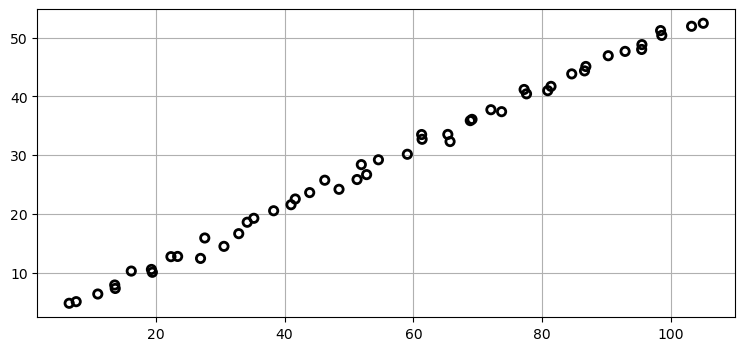

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from kf_book.book_plots import plot_measurements

pos, vel = (4, 3), (2, 1)
sensor = PosSensor(pos, vel, noise_std=1)
ps = np.array([sensor.read() for _ in range(50)])
plot_measurements(ps[:, 0], ps[:, 1]);

That looks correct. The slope is 1/2, as we would expect with a velocity of (2, 1), and the data seems to start at near (6, 4). It doesn't look realistic. This is still a 'textbook' representation. As we continue we will add complications that adds real world behavior.

这看起来是正确的。斜率为 1/2，正如我们预期的速度为 (2, 1)，数据似乎从 (6, 4) 附近开始。看起来不太现实。这仍然是一个“教科书”表示。随着我们的继续，我们将添加增加现实世界行为的复杂性。


### Choose the State Variables
### 选取状态变量
As always, the first step is to choose our state variables. We are tracking in two dimensions and have a sensor that gives us a reading in each of those two dimensions, so we  know that we have the two *observed variables* $x$ and $y$. If we created our Kalman filter using only those two variables the performance would not be very good because we would be ignoring the information velocity can provide to us. We will want to incorporate velocity into our equations as well. I will represent this as

与往常一样，第一步是选择我们的状态变量。我们在二维中进行跟踪，并且有一个传感器可以为我们提供这两个维度中的每一个的读数，因此我们知道我们有两个*观察到的变量*$x$ 和 $y$。如果我们只使用这两个变量创建我们的卡尔曼滤波器，性能将不会很好，因为我们会忽略速度可以提供给我们的信息。我们也希望将速度纳入我们的方程。我将把它表示为
$$\mathbf x = 
\begin{bmatrix}x & \dot x & y & \dot y\end{bmatrix}^\mathsf T$$
There is nothing special about this organization. I could have used $\begin{bmatrix}x & y & \dot x &  \dot y\end{bmatrix}^\mathsf T$ or something less logical. I just need to be consistent in the rest of the matrices. I like keeping positions and velocities next to each other because it keeps the covariances between positions and velocities in the same sub block of the covariance matrix. In my formulation `P[1,0]` contains the covariance of $x$ and $\dot x$. In the alternative formulation that covariance is at `P[2, 0]`. This gets worse as the number of dimension increases.

这个组织没有什么特别之处。我本可以使用 $\begin{bmatrix}x & y & \dot x & \dot y\end{bmatrix}^\mathsf T$ 或不合逻辑的东西。我只需要在其余矩阵中保持一致。我喜欢保持位置和速度彼此相邻，因为它将位置和速度之间的协方差保持在协方差矩阵的同一子块中。在我的公式中，`P[1,0]` 包含 $x$ 和 $\dot x$ 的协方差。在替代公式中，协方差位于“P[2, 0]”。随着维度数量的增加，这种情况会变得更糟。
Let's pause and address how you identify the hidden variables. This example is somewhat obvious because we've already worked through the 1D case, but other problems won't be obvious There is no easy answer to this question. The first thing to ask yourself is what is the interpretation of the first and second derivatives of the data from the sensors. We do that because obtaining the first and second derivatives is mathematically trivial if you are reading from the sensors using a fixed time step. The first derivative is just the difference between two successive readings. In our tracking case the first derivative has an obvious physical interpretation: the difference between two successive positions is velocity. 

让我们暂停一下并讨论如何识别隐藏变量。这个例子有点明显，因为我们已经处理过 1D 案例，但其他问题并不明显。这个问题没有简单的答案。首先要问自己的是传感器数据的一阶和二阶导数的解释是什么。我们这样做是因为如果你使用固定时间步长从传感器读取数据，那么获得一阶和二阶导数在数学上是微不足道的。一阶导数只是两个连续读数之间的差。在我们的跟踪案例中，一阶导数有一个明显的物理解释：两个连续位置之间的差异是速度。
Beyond this you can start looking at how you might combine the data from two or more different sensors to produce more information. This opens up the field of *sensor fusion*, and we will be covering examples of this in later sections. For now, recognize that choosing the appropriate state variables is paramount to getting the best possible performance from your filter. Once you have chosen hidden variables, you must run many tests to ensure that you are generating real results for them. The Kalman filter runs whatever model you give it; if your model cannot generate good information for the hidden variables the Kalman filter output will be nonsensical.

除此之外，你还可以开始研究如何组合来自两个或更多不同传感器的数据以产生更多信息。这开辟了*传感器融合*领域，我们将在后面的部分中介绍这方面的示例。现在，要认识到选择适当的状态变量对于从滤波器中获得最佳性能至关重要。选择隐藏变量后，你必须运行许多测试以确保为它们生成真实结果。卡尔曼滤波器运行你给它的任何模型；如果你的模型无法为隐藏变量生成好的信息，则卡尔曼滤波器输出将是无意义的。


### Design State Transition Function
### 设计状态转移函数
Our next step is to design the state transition function. Recall that the state transition function is implemented as a matrix $\mathbf F$ that we multiply with the previous state of our system to get the next state, like so. 

我们的下一步是设计状态转换函数。回想一下，状态转换函数是作为矩阵 $\mathbf F$ 实现的，我们将它与系统的前一个状态相乘以获得下一个状态，就像这样。
$$\mathbf{\bar x} = \mathbf{Fx}$$
I will not belabor this as it is very similar to the 1-D case we did in the previous chapter. The state transition equations are

我不会对此进行详细说明，因为它与我们在前一章中所做的一维案例非常相似。状态转移方程是
$$
\begin{aligned}
x &= 1x + \Delta t \dot x + 0y + 0 \dot y \\
v_x &= 0x + 1\dot x + 0y + 0 \dot y \\
y &= 0x + 0\dot x + 1y + \Delta t \dot y \\
v_y &= 0x + 0\dot x + 0y + 1 \dot y
\end{aligned}
$$
Laying it out that way shows us both the values and row-column organization required for $\small\mathbf F$. We convert this to matrix-vector form:

以这种方式布局向我们展示了 $\small\mathbf F$ 所需的值和行列组织。我们将其转换为矩阵向量形式：
$$
\begin{bmatrix}x \\ \dot x \\ y \\ \dot y\end{bmatrix} = \begin{bmatrix}1& \Delta t& 0& 0\\0& 1& 0& 0\\0& 0& 1& \Delta t\\ 0& 0& 0& 1\end{bmatrix}\begin{bmatrix}x \\ \dot x \\ y \\ \dot y\end{bmatrix}$$
So, let's do this in Python. It is very simple; the only thing new here is setting `dim_z` to 2. We will see why it is set to 2 in step 4.

所以，让我们用 Python 来做这件事。这很简单；这里唯一的新功能是将 `dim_z` 设置为 2。我们将在第 4 步中了解为什么将其设置为 2。


In [5]:
from filterpy.kalman import KalmanFilter

tracker = KalmanFilter(dim_x=4, dim_z=2)
dt = 1.   # time step 1 second

tracker.F = np.array([[1, dt, 0,  0],
                      [0,  1, 0,  0],
                      [0,  0, 1, dt],
                      [0,  0, 0,  1]])

### Design the Process Noise Matrix
### 设计过程噪声矩阵
FilterPy can compute the $\mathbf Q$ matrix for us. For simplicity I will assume the noise is a discrete time Wiener process - that it is constant for each time period. This assumption allows me to use a variance to specify how much I think the model changes between steps. Revisit the Kalman Filter Math chapter if this is not clear.

FilterPy 可以为我们计算 $\mathbf Q$ 矩阵。为简单起见，我将假设噪声是离散时间维纳过程 - 每个时间段都是恒定的。这个假设允许我使用方差来指定我认为模型在步骤之间的变化程度。如果不清楚，请重新访问卡尔曼滤波器数学章节。


In [6]:
from scipy.linalg import block_diag
from filterpy.common import Q_discrete_white_noise

q = Q_discrete_white_noise(dim=2, dt=dt, var=0.001)
tracker.Q = block_diag(q, q)
print(tracker.Q)

[[0.    0.001 0.    0.   ]
 [0.001 0.001 0.    0.   ]
 [0.    0.    0.    0.001]
 [0.    0.    0.001 0.001]]


Here I assume the noise in x and y are independent, so the covariances between any x and y variable should be zero. This allows me to compute $\mathbf Q$ for one dimension, and then use `block_diag` to copy it for the x and y axis.

这里我假设 x 和 y 中的噪声是独立的，因此任何 x 和 y 变量之间的协方差应该为零。这允许我计算一维的 $\mathbf Q$，然后使用 `block_diag` 将其复制到 x 和 y 轴。


### Design the Control Function
### 设计控制函数
We haven't yet added controls to our robot, so there is nothing to be done for this step. The `KalmanFilter` class initializes `B` to zero under the assumption that there is no control input,
so there is no code to write. If you like, you can be explicit and set `tracker.B` to 0, but as you can see it already has that value.

我们还没有为我们的机器人添加控件，所以这一步不需要做任何事情。`KalmanFilter` 类在没有控制输入的假设下将`B` 初始化为零，
所以没有代码可写。如果你愿意，你可以显式地将 `tracker.B` 设置为 0，但正如你所见，它已经具有该值。


In [7]:
tracker.B

### Design the Measurement Function
### 设计测量函数
The measurement function $\mathbf H$ defines how we go from the state variables to the measurements using the equation $\mathbf z = \mathbf{Hx}$. In this case we have measurements for (x,y), so we will design $\mathbf z$ as $\begin{bmatrix}x & y\end{bmatrix}^\mathsf T$ which is dimension 2x1. Our state variable is size 4x1. We can deduce the required size for $\textbf{H}$ by recalling that multiplying a matrix of size MxN by NxP yields a matrix of size MxP. Thus,

测量函数 $\mathbf H$ 使用方程 $\mathbf z = \mathbf{Hx}$ 定义了我们如何从状态变量到测量值。在这种情况下，我们有 (x,y) 的测量值，因此我们将 $\mathbf z$ 设计为 $\begin{bmatrix}x & y\end{bmatrix}^\mathsf T$，其维度为 2x1。我们的状态变量大小为 4x1。我们可以通过回忆将大小为 MxN 的矩阵乘以 NxP 得到大小为 MxP 的矩阵来推断 $\textbf{H}$ 所需的大小。因此，
$$(2\times 1) = (a\times b)(4 \times 1) = (2\times 4)(4\times 1)$$
So, $\textbf{H}$ is 2x4.

So, $\textbf{H}$ is 2x4.
Filling in the values for $\textbf{H}$ is easy because the measurement is the position of the robot, which is the $x$ and $y$ variables of the state $\textbf{x}$. Let's make this slightly more interesting by deciding we want to change units. The measurements are returned in feet, and that we desire to work in meters. $\textbf{H}$ changes from state to measurement, so the conversion is $\mathsf{feet} = \mathsf{meters} / 0.3048$. This yields

填写 $\textbf{H}$ 的值很容易，因为测量的是机器人的位置，即状态 $\textbf{x}$ 的 $x$ 和 $y$ 变量。让我们通过决定我们要更改单位来使这变得更有趣。测量结果以英尺为单位，我们希望以米为单位。$\textbf{H}$ 从状态变为测量值，因此转换为 $\mathsf{feet} = \mathsf{meters} / 0.3048$。这产生
$$\mathbf H =
\begin{bmatrix} 
\frac{1}{0.3048} & 0 & 0 & 0 \\
0 & 0 & \frac{1}{0.3048} & 0
\end{bmatrix}
$$
which corresponds to these linear equations

对应于这些线性方程
$$
\begin{aligned}
z_x &= (\frac{x}{0.3048}) + (0* v_x) + (0*y) + (0 * v_y) = \frac{x}{0.3048}\\
z_y &= (0*x) + (0* v_x) + (\frac{y}{0.3048}) + (0 * v_y) = \frac{y}{0.3048}
\end{aligned}
$$
This is a simple problem, and we could have found the equations directly without going through the dimensional analysis that I did above. But it is useful to remember that the equations of the Kalman filter imply a specific dimensionality for all of the matrices, and when I start to get lost as to how to design something it is useful to look at the matrix dimensions.

这是一个简单的问题，我们可以直接找到方程式，而无需经过我上面所做的维度分析。但是记住卡尔曼滤波器的方程对所有矩阵都意味着一个特定的维度是很有用的，当我开始迷失如何设计一些东西时，查看矩阵维度是很有用的。
Here is my implementation:

这是我的实现：


In [8]:
tracker.H = np.array([[1/0.3048, 0, 0,        0],
                      [0,        0, 1/0.3048, 0]])

### Design the Measurement Noise Matrix
### 设计测量噪声矩阵
We assume that the $x$ and $y$ variables are independent white Gaussian processes. That is, the noise in x is not in any way dependent on the noise in y, and the noise is normally distributed about the mean 0. For now let's set the variance for $x$ and $y$ to be 5 meters$^2$. They are independent, so there is no covariance, and our off diagonals will be 0. This gives us:

我们假设 $x$ 和 $y$ 变量是独立的白高斯过程。也就是说，x 中的噪声与 y 中的噪声没有任何关系，并且噪声正态分布在均值 0 附近。现在让我们将 $x$ 和 $y$ 的方差设置为 5 米$^ 2 美元。它们是独立的，因此没有协方差，并且我们的非对角线将为 0。这给了我们：
$$\mathbf R = \begin{bmatrix}\sigma_x^2 & \sigma_y\sigma_x \\ \sigma_x\sigma_y & \sigma_{y}^2\end{bmatrix} 
= \begin{bmatrix}5&0\\0&5\end{bmatrix}$$
It is a $2{\times}2$ matrix because we have 2 sensor inputs, and covariance matrices are always of size $n{\times}n$ for $n$ variables. In Python we write:

这是一个 $2{\times}2$ 矩阵，因为我们有 2 个传感器输入，对于 $n$ 个变量，协方差矩阵的大小总是 $n{\times}n$。在 Python 中，我们编写：


In [9]:
tracker.R = np.array([[5., 0],
                      [0, 5]])
tracker.R

array([[5., 0.],
       [0., 5.]])

### Initial Conditions
### 初始条件
For our simple problem we will set the initial position at (0,0) with a velocity of (0,0). Since that is a pure guess, we will set the covariance matrix $\small\mathbf P$ to a large value.

对于我们的简单问题，我们将初始位置设置为 (0,0)，速度为 (0,0)。由于这是一个纯粹的猜测，我们将协方差矩阵 $\small\mathbf P$ 设置为一个较大的值。
$$ \mathbf x = \begin{bmatrix}0\\0\\0\\0\end{bmatrix}, \,
\mathbf P = \begin{bmatrix}500&0&0&0\\0&500&0&0\\0&0&500&0\\0&0&0&500\end{bmatrix}$$
The Python implementation is

Python实现是


In [10]:
tracker.x = np.array([[0, 0, 0, 0]]).T
tracker.P = np.eye(4) * 500.

### Implement the Filter
### 实现滤波器
Design is complete, now we just have to write the code to run the filter and output the data in the format of our choice. We will run the code for 30 iterations.

设计完成，现在我们只需要编写代码来运行滤波器并以我们选择的格式输出数据。我们将运行代码 30 次迭代。


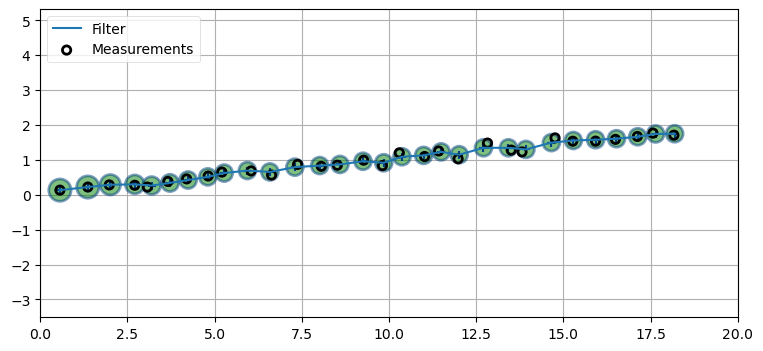

In [11]:
from filterpy.stats import plot_covariance_ellipse
from kf_book.book_plots import plot_filter

R_std = 0.35
Q_std = 0.04

def tracker1():
    tracker = KalmanFilter(dim_x=4, dim_z=2)
    dt = 1.0   # time step

    tracker.F = np.array([[1, dt, 0,  0],
                          [0,  1, 0,  0],
                          [0,  0, 1, dt],
                          [0,  0, 0,  1]])
    tracker.u = 0.
    tracker.H = np.array([[1/0.3048, 0, 0, 0],
                          [0, 0, 1/0.3048, 0]])

    tracker.R = np.eye(2) * R_std**2
    q = Q_discrete_white_noise(dim=2, dt=dt, var=Q_std**2)
    tracker.Q = block_diag(q, q)
    tracker.x = np.array([[0, 0, 0, 0]]).T
    tracker.P = np.eye(4) * 500.
    return tracker

# simulate robot movement
N = 30
sensor = PosSensor((0, 0), (2, .2), noise_std=R_std)

zs = np.array([sensor.read() for _ in range(N)])

# run filter
robot_tracker = tracker1()
mu, cov, _, _ = robot_tracker.batch_filter(zs)

for x, P in zip(mu, cov):
    # covariance of x and y
    cov = np.array([[P[0, 0], P[2, 0]], 
                    [P[0, 2], P[2, 2]]])
    mean = (x[0, 0], x[2, 0])
    plot_covariance_ellipse(mean, cov=cov, fc='g', std=3, alpha=0.5)
    
#plot results
zs *= .3048 # convert to meters
plot_filter(mu[:, 0], mu[:, 2])
plot_measurements(zs[:, 0], zs[:, 1])
plt.legend(loc=2)
plt.xlim(0, 20);

I encourage you to play with this, setting $\mathbf Q$ and $\mathbf R$ to various values.  However, we did a fair amount of that sort of thing in the last chapters, and we have a lot of material to cover, so I will move on to more complicated cases where we will also have a chance to experience changing these values.

我鼓励你玩这个，将 $\mathbf Q$ 和 $\mathbf R$ 设置为不同的值。但是，我们在最后几章中做了很多类似的事情，而且我们有很多材料要涵盖，所以我将继续讨论更复杂的案例，我们也将有机会体验更改这些值。
I plotted the $3\sigma$ the covariance ellipse for $x$ and $y$ in green. Can you explain their shape? Perhaps you were expecting a tilted ellipse, as in the last chapters. If so, recall that in those chapters we were not plotting $x$ against $y$, but $x$ against $\dot x$. $x$ is correlated to $\dot x$, but $x$ is not correlated or dependent on $y$. Therefore our ellipses are not tilted. Furthermore, the noise for both $x$ and $y$ are modeled to have the same noise standard deviation. If we were to set R to, for example,

我为 $x$ 和 $y$ 绘制了绿色的 $3\sigma$ 协方差椭圆。你能解释一下它们的形状吗？也许你期待的是一个倾斜的椭圆，就像在最后几章中一样。如果是这样，请回想一下，在那些章节中，我们不是绘制 $x$ 与 $y$，而是绘制 $x$ 与 $\dot x$。$x$ 与 $\dot x$ 相关，但 $x$ 不相关或不依赖于 $y$。因此我们的椭圆没有倾斜。此外，$x$ 和 $y$ 的噪声被建模为具有相同的噪声标准偏差。例如，如果我们将 R 设置为
$$\mathbf R = \begin{bmatrix}1&0\\0&.5\end{bmatrix}$$
we would be telling the Kalman filter that there is more noise in $x$ than $y$, and our ellipses would be longer than they are tall.

我们会告诉卡尔曼滤波器，$x$ 中的噪声比 $y$ 多，我们的椭圆会比它们的高更长。
The final value for $\mathbf P$ tells us everything we need to know about the correlation between the state variables. If we look at the diagonal alone we see the variance for each variable. In other words $\mathbf P_{0,0}$ is the variance for x, $\mathbf P_{1,1}$ is the variance for $\dot x$, $\mathbf P_{2,2}$ is the variance for y, and $\mathbf P_{3,3}$ is the variance for $\dot y$. We can extract the diagonal of a matrix using `numpy.diag()`.

$\mathbf P$ 的最终值告诉我们关于状态变量之间相关性的所有信息。如果我们只看对角线，我们会看到每个变量的方差。换句话说，$\mathbf P_{0,0}$ 是 x 的方差，$\mathbf P_{1,1}$ 是 $\dot x$ 的方差，$\mathbf P_{2,2}$ 是 y 的方差，$\mathbf P_{3,3}$ 是 $\dot y$ 的方差。我们可以使用 numpy.diag() 提取矩阵的对角线。


In [12]:
print(np.diag(robot_tracker.P))

[0.007 0.003 0.007 0.003]


The covariance matrix contains four $2{\times}2$ matrices that you should be able to easily pick out. This is due to the correlation of $x$ to $\dot x$, and of $y$ to $\dot y$. The upper left hand side shows the covariance of $x$ to $\dot x$.

协方差矩阵包含四个 $2{\times}2$ 矩阵，你应该能够轻松挑选出它们。这是由于 $x$ 与 $\dot x$ 以及 $y$ 与 $\dot y$ 的相关性。左上角显示了 $x$ 到 $\dot x$ 的协方差。


[[0.007 0.003]
 [0.003 0.003]]


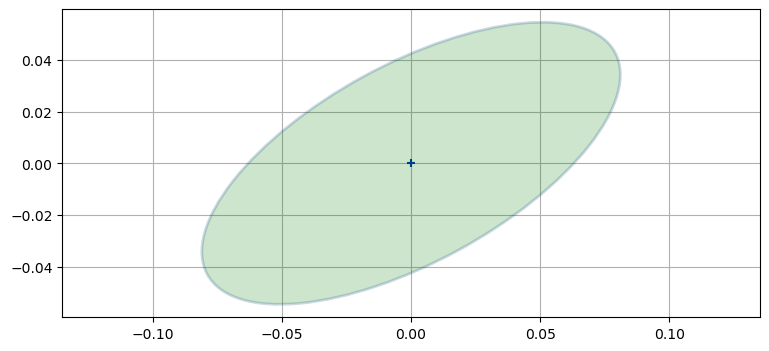

In [13]:
c = robot_tracker.P[0:2, 0:2]
print(c)
plot_covariance_ellipse((0, 0), cov=c, fc='g', alpha=0.2)

The covariance contains the data for $x$ and $\dot x$ in the upper left because of how it is organized. Recall that entries $\mathbf P_{i,j}$ and $\mathbf P_{j,i}$ contain $\sigma_i\sigma_j$.

协方差包含左上角 $x$ 和 $\dot x$ 的数据，因为它是如何组织的。回想一下条目 $\mathbf P_{i,j}$ 和 $\mathbf P_{j,i}$ 包含 $\sigma_i\sigma_j$。
Finally, let's look at the lower left side of $\mathbf P$, which is all 0s. Why 0s? Consider $\mathbf P_{3,0}$. That stores the term $\sigma_3\sigma_0$, which is the covariance between $\dot y$ and $x$. These are independent, so the term will be 0. The rest of the terms are for similarly independent variables.

最后我们看一下$\mathbf P$的左下角，全是0。为什么是 0？考虑 $\mathbf P_{3,0}$。它存储了 $\sigma_3\sigma_0$ 项，它是 $\dot y$ 和 $x$ 之间的协方差。这些是独立的，因此项将为 0。其余项用于类似的自变量。


In [14]:
robot_tracker.P[2:4, 0:2]

array([[0., 0.],
       [0., 0.]])

## Filter Order
## 滤波器阶数
We have only studied tracking position and velocity. It has worked well, but only because I have been selecting problems for which this is an appropriate choice. You now have enough experience with the Kalman filter to consider this in more general terms.

我们只研究了跟踪位置和速度。它运作良好，但这只是因为我一直在选择适合选择的问题。你现在有足够的卡尔曼滤波器经验，可以更一般地考虑这一点。
What do I mean by order? In the context of these system models it is the number of derivatives required to accurately model a system. Consider a system that does not change, such as the height of a building. There is no change, so there is no need for a derivative, and the order of the system is zero. We could express this in an equation as $x = 312.5$.

我说的顺序是什么意思？在这些系统模型的上下文中，它是准确建模系统所需的导数。考虑一个不变的系统，例如建筑物的高度。没有变化，所以不需要导数，系统的阶为零。我们可以将其表示为 $x = 312.5$。
A first order system has a first derivative. For example, change of position is velocity, and we can write this as

一阶系统具有一阶导数。例如，位置的变化就是速度，我们可以写成
$$ v = \frac{dx}{dt}$$
which we integrate into the Newtonian equation

我们将其整合到牛顿方程中
$$ x = vt + x_0.$$
This is also called a *constant velocity* model, because of the assumption of a constant velocity.

由于假设速度恒定，这也称为*恒定速度*模型。
A second order system has a second derivative. The second derivative of position is acceleration, with the equation

二阶系统具有二阶导数。位置的二阶导数是加速度，方程为
$$a = \frac{d^2x}{dt^2}$$
which we integrate into 

我们融入其中
$$ x = \frac{1}{2}at^2 +v_0t + x_0.$$
This is also known as a *constant acceleration* model.

这也称为*恒定加速度*模型。


Another, equivalent way of looking at this is to consider the order of the polynomial. The constant acceleration model has a second derivative, so it is second order. Likewise, the polynomial $x = \frac{1}{2}at^2 +v_0t + x_0$ is second order.

另一种等效的方法是考虑多项式的阶数。恒加速度模型具有二阶导数，因此是二阶的。同样，多项式 $x = \frac{1}{2}at^2 +v_0t + x_0$ 是二阶的。
When we design the state variables and process model we must choose the order of the system we want to model. Let's say we are tracking something with a constant velocity. No real world process is perfect, and so there will be slight variations in the velocity over short time period. You might reason that the best approach is to use a second order filter, allowing the acceleration term to deal with the slight variations in velocity. 

当我们设计状态变量和过程模型时，我们必须选择我们想要建模的系统的顺序。假设我们正在以恒定的速度跟踪某物。现实世界中没有一个过程是完美的，因此在短时间内速度会有轻微的变化。你可能会认为最好的方法是使用二阶滤波器，允许加速度项处理速度的微小变化。
In practice that doesn't work well. To thoroughly understand this issue let's see the effects of using a  process model that does not match the order of the system being filtered.

在实践中效果并不好。为了彻底理解这个问题，让我们看看使用与被滤波系统的顺序不匹配的流程模型的效果。
First we need a system to filter. I'll write a class to simulate an object with constant velocity. Essentially no physical system has a truly constant velocity, so on each update we alter the velocity by a small amount. I also write a sensor to simulate Gaussian noise in a sensor. The code is below, and I plot an example run to verify that it is working correctly.

首先，我们需要一个滤波系统。我将编写一个类来模拟具有恒定速度的对象。基本上没有物理系统具有真正恒定的速度，因此在每次更新时，我们都会稍微改变速度。我还编写了一个传感器来模拟传感器中的高斯噪声。代码如下，我绘制了一个示例运行以验证它是否正常工作。


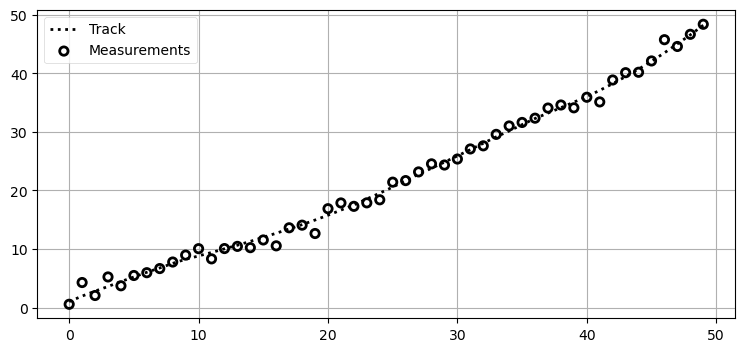

In [15]:
from kf_book.book_plots import plot_track

class ConstantVelocityObject(object):
    def __init__(self, x0=0, vel=1., noise_scale=0.06):
        self.x = x0
        self.vel = vel
        self.noise_scale = noise_scale

    def update(self):
        self.vel += randn() * self.noise_scale
        self.x += self.vel
        return (self.x, self.vel)

def sense(x, noise_scale=1.):
    return x[0] + randn()*noise_scale

np.random.seed(124)
obj = ConstantVelocityObject()

xs, zs = [], []
for i in range(50):
    x = obj.update()
    z = sense(x)
    xs.append(x)
    zs.append(z)

xs = np.asarray(xs)

plot_track(xs[:, 0])
plot_measurements(range(len(zs)), zs)
plt.legend(loc='best');

I am satisfied with this plot. The track is not perfectly straight due to the noise that we added to the system - this could be the track of a person walking down the street, or perhaps of an aircraft being buffeted by variable winds. There is no intentional acceleration here, so we call it a constant velocity system. Again, you may be asking yourself that since there is in fact a tiny bit of acceleration going on why would we not use a second order Kalman filter to account for those changes? Let's find out.

我对这张图很满意。由于我们给系统加入了噪声，轨迹并不完全笔直——这可能是有人在街上行走的轨迹，也可能是一架飞机受多变的风吹动。这里没有有意的加速度，所以我们称之为恒速系统。再一次，你可能会问自己，既然实际上有一点点加速，为什么我们不使用二阶卡尔曼滤波器来解释这些变化？让我们来了解一下。
How does one design a zero order, first order, or second order Kalman filter? We have been doing it all along, but just not using those terms. It might be slightly tedious, but I will elaborate fully on each - if the concept is clear to you feel free to skim a bit.

如何设计零阶、一阶或二阶卡尔曼滤波器？我们一直在这样做，但只是不使用这些术语。这可能有点乏味，但我会详细说明每一个 - 如果你清楚这个概念，请随意略读。


### Zero Order Kalman Filter
### 零阶卡尔曼滤波器
A zero order Kalman filter is just a filter that tracks with no derivatives. We are tracking position, so that means we only have a state variable for position (no velocity or acceleration), and the state transition function also only accounts for position. Using the matrix formulation we would say that the state variable is

零阶卡尔曼滤波器只是一个没有导数的跟踪滤波器。我们正在跟踪位置，这意味着我们只有一个位置状态变量（没有速度或加速度），并且状态转换函数也只考虑位置。使用矩阵公式，我们可以说状态变量是
$$\mathbf x = \begin{bmatrix}x\end{bmatrix}$$
The state transition function is very simple. There is no change in position, so we need to model $x=x$; in other words, *x* at time t+1 is the same as it was at time t. In matrix form, our state transition function is

状态转换函数非常简单。位置没有变化，所以我们需要建模$x=x$; 换句话说，时间 t+1 的 *x* 与时间 t 相同。在矩阵形式中，我们的状态转移函数是
$$\mathbf F = \begin{bmatrix}1\end{bmatrix}$$
The measurement function is very easy. Recall that we need to define how to convert the state variable $\mathbf x$ into a measurement. We will assume that our measurements are positions. The state variable only contains a position, so we get

测量功能非常简单。回想一下，我们需要定义如何将状态变量 $\mathbf x$ 转换为测量值。我们将假设我们的测量是位置。状态变量只包含一个位置，所以我们得到
$$\mathbf H = \begin{bmatrix}1\end{bmatrix}$$
Let's write a function that constructs and returns a zero order Kalman filter.

让我们编写一个构造并返回零阶卡尔曼滤波器的函数。


In [16]:
def ZeroOrderKF(R, Q, P=20):
    """ Create zero order Kalman filter.
    Specify R and Q as floats."""
    
    kf = KalmanFilter(dim_x=1, dim_z=1)
    kf.x = np.array([0.])
    kf.R *= R
    kf.Q *= Q
    kf.P *= P
    kf.F = np.eye(1)
    kf.H = np.eye(1)
    return kf

### First Order Kalman Filter
### 一阶卡尔曼滤波器
A first order Kalman filter tracks a first order system, such as position and velocity. We already did this for the dog tracking problem above, so this should be very clear. But let's do it again.

一阶卡尔曼滤波器跟踪一阶系统，例如位置和速度。我们已经为上面的狗跟踪问题做了这个，所以这应该很清楚。但让我们再做一次。
A first order system has position and velocity, so the state variable needs both of these. The matrix formulation could be

一阶系统具有位置和速度，因此状态变量需要这两者。矩阵公式可以是
$$ \mathbf x = \begin{bmatrix}x\\\dot x\end{bmatrix}$$
So now we have to design our state transition. The Newtonian equations for a time step are:

所以现在我们必须设计我们的状态转换。时间步长的牛顿方程为：
$$\begin{aligned} x_t &= x_{t-1} + v\Delta t \\
 v_t &= v_{t-1}\end{aligned}$$
Recall that we need to convert this into the linear equation

回想一下，我们需要将其转换为线性方程
$$\begin{bmatrix}x\\\dot x\end{bmatrix} = \mathbf F\begin{bmatrix}x\\\dot x\end{bmatrix}$$
Setting

Setting
$$\mathbf F = \begin{bmatrix}1 &\Delta t\\ 0 & 1\end{bmatrix}$$
gives us the equations above.

给我们上面的方程。
Finally, we design the measurement function. The measurement function needs to implement

最后，我们设计了测量函数。测量功能需要实现
$$\mathbf z = \mathbf{Hx}$$
Our sensor still only reads position, so it should take the position from the state, and 0 out the velocity and acceleration, like so:

我们的传感器仍然只读取位置，因此它应该从状态中获取位置，并将速度和加速度设为 0，如下所示：
$$\mathbf H = \begin{bmatrix}1 & 0 \end{bmatrix}$$
This function constructs and returns a first order Kalman filter.

该函数构造并返回一阶卡尔曼滤波器。


In [17]:
def FirstOrderKF(R, Q, dt):
    """ Create first order Kalman filter. 
    Specify R and Q as floats."""
    
    kf = KalmanFilter(dim_x=2, dim_z=1)
    kf.x = np.zeros(2)
    kf.P *= np.array([[100, 0], [0, 1]])
    kf.R *= R
    kf.Q = Q_discrete_white_noise(2, dt, Q)
    kf.F = np.array([[1., dt],
                     [0., 1]])
    kf.H = np.array([[1., 0]])
    return kf

### Second Order Kalman Filter
### 二阶卡尔曼滤波器
A second order Kalman filter tracks a second order system, such as position, velocity and acceleration. The state variable will be

二阶卡尔曼滤波器跟踪二阶系统，例如位置、速度和加速度。状态变量将是
$$ \mathbf x = \begin{bmatrix}x\\\dot x\\\ddot{x}\end{bmatrix}$$
So now we have to design our state transition. The Newtonian equations for a time step are:

所以现在我们必须设计我们的状态转换。时间步长的牛顿方程为：
$$\begin{aligned} x_t &= x_{t-1} + v_{t-1}\Delta t + 0.5a_{t-1} \Delta t^2 \\
 v_t &= v_{t-1} + a_{t-1}\Delta t \\
 a_t &= a_{t-1}\end{aligned}$$
Recall that we need to convert this into the linear equation

回想一下，我们需要将其转换为线性方程
$$\begin{bmatrix}x\\\dot x\\\ddot{x}\end{bmatrix} = \mathbf F\begin{bmatrix}x\\\dot x\\\ddot{x}\end{bmatrix}$$
Setting

Setting
$$\mathbf F = \begin{bmatrix}1 & \Delta t &.5\Delta t^2\\ 
0 & 1 & \Delta t \\
0 & 0 & 1\end{bmatrix}$$
gives us the equations above. 

给我们上面的方程。
Finally, we design the measurement function. The measurement function needs to implement

最后，我们设计了测量函数。测量功能需要实现
$$z = \mathbf{Hx}$$
Our sensor still only reads position, so it should take the position from the state, and 0 out the velocity, like so:

我们的传感器仍然只读取位置，因此它应该从状态中获取位置，并将速度设为 0，如下所示：
$$\mathbf H = \begin{bmatrix}1 & 0 & 0\end{bmatrix}$$
This function constructs and returns a second order Kalman filter.

该函数构造并返回二阶卡尔曼滤波器。


In [18]:
def SecondOrderKF(R_std, Q, dt, P=100):
    """ Create second order Kalman filter. 
    Specify R and Q as floats."""
    
    kf = KalmanFilter(dim_x=3, dim_z=1)
    kf.x = np.zeros(3)
    kf.P[0, 0] = P
    kf.P[1, 1] = 1
    kf.P[2, 2] = 1
    kf.R *= R_std**2
    kf.Q = Q_discrete_white_noise(3, dt, Q)
    kf.F = np.array([[1., dt, .5*dt*dt],
                     [0., 1.,       dt],
                     [0., 0.,       1.]])
    kf.H = np.array([[1., 0., 0.]])
    return kf

## Evaluating Filter Order
## 评估滤波器阶数
Now we can run each Kalman filter against the simulation and evaluate the results. 

现在我们可以针对模拟运行每个卡尔曼滤波器并评估结果。
How do we evaluate the results? We can do this qualitatively by plotting the track and the Kalman filter output and eyeballing the results. However, a rigorous approach uses mathematics. Recall that the system covariance matrix $\mathbf P$ contains the computed variance and covariances for each of the state variables. The diagonal contains the variance. Remember that roughly 99% of all measurements fall within $3\sigma$ if the noise is Gaussian. If this is not clear please review the Gaussian chapter before continuing, as this is an important point. 

我们如何评估结果？我们可以通过绘制轨迹和卡尔曼滤波器输出并观察结果来定性地做到这一点。但是，严格的方法使用数学。回想一下，系统协方差矩阵 $\mathbf P$ 包含每个状态变量的计算方差和协方差。对角线包含方差。请记住，如果噪声是高斯噪声，大约 99% 的测量值落在 $3\sigma$ 以内。如果不清楚，请在继续之前查看高斯章节，因为这是重要的一点。
So we can evaluate the filter by looking at the residuals between the estimated state and actual state and comparing them to the standard deviations which we derive from $\mathbf P$. If the filter is performing correctly 99% of the residuals will fall within $3\sigma$. This is true for all the state variables, not just for the position. 

因此，我们可以通过查看估计状态和实际状态之间的残差并将它们与我们从 $\mathbf P$ 得出的标准差进行比较来评估滤波器。如果滤波器正确执行，99% 的残差将落在 $3\sigma$ 内。这适用于所有状态变量，而不仅仅是位置。
I must mention that this is only true for simulated systems. Real sensors are not perfectly Gaussian, and you may need to expand your criteria to, say, $5\sigma$ with real sensor data.

我必须提到，这仅适用于模拟系统。真实传感器不是完全高斯的，你可能需要将你的标准扩展为，例如，使用真实传感器数据的 $5\sigma$。
So let's run the first order Kalman filter against our first order system and access its performance. You can probably guess that it will do well, but let's look at it using the standard deviations.

因此，让我们针对我们的一阶系统运行一阶卡尔曼滤波器并访问其性能。你可能会猜到它会做得很好，但让我们使用标准偏差来看看它。
First, let's write a routine to generate the noisy measurements for us.

首先，让我们编写一个例程来为我们生成噪声测量值。


In [19]:
def simulate_system(Q, count):
    obj = ConstantVelocityObject(x0=.0, vel=0.5, noise_scale=Q)
    xs, zs = [], []
    for i in range(count):
        x = obj.update()
        z = sense(x)
        xs.append(x)
        zs.append(z)
    return np.array(xs), np.array(zs)

And now a routine to perform the filtering and save the output in a `Saver` object.

现在是一个执行滤波并将输出保存在“Saver”对象中的例程。


In [20]:
from filterpy.common import Saver

def filter_data(kf, zs):
    s = Saver(kf)
    kf.batch_filter(zs, saver=s)
    s.to_array()
    return s

Now we are prepared to run the filter and look at the results.

现在我们准备运行滤波器并查看结果。


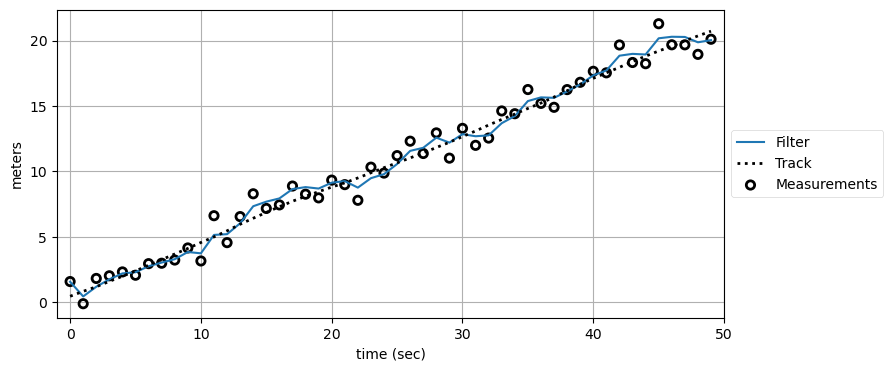

In [21]:
from kf_book.book_plots import plot_kf_output

R, Q = 1, 0.03
xs, zs = simulate_system(Q=Q, count=50)

kf = FirstOrderKF(R, Q, dt=1)
data1 = filter_data(kf, zs)

plot_kf_output(xs, data1.x, data1.z)

It looks like the filter is performing well, but it is hard to tell exactly how well. Let's look at the residuals and see if they help. We'll do this a lot, so I'll write a function to plot them.

看起来滤波器的性能很好，但很难说到底有多好。让我们看看残差，看看它们是否有帮助。我们会经常这样做，所以我将编写一个函数来绘制它们。


In [22]:
from kf_book.book_plots import plot_residual_limits, set_labels

def plot_residuals(xs, data, col, title, y_label, stds=1):
    res = xs - data.x[:, col]
    plt.plot(res)
    plot_residual_limits(data.P[:, col, col], stds)
    set_labels(title, 'time (sec)', y_label)

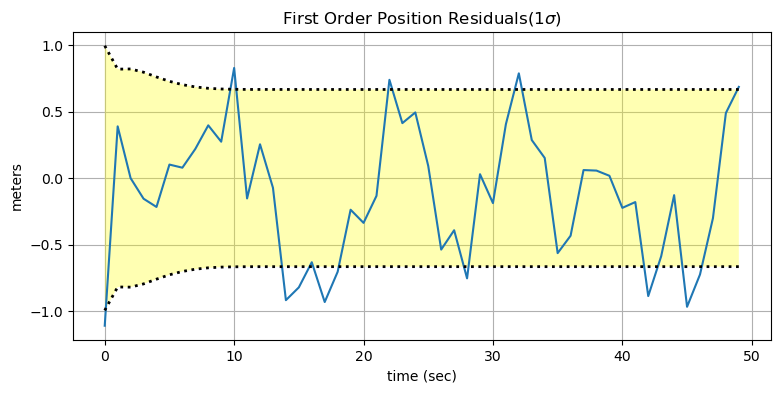

In [23]:
plot_residuals(xs[:, 0], data1, 0, 
               title='First Order Position Residuals(1$\sigma$)',
               y_label='meters')   

How do we interpret this plot? The residual is drawn as the jagged line - the difference between the measurement and the predicted position. If there was no measurement noise and the Kalman filter prediction was always perfect the residual would always be zero. So the ideal output would be a horizontal line at 0. We can see that the residual is centered around 0, so this gives us confidence that the noise is Gaussian (because the errors fall equally above and below 0). The yellow area between dotted lines show the theoretical performance of the filter for 1 standard deviations. In other words, approximately 68% of the errors should fall within the dotted lines. The residual falls within this range, so we see that the filter is performing well, and that it is not diverging.

我们如何解释这张图？残差绘制为锯齿线 - 测量值与预测位置之间的差异。如果没有测量噪声并且卡尔曼滤波器预测总是完美的，那么残差总是为零。所以理想的输出是 0 处的水平线。我们可以看到残差以 0 为中心，所以这让我们确信噪声是高斯的（因为误差在 0 上下均等）。虚线之间的黄色区域显示了滤波器在 1 个标准偏差下的理论性能。换句话说，大约 68% 的错误应该在虚线范围内。残差在这个范围内，所以我们看到滤波器表现良好，并且没有发散。
Let's look at the residuals for velocity.

让我们看看速度的残差。


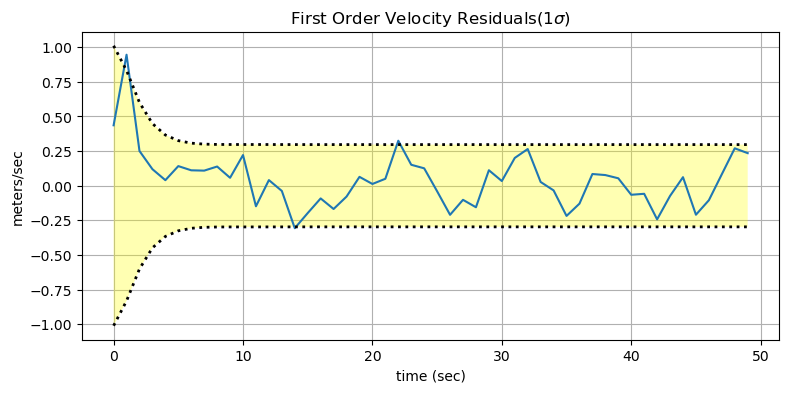

In [24]:
plot_residuals(xs[:, 1], data1, 1, 
               title='First Order Velocity Residuals(1$\sigma$)',
               y_label='meters/sec')   

Again, as expected, the residual falls within the theoretical performance of the filter, so we feel confident that the filter is well designed for this system. 

同样，正如预期的那样，残差落在滤波器的理论性能范围内，因此我们确信滤波器是为该系统精心设计的。
Now let's do the same thing using the zero order Kalman filter. All of the code and math is largely the same, so let's just look at the results without discussing the implementation much.

现在让我们使用零阶卡尔曼滤波器做同样的事情。所有的代码和数学基本相同，所以让我们只看结果而不讨论实现。


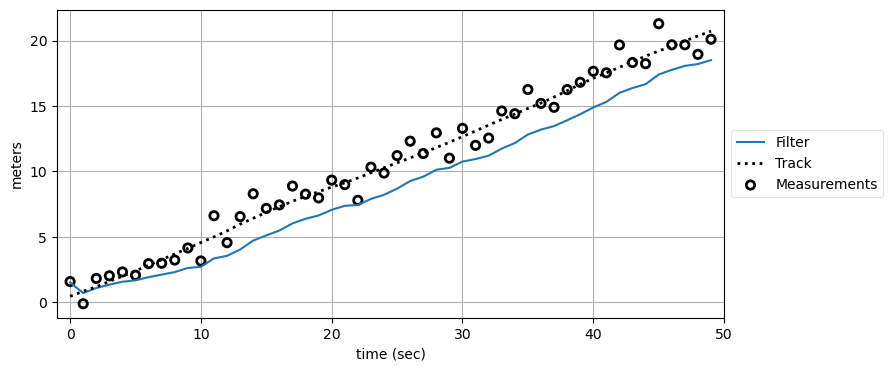

In [25]:
kf0 = ZeroOrderKF(R, Q)
data0 = filter_data(kf0, zs)
plot_kf_output(xs, data0.x, data0.z)

As we would expect, the filter has problems. Think back to the g-h filter, where we incorporated acceleration into the system. The g-h filter always lagged the input because there were not enough terms to allow the filter to adjust quickly enough to the changes in velocity. On every `predict()` step the Kalman filter assumes that there is no change in position - if the current position is 4.3 it will predict that the position at the next time period is 4.3. Of course, the actual position is closer to 5.3. The measurement, with noise, might be 5.4, so the filter chooses an estimate part way between 4.3 and 5.4, causing it to lag the actual value of 5.3 by a significant amount. This same thing happens in the next step, the next one, and so on. The filter never catches up.

正如我们所料，滤波器有问题。回想一下 g-h 滤波器，我们将加速度纳入系统。g-h 滤波器总是滞后于输入，因为没有足够的项来让滤波器足够快地适应速度的变化。在每个“predict()”步骤中，卡尔曼滤波器假设位置没有变化——如果当前位置是 4.3，它将预测下一个时间段的位置是 4.3。当然，实际位置更接近5.3。带有噪声的测量值可能是 5.4，因此滤波器选择了介于 4.3 和 5.4 之间的估计值，导致它大大滞后于 5.3 的实际值。同样的事情发生在下一步，下一个，依此类推。滤波器永远赶不上。
This raises a very important point. The assumption of 'constant' is an assumption of constant-ness between discrete samples only. The filter's output can still change over time.

这提出了一个非常重要的观点。“恒定”假设仅是离散样本之间的恒定性假设。滤波器的输出仍会随时间而变化。
Now let's look at the residuals. We are not tracking velocity, so we can only look at the residual for position.

现在让我们看看残差。我们没有跟踪速度，所以我们只能查看残差的位置。


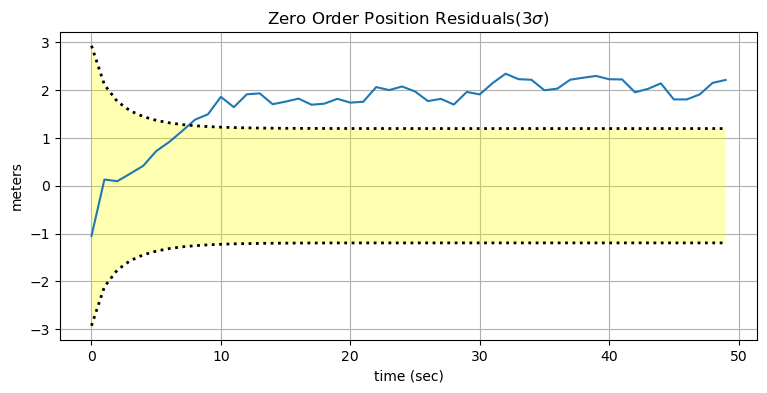

In [26]:
plot_residuals(xs[:, 0], data0, 0, 
               title='Zero Order Position Residuals(3$\sigma$)',
               y_label='meters',
               stds=3)

We can see that the filter diverges almost immediately. After a few seconds the residual exceeds the bounds of three standard deviations. It is important to understand that the covariance matrix $\mathbf P$ is only reporting the *theoretical* performance of the filter *assuming* all of the inputs are correct. In other words, this Kalman filter is diverging, but $\mathbf P$ implies that the Kalman filter's estimates are getting better and better with time because the variance is getting smaller. The filter has no way to know that you are lying to it about the system. This is sometimes referred to a *smug* filter - it is overconfident in its performance.

我们可以看到滤波器几乎立即发散。几秒钟后，残差超过了三个标准偏差的界限。重要的是要理解协方差矩阵 $\mathbf P$ 仅报告*假设*所有输入正确的滤波器的*理论*性能。换句话说，这个卡尔曼滤波器是发散的，但是 $\mathbf P$ 意味着卡尔曼滤波器的估计随着时间的推移越来越好，因为方差越来越小。滤波器无法知道你在对系统撒谎。这有时被称为 *smug* 滤波器 - 它对其性能过于自信。
In this system the divergence is immediate and striking. In many systems it will only be gradual, and/or slight. It is important to look at charts like these for your systems to ensure that the performance of the filter is within the bounds of its theoretical performance.

在这个系统中，分歧是直接而引人注目的。在许多系统中，它只会是渐进的和/或轻微的。为你的系统查看此类图表非常重要，以确保滤波器的性能在其理论性能范围内。
Now let's try a second order system. This might strike you as a good thing to do. After all, we know there is a bit of noise in the movement of the simulated object, which implies there is some acceleration. Why not model the acceleration with a second order model? If there is no acceleration, the acceleration should just be estimated to be 0, right?. But is that what happens? Think about it before going on.

现在让我们尝试一个二阶系统。这可能会让你觉得这是一件好事。毕竟，我们知道模拟物体的运动中有一点噪声，这意味着有一些加速度。为什么不用二阶模型来模拟加速度呢？如果没有加速度，加速度应该只是估计为0，对吧？但会发生这种情况吗？在继续之前考虑一下。


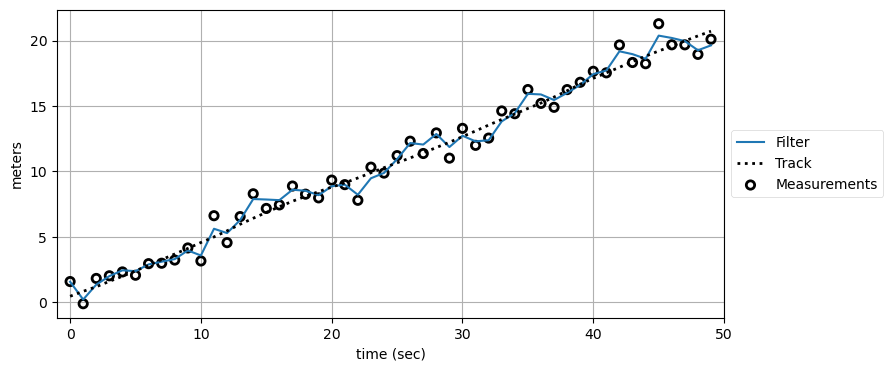

In [27]:
kf2 = SecondOrderKF(R, Q, dt=1)
data2 = filter_data(kf2, zs)
plot_kf_output(xs, data2.x, data2.z)

Did this perform as you expected?

这是否符合你的预期？
We can see that second order filter performs poorly compared to the first order filter. Why? This  filter models acceleration, and so the large changes in the measurement gets interpreted as acceleration instead of noise. Thus the filter closely tracks the noise. Not only that, but it *overshoots* the noise in places if the noise is consistently above or below the track because the filter incorrectly assumes an acceleration that does not exist, and so it's prediction goes further and further away from the track on each measurement. This is not a good state of affairs.

我们可以看到二阶滤波器与一阶滤波器相比表现不佳。为什么？该滤波器模拟加速度，因此测量中的大变化被解释为加速度而不是噪声。因此，滤波器密切跟踪噪声。不仅如此，如果噪声始终高于或低于轨道，它会在某些地方*过冲*噪声，因为滤波器错误地假定了不存在的加速度，于是它每做一次测量，预测就离轨迹更远一点。这种情况可不妙。
Still, the track doesn't look *horrible*. Let's see the story that the residuals tell. I will add a wrinkle here. The residuals for the second order system do not look terrible in that they do not diverge or exceed three standard deviations. However, it is very telling to look at the residuals for the first order vs the second order filter, so I have plotted both on the same graph.

不过，这条轨迹看起来并不*糟糕*。让我们看看残差说明了什么。这里我要补充一个细节。二阶系统的残差看起来并不糟糕，因为它们既不发散，也没有超过三个标准差。但是，查看一阶滤波器与二阶滤波器的残差非常有说服力，因此我将两者绘制在同一张图上。


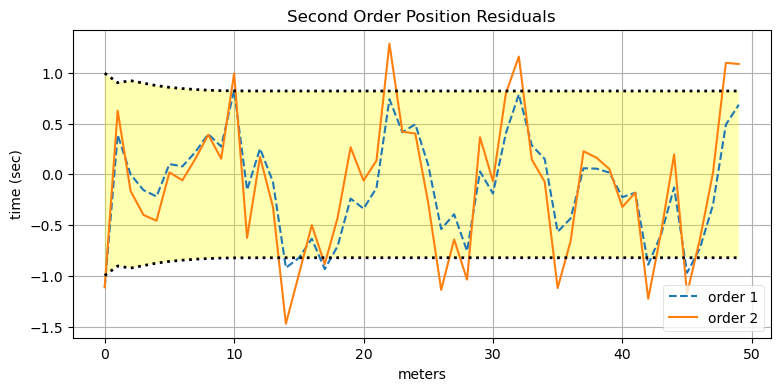

In [28]:
res2 = xs[:, 0] - data2.x[:, 0]
res1 = xs[:, 0] - data1.x[:, 0]

plt.plot(res1, ls="--", label='order 1')
plt.plot(res2, label='order 2')
plot_residual_limits(data2.P[:, 0, 0])
set_labels('Second Order Position Residuals',
           'meters', 'time (sec)')
plt.legend();

The second order position residuals are slightly worse than the residuals of the first order filter, but they still fall within the theoretical limits of the filter. There is nothing very alarming here.

二阶位置残差比一阶滤波器的残差略差，但仍落在滤波器的理论极限之内。这里没有什么非常令人担忧的。
Now let's look at the residuals for the velocity.

现在让我们看看速度的残差。


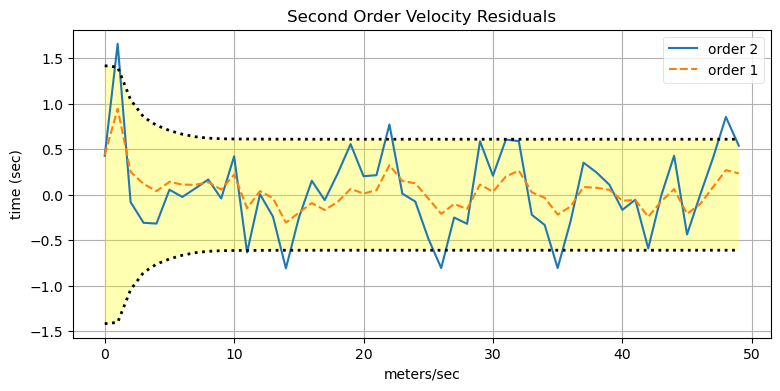

In [29]:
res2 = xs[:, 1] - data2.x[:, 1]
res1 = xs[:, 1] - data1.x[:, 1]

plt.plot(res2, label='order 2')
plt.plot(res1, ls='--', label='order 1')
plot_residual_limits(data2.P[:, 1, 1])
set_labels('Second Order Velocity Residuals', 
                      'meters/sec', 'time (sec)')
plt.legend();

Here the story is very different. While the residuals of the second order system fall within the theoretical bounds of the filter's performance, we can see that the residuals are *far* worse than for the first order filter. This is the usual result for this scenario. The filter is assuming that there is acceleration that does not exist. It mistakes noise in the measurement as acceleration and this gets added into the velocity estimate on every predict cycle. Of course the acceleration is not actually there and so the residual for the velocity is much larger than its optimum.

这里的故事非常不同。虽然二阶系统的残差落在滤波器性能的理论范围内，但我们可以看到残差*远*比一阶滤波器差。这是这种情况的通常结果。滤波器假定了一个并不存在的加速度。它将测量中的噪声误认为是加速度，并在每个预测周期中将其添加到速度估计中。而加速度实际上并不存在，所以速度的残差远大于最佳值。


I have one more trick up my sleeve. We have a first order system; i.e. the velocity is more-or-less constant. Real world systems are never perfect, so of course the velocity is never exactly the same between time periods. When we use a first order filter we account for that slight variation in velocity with the *process noise*. The matrix $\mathbf Q$ is computed to account for this slight variation. If we move to a second order filter we are now accounting for the changes in velocity. Perhaps now we have no process noise, and we can set $\mathbf Q$ to zero!

我还有一个绝招。我们有一个一阶系统，也就是说速度或多或少是恒定的。现实世界的系统从来都不是完美的，所以速度在不同时间段之间当然不会完全相同。当我们使用一阶滤波器时，会用*过程噪声*来考虑速度的轻微变化。计算矩阵 $\mathbf Q$ 时会考虑这种轻微变化。如果我们转向二阶滤波器，现在就能考虑速度的变化。也许此时我们没有过程噪声，可以将 $\mathbf Q$ 设置为零！


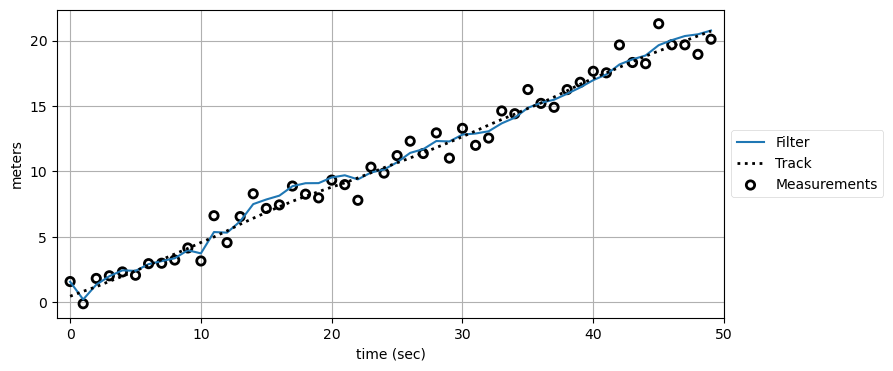

In [30]:
kf2 = SecondOrderKF(R, 0, dt=1)
data2 = filter_data(kf2, zs)
plot_kf_output(xs, data2.x, data2.z)

To my eye it looks like the filter quickly converges to the actual track. Success!
我看来，滤波器似乎很快收敛到了实际轨迹。成功！

Or, maybe not. Setting the process noise to 0 tells the filter that the process model is perfect. Let's look at the performance of the filter over a longer period of time.

或者，也许并不是。将过程噪声设置为 0，等于告诉滤波器过程模型是完美的。让我们看看滤波器在更长时间内的表现。


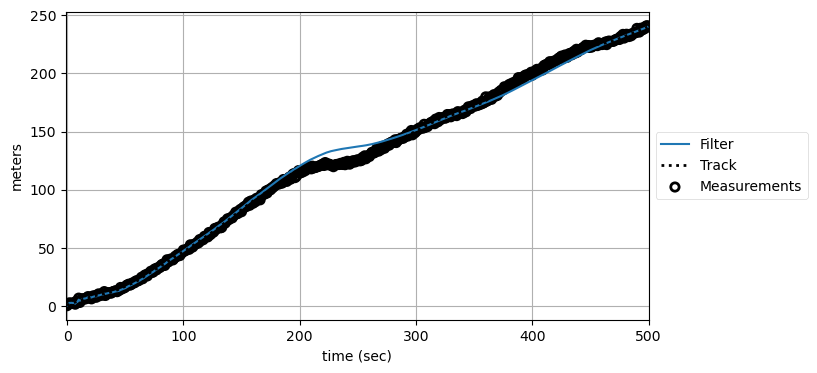

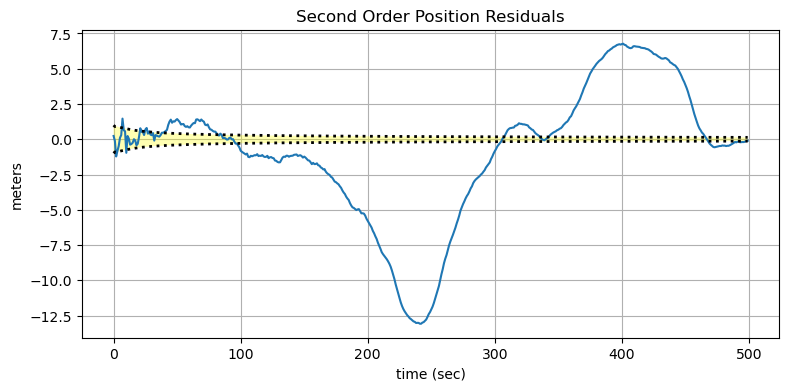

In [31]:
np.random.seed(25944)
xs500, zs500 = simulate_system(Q=Q, count=500)

kf2 = SecondOrderKF(R, 0, dt=1)
data500 = filter_data(kf2, zs500)

plot_kf_output(xs500, data500.x, data500.z)
plot_residuals(xs500[:, 0], data500, 0, 
               'Second Order Position Residuals',
               'meters') 

We can see that the performance of the filter is abysmal. We can see that in the track plot where the filter diverges from the track for an extended period of time. The residual plot makes the problem more apparent. Just before the 100th update the filter diverges sharply from the theoretical performance. It *might* be converging at the end, but I doubt it. The entire time, the filter is reporting smaller and smaller variances. **Do not trust the filter's covariance matrix to tell you if the filter is performing well**!

我们可以看到滤波器的性能非常糟糕。我们可以在轨迹图中看到，滤波器长时间偏离轨迹。残差图使问题更加明显。就在第 100 次更新之前，滤波器与理论性能急剧偏离。它*可能*最终会收敛，但我对此表示怀疑。自始至终，滤波器报告的方差越来越小。**不要相信滤波器的协方差矩阵会告诉你滤波器是否表现良好**！

Why is this happening? Recall that if we set the process noise to zero we are telling the filter to use only the process model. The measurements end up getting ignored. The physical system is *not* perfect, and so the filter is unable to adapt to this imperfect behavior.

为什么会这样？回想一下，如果我们将过程噪声设置为零，我们是在告诉滤波器仅使用过程模型。测量结果最终被忽略。物理系统*不*完美，因此滤波器无法适应这种不完美的行为。

Maybe just a really low process noise? Let's try that.

也许只使用一个非常低的过程噪声？让我们试试看。


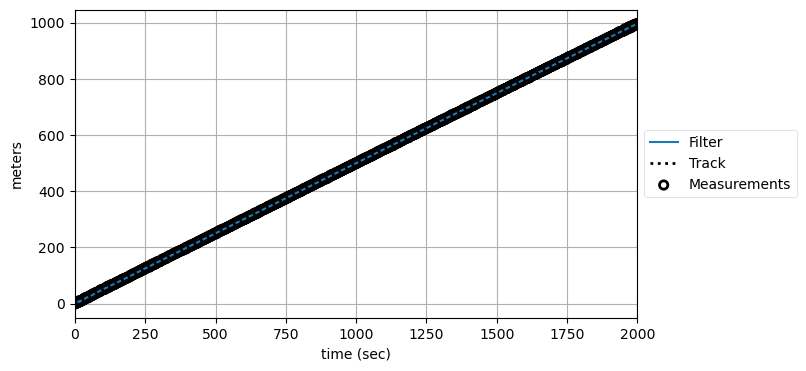

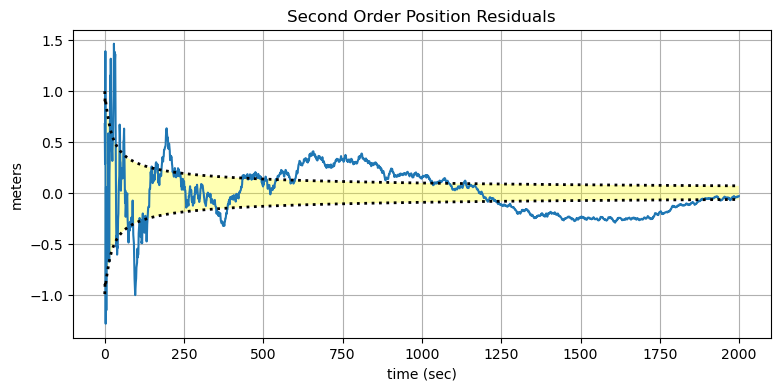

In [32]:
np.random.seed(32594)
xs2000, zs2000 = simulate_system(Q=0.0001, count=2000)

kf2 = SecondOrderKF(R, 0, dt=1)
data2000 = filter_data(kf2, zs2000)

plot_kf_output(xs2000, data2000.x, data2000.z)
plot_residuals(xs2000[:, 0], data2000, 0, 
               'Second Order Position Residuals',
               'meters') 

Again, the residual plot tells the story. The track looks very good, but the residual plot shows that the filter is diverging for significant periods of time.

再次，残差图说明了问题。轨迹看起来非常好，但残差图显示滤波器在很长一段时间内都在发散。

How should you think about all of this? You might argue that the last plot is 'good enough' for your application, and perhaps it is. I warn you however that a diverging filter doesn't always converge. With a different data set, or a physical system that performs differently you can end up with a filter that veers further and further away from the measurements.

你应该如何看待这一切？你可能会认为，最后一张图对于你的应用来说“足够好”，也许确实如此。不过我要提醒你，发散的滤波器并不总是会收敛。换一组数据，或者换一个表现不同的物理系统，你最终可能会得到一个越来越偏离测量值的滤波器。

Also, let's think about this in a data fitting sense. Suppose I give you two points, and tell you to fit a straight line to the points.

另外，让我们从数据拟合的角度来考虑这个问题。假设我给你两个点，并告诉你用一条直线拟合这些点。


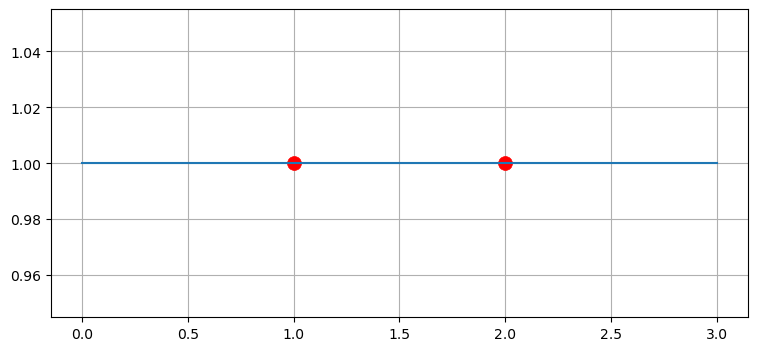

In [33]:
plt.scatter([1, 2], [1, 1], s=100, c='r')
plt.plot([0, 3], [1, 1]);

A straight line is the only possible answer. Furthermore, the answer is optimal. If I gave you more points you could use a least squares fit to find the best line, and the answer would still be optimal in a least squares sense.

直线是唯一可能的答案，而且这个答案是最优的。如果我给你更多的点，你可以使用最小二乘拟合来找到最佳直线，而这个答案在最小二乘意义上仍然是最优的。

But suppose I told you to fit a higher order polynomial to those two points. There are an infinite number of answers to the problem. For example, an infinite number of second order parabolas pass through those points. When the Kalman filter is of higher order than your physical process it also has an infinite number of solutions to choose from. The answer is not just non-optimal, it often diverges and never recovers.

但是，假设我让你用高阶多项式拟合这两个点。这个问题有无穷多个答案。例如，有无穷多条二阶抛物线会经过这两个点。当卡尔曼滤波器的阶数高于物理过程时，它同样有无穷多个解可供选择。答案不只是非最优，它还经常会发散并且永远无法恢复。

For best performance you need a filter whose order matches the system's order. In many cases that will be easy to do, if you are designing a Kalman filter to read the thermometer of a freezer it seems clear that a zero order filter is the right choice. But what order should we use if we are tracking a car? Order one will work well while the car is moving in a straight line at a constant speed, but cars turn, speed up, and slow down, in which case a second order filter will perform better. That is the problem addressed in the Adaptive Filters chapter. There we will learn how to design a filter that adapts to changing order in the tracked object's behavior.

为了获得最佳性能，你需要一个阶数与系统阶数匹配的滤波器。很多时候这很容易做到。如果你正在设计一个读取冰箱温度计的卡尔曼滤波器，那么显然零阶滤波器是正确选择。但是，如果我们要跟踪一辆汽车，应该使用几阶呢？汽车以恒定速度直线行驶时，一阶滤波器效果很好，但汽车会转弯、加速和减速，此时二阶滤波器表现更好。这正是“自适应滤波器”一章要解决的问题。在那里，我们将学习如何设计一个能适应被跟踪对象行为阶数变化的滤波器。

With that said, a lower order filter can track a higher order process so long as you add enough process noise and you keep the discretization period small (100 samples a second are usually locally linear). The results will not be optimal, but they can still be very good, and I always reach for this tool first before trying an adaptive filter. Let's look at an example with acceleration. First, the simulation.

话虽如此，只要加入足够的过程噪声，并保持离散化周期较小，低阶滤波器也能跟踪高阶过程（每秒 100 个采样点通常可以视为局部线性）。结果不会是最优的，但仍然可能非常好。在尝试自适应滤波器之前，我总是先使用这个工具。让我们看一个带加速度的例子。首先来看模拟。


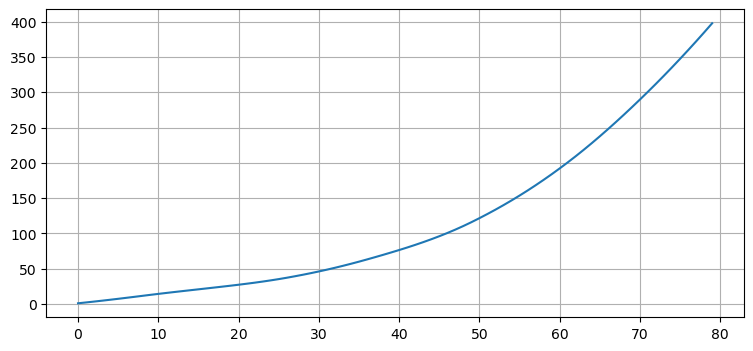

In [34]:
class ConstantAccelerationObject(object):
    def __init__(self, x0=0, vel=1., acc=0.1, acc_noise=.1):
        self.x = x0
        self.vel = vel
        self.acc = acc
        self.acc_noise_scale = acc_noise
    
    def update(self):
        self.acc += randn() * self.acc_noise_scale       
        self.vel += self.acc
        self.x += self.vel
        return (self.x, self.vel, self.acc)
  
R, Q = 6., 0.02
def simulate_acc_system(R, Q, count):
    obj = ConstantAccelerationObject(acc_noise=Q)
    zs = []
    xs = []
    for i in range(count):
        x = obj.update()
        z = sense(x, R)
        xs.append(x)
        zs.append(z)
    return np.asarray(xs), zs

np.random.seed(124)
xs, zs = simulate_acc_system(R=R, Q=Q, count=80)
plt.plot(xs[:, 0]);

Now we will filter the data using a second order filter.

现在我们将使用二阶滤波器来过滤数据。


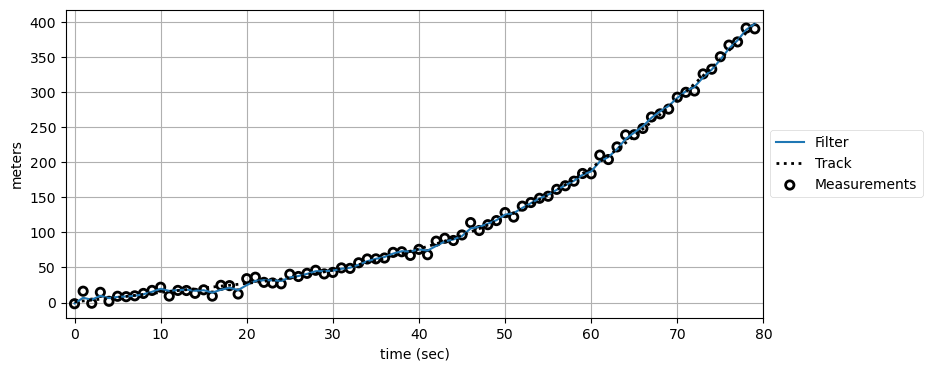

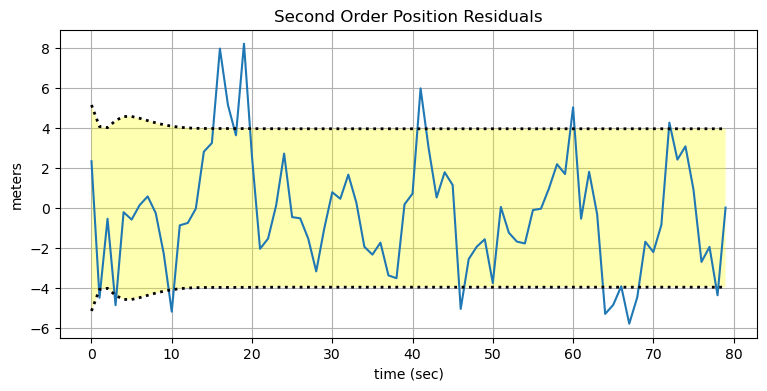

In [35]:
np.random.seed(124)
xs, zs = simulate_acc_system(R=R, Q=Q, count=80)

kf2 = SecondOrderKF(R, Q, dt=1)
data2 = filter_data(kf2, zs)

plot_kf_output(xs, data2.x, data2.z, aspect_equal=False)
plot_residuals(xs[:, 0], data2, 0, 
               'Second Order Position Residuals',
               'meters') 

We can see that the filter is performing within the theoretical limits of the filter.

我们可以看到，滤波器的表现处于其理论限制范围内。

Now let's use a lower order filter. As already demonstrated the lower order filter will lag the signal because it is not modeling the acceleration. However, we can account for that (to an extent) by increasing the size of the process noise. The filter will treat the acceleration as noise in the process model. The result will be suboptimal, but if designed well it will not diverge. Choosing the amount of extra process noise is not an exact science. You will have to experiment with representative data. Here, I've multiplied it by 10, and am getting good results.

现在让我们使用一个低阶滤波器。正如之前所示，低阶滤波器没有对加速度建模，因此会滞后于信号。不过，我们可以通过增大过程噪声的大小，在一定程度上补偿这一点。滤波器会将加速度视为过程模型中的噪声。结果不会是最优的，但如果设计得当，就不会发散。额外过程噪声的取值没有精确的规则，你需要使用有代表性的数据进行试验。这里我将它乘以 10，得到了不错的结果。


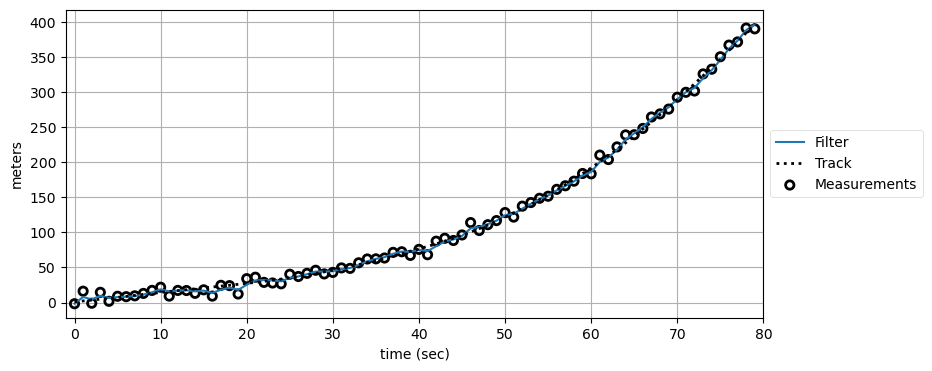

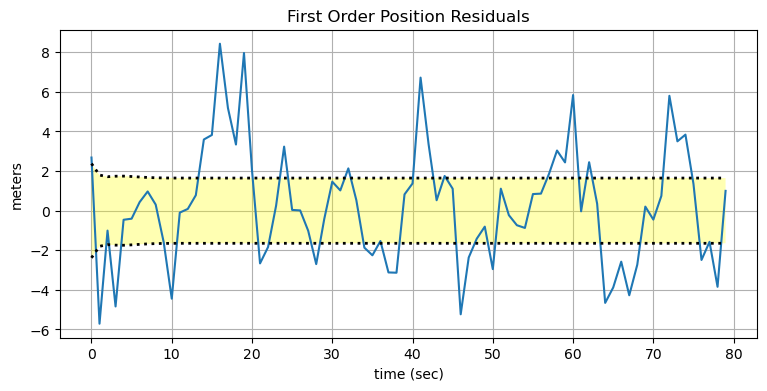

In [36]:
kf3 = FirstOrderKF(R, Q * 10, dt=1)
data3= filter_data(kf3, zs)

plot_kf_output(xs, data3.x, data3.z, aspect_equal=False)
plot_residuals(xs[:, 0], data3, 0, 
               'First Order Position Residuals',
               'meters') 

Think about what will happen if you make the process noise many times larger than it needs to be. A large process noise tells the filter to favor the measurements, so we would expect the filter to closely mimic the noise in the measurements. Let's find out.

想想如果把过程噪声设置得比所需值大很多倍会发生什么。较大的过程噪声会告诉滤波器偏重测量值，因此我们预计滤波器会紧密地模仿测量中的噪声。让我们看看实际情况。


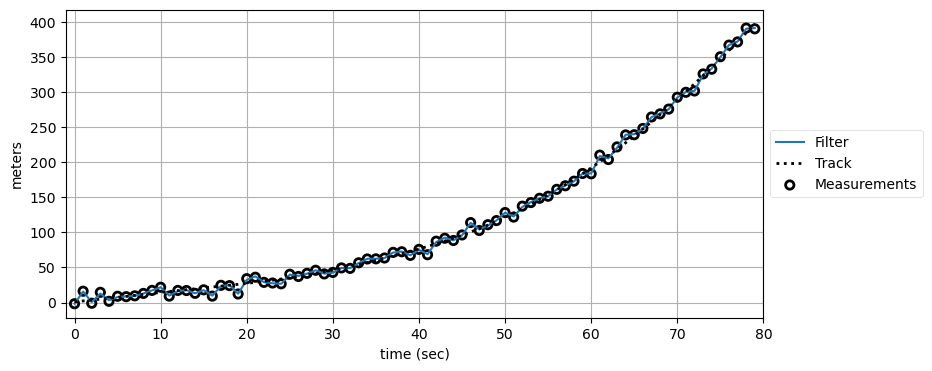

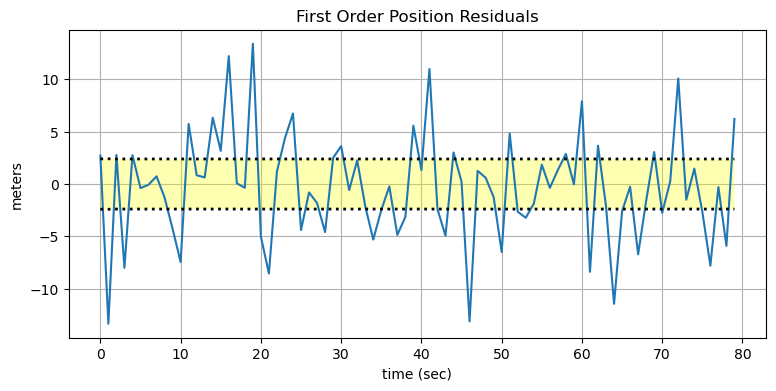

In [37]:
kf4 = FirstOrderKF(R, Q * 10000, dt=1)
data4 = filter_data(kf4, zs)

plot_kf_output(xs, data4.x, data4.z, aspect_equal=False)
plot_residuals(xs[:, 0], data4, 0, 
               'First Order Position Residuals',
               'meters') 

## Exercise: State Variable Design
## 练习：状态变量设计

As I've mentioned, you may place the variables in $\mathbf x$ in whatever order you choose. For example, you could define a 1D constant acceleration as $\mathbf x = \begin{bmatrix}\ddot x & x & \dot x\end{bmatrix}^\mathsf T$. I can't imagine why you would want that order, but it is possible.

正如我提到的，你可以按任意顺序将变量放入 $\mathbf x$。例如，你可以将一维恒定加速度定义为 $\mathbf x = \begin{bmatrix}\ddot x & x & \dot x\end{bmatrix}^\mathsf T$。我想不出你为什么要采用这种顺序，但这是可以的。

Let's do something more reasonable. Design a second order filter for a robot moving in 2D, where $\mathbf x = \begin{bmatrix}x & y & \dot x & \dot y \end{bmatrix}^\mathsf T$. In this chapter we have been using $\mathbf x = \begin{bmatrix}x & \dot x & y & \dot y \end{bmatrix}^\mathsf T$.

让我们做些更合理的事情。为一个在二维空间中运动的机器人设计二阶滤波器，其中 $\mathbf x = \begin{bmatrix}x & y & \dot x & \dot y \end{bmatrix}^\mathsf T$。本章一直使用的是 $\mathbf x = \begin{bmatrix}x & \dot x & y & \dot y \end{bmatrix}^\mathsf T$。

Why would you choose a different ordering? As you'll see in a moment, changing the order of $\mathbf x$ changes the order of most of the rest of the filter's matrices. Depending on what data you want to inspect, such as the correlations in $\mathbf P$, various orderings of $\mathbf x$ can make that easier or more difficult.

为什么要选择不同的顺序？你马上就会看到，更改 $\mathbf x$ 的顺序会改变滤波器大多数其他矩阵的顺序。根据你想检查的数据，例如 $\mathbf P$ 中的相关性，$\mathbf x$ 的不同排列可能会让检查变得更容易，也可能更困难。

Think about how to do this. What needs to change? Clearly, you just need to change the Kalman filter matrices to reflect this new design.

想想该怎么做。需要改变什么？显然，你只需要更改卡尔曼滤波器矩阵，使其反映这种新设计。

Give it a try below using this boilerplate code:

使用下面的样板代码试试看：

```python

N = 30 # number of iterations
dt = 1.0 # time step
R_std = 0.35
Q_std = 0.04

sensor = PosSensor((0, 0), (2, .5), noise_std=R_std)
zs = np.array([sensor.read() for _ in range(N)])

tracker = KalmanFilter(dim_x=4, dim_z=2)
# assign state variables here

xs, ys = [], []
for z in zs:
    tracker.predict()
    tracker.update(z)
    xs.append(tracker.x[0])
    ys.append(tracker.x[1])
plt.plot(xs, ys);
```


### Solution
### 解答


Let's start with $\mathbf F$. With a bit of practice you should be able to just write out the matrix. If you found that difficult, then write out the set of equations for $\mathbf F$ ordering the variables as used by the state variable.

让我们从 $\mathbf F$ 开始。练习几次后，你应该能够直接写出矩阵。如果觉得困难，就先写出 $\mathbf F$ 的方程组，并按照状态变量使用的顺序排列变量。

$$
x = 1x + 0y + 1\dot x\Delta t + 0 \dot y\Delta t \\
y = 0x + 1y + 0\dot x\Delta t + 1 \dot y\Delta t \\
\dot x = 0x + 0y + 1\dot x\Delta t + 0 \dot y\Delta t \\
\dot y = 0x + 0y + 0\dot x\Delta t + 1 \dot y\Delta t 
$$

We can copy out the coefficients to get

我们可以抄出系数，得到

$$\mathbf F = \begin{bmatrix}1&0&\Delta t & 0\\0&1&0&\Delta t\\0&0&1&0\\0&0&0&1\end{bmatrix}$$

The state noise also requires shuffling things around. First, figure out how it should be arranged for the state variable ordering. This can be easier if you write the state variables vertically and horizontally across the matrix to see how they pair up. This is hard to do in Jupyter notebook, so I will forgo it here.

状态噪声也需要重新排列。首先，确定它应如何按照状态变量的顺序排列。如果在矩阵的纵向和横向都写出状态变量，观察它们如何两两配对，会更容易一些。这在 Jupyter notebook 中很难完成，所以这里就不展示了。

$$\mathbf Q = 
\begin{bmatrix}
\sigma_x^2 & \sigma_{xy} & \sigma_{x\dot x} & \sigma_{x\dot y} \\
\sigma_{yx} & \sigma_y^2 & \sigma_{y\dot x} & \sigma_{y\dot y} \\
\sigma_{\dot x x} & \sigma_{\dot x y} & \sigma_{\dot x}^2 & \sigma_{\dot x \dot y} \\
\sigma_{\dot y x} & \sigma_{\dot y y} & \sigma_{\dot y \dot x} & \sigma_{\dot y}^2
\end{bmatrix}
$$

There is no correlation between $x$ and $y$, so we can set terms with both to zero

$x$ 和 $y$ 之间没有相关性，所以可以将同时包含二者的项设为零

$$\mathbf Q = 
\begin{bmatrix}
\sigma_x^2 & 0 & \sigma_{x\dot x} & 0 \\
0 & \sigma_y^2 & 0 & \sigma_{y\dot y} \\
\sigma_{\dot x x} & 0 & \sigma_{\dot x}^2 & 0 \\
0 & \sigma_{\dot y y} & 0 & \sigma_{\dot y}^2
\end{bmatrix}
$$

Now that you see this you can see the pattern and perhaps design $\mathbf Q$ more quickly.

现在你看到了这个模式，或许可以更快地设计 $\mathbf Q$。

`Q_discrete_white_noise` generates a matrix with a different ordering, but we can just copy terms from it, which we will see in the code below.

`Q_discrete_white_noise` 生成的矩阵顺序不同，但我们可以直接从中复制各项，下面的代码中会看到这一点。

Now let's design $\mathbf H$. It converts the state $\begin{bmatrix}x & y & \dot x & \dot y \end{bmatrix}^\mathsf T$ into the measurement $\mathbf z = \begin{bmatrix}z_x & z_y\end{bmatrix}^\mathsf T$.

现在来设计 $\mathbf H$。它将状态 $\begin{bmatrix}x & y & \dot x & \dot y \end{bmatrix}^\mathsf T$ 转换为测量值 $\mathbf z = \begin{bmatrix}z_x & z_y\end{bmatrix}^\mathsf T$。

$$
\begin{aligned}
\mathbf{Hx} &= \mathbf z \\
\begin{bmatrix}?&?&?&?\\?&?&?&?\end{bmatrix}\begin{bmatrix}x \\ y \\ \dot x \\ \dot y \end{bmatrix} &= \begin{bmatrix}z_x \\ z_y\end{bmatrix}
\end{aligned}
$$

Now it should be easy to fill in the matrix:

现在应该很容易填出矩阵：

$$
\begin{bmatrix}1&0&0&0\\0&1&0&0\end{bmatrix}\begin{bmatrix}x \\ y \\ \dot x \\ \dot y \end{bmatrix} = \begin{bmatrix}z_x \\ z_y\end{bmatrix}
$$

The measurement $\mathbf z = \begin{bmatrix}z_x & z_y\end{bmatrix}^\mathsf T$ has not changed so $\mathbf R$ does not change.

测量值 $\mathbf z = \begin{bmatrix}z_x & z_y\end{bmatrix}^\mathsf T$ 没有改变，所以 $\mathbf R$ 也不变。

Finally, $\mathbf P$. It uses the same ordering as $\mathbf Q$, so it is already designed for us.

最后是 $\mathbf P$。它与 $\mathbf Q$ 使用相同的顺序，因此已经为我们设计好了。


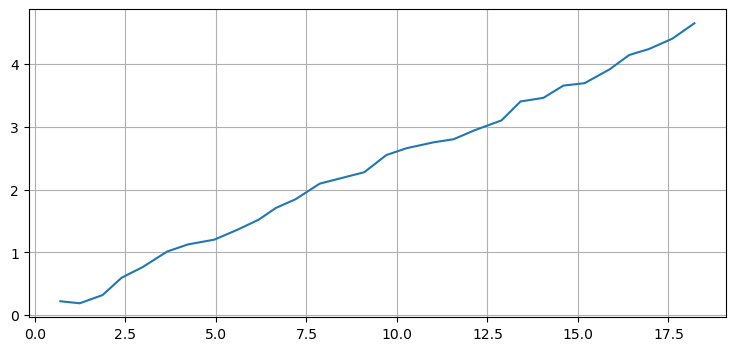

In [38]:
N = 30 # number of iterations
dt = 1.0 # time step
R_std = 0.35
Q_std = 0.04

M_TO_FT = 1 / 0.3048

sensor = PosSensor((0, 0), (2, .5), noise_std=R_std)
zs = np.array([sensor.read() for _ in range(N)])

tracker = KalmanFilter(dim_x=4, dim_z=2)

tracker.F = np.array([[1, 0, dt,  0],
                      [0, 1,  0, dt],
                      [0, 0,  1,  0],
                      [0, 0,  0,  1]])

tracker.H = np.array([[M_TO_FT, 0, 0, 0],
                      [0, M_TO_FT, 0, 0]])

tracker.R = np.eye(2) * R_std**2
q = Q_discrete_white_noise(dim=2, dt=dt, var=Q_std**2)
tracker.Q[0,0] = q[0,0]
tracker.Q[1,1] = q[0,0]
tracker.Q[2,2] = q[1,1]
tracker.Q[3,3] = q[1,1]
tracker.Q[0,2] = q[0,1]
tracker.Q[2,0] = q[0,1]
tracker.Q[1,3] = q[0,1]
tracker.Q[3,1] = q[0,1]

tracker.x = np.array([[0, 0, 0, 0]]).T
tracker.P = np.eye(4) * 500.

xs, ys = [], []
for z in zs:
    tracker.predict()
    tracker.update(z)
    xs.append(tracker.x[0])
    ys.append(tracker.x[1])
plt.plot(xs, ys);

## Detecting and Rejecting Bad Measurement
## 检测并剔除坏测量

The Kalman filter provides no way to detect and reject a bad measurement. Suppose you are tracking aircraft, and you receive a measurement 100km away from the aircraft's current position. If you call update with that value the new estimate will be skewed radically towards the measurement.

卡尔曼滤波器没有检测和拒绝错误测量的方法。假设你正在跟踪一架飞机，却收到一个距离飞机当前位置 100 公里的测量值。如果用这个值调用 update，新的估计值就会严重偏向该测量值。

I'll run a simulation to give us a concrete example. After 100 epoch's I'll do an update with a measurement equal to twice the current position. `filterpy.common` provides `kinematic_kf` which creates a linear kinematic filter of arbitrary dimension and order. I'll use it here to keep the code tidy, I don't use it in the rest of the book because I want you to get lots of practice writing filters.

我将运行一个模拟来给出具体示例。经过 100 个周期后，我会用当前位置两倍的测量值进行一次更新。`filterpy.common` 提供了 `kinematic_kf`，可以创建任意维度和阶数的线性运动学滤波器。这里使用它是为了让代码简洁，本书其余部分不会使用它，因为我希望你能充分练习编写滤波器。


In [39]:
from filterpy.common import kinematic_kf

kf = kinematic_kf(dim=2, order=1, dt=1.0, order_by_dim=False)
kf.Q = np.diag([0, 0, .003, .003])
kf.x = np.array([[1., 1., 0., 0.]]).T
kf.R = np.diag([0.03, 0.21]) # use different errors

for i in range(101):
    kf.predict()
    kf.update(np.array([[i*.05, i*.05]])) # around 200 kph

p0 = kf.x[0:2]

kf.predict()
prior = kf.x
z = kf.x[0:2]*2
kf.update(z)
p1 = kf.x[0:2]

# compute error of measurement from prior
y = np.abs(z - kf.H @ prior)
dist = np.linalg.norm(y)

np.set_printoptions(precision=2, suppress=True)

print(f'bad measurement       : {z.T} km')
print(f'before bad measurement: {p0.T} km')
print(f'after bad measurement : {p1.T} km')
print(f'estimate shift        : {np.linalg.norm(p1 - prior[:2]):.1f} km')
print(f'distance from prior   : {dist:.1f} km')

bad measurement       : [[10.1 10.1]] km
before bad measurement: [[5. 5.]] km
after bad measurement : [[7.84 7.01]] km
estimate shift        : 3.4 km
distance from prior   : 7.1 km


`kinematic_kf`? What's that? `filterpy.common` provides `kinematic_kf` to allow you to create a linear kinematic filter of arbitrary dimension and order. I don't use it in this book because I want you to gain a lot of experience creating Kalman filters. I used it here just to keep my example short and to expose you to this part of the library.

`kinematic_kf`？那是什么？`filterpy.common` 提供 `kinematic_kf`，允许你创建任意维度和阶数的线性运动学滤波器。我没有在本书中使用它，因为我希望你积累创建卡尔曼滤波器的经验。这里使用它只是为了让示例简短，并让你了解这个库的这一部分。

Back on topic. As you can see the estimate jumped 3.4 km, and the error between the prediction (prior) and the measurement is over 7 km.

回到主题。如你所见，估计值跳跃了 3.4 公里，预测值（先验）与测量值之间的误差超过 7 公里。

What can we do to avoid this? Our first thought might be to just add a check if the prior is far from the measurement. Why the prior and not the current estimate? Because after the update the estimate could now be quite close to the bad measurement, although it isn't in this case.

我们可以怎样避免这种情况？首先可能会想到，添加一个检查，判断先验是否远离测量值。为什么检查先验而不是当前估计值？因为更新后，估计值可能已经非常接近错误测量值，尽管本例并非如此。

Note that while I could have just written `prior[0:2] - z` to get the error, I used the mathematically correct $\mathbf z - \mathbf{Hx}$ to compute the error. This is just for illustration; the Kalman filter class stores the innovation in `KalmanFilter.y`. I use it instead of the value I computed above to illustrate this:

请注意，虽然我本可以直接写 `prior[0:2] - z` 来得到误差，但我使用数学上正确的 $\mathbf z - \mathbf{Hx}$ 来计算误差。这只是为了说明问题，卡尔曼滤波器类会将新息存储在 `KalmanFilter.y` 中。下面我使用它，而不是上面计算出的值来进行说明：


In [40]:
print(f'error = {np.linalg.norm(kf.y):.1f} km, at a speed of {dist*3600:.0f} kph')

error = 7.1 km, at a speed of 25710 kph


In this example the measurement is nearly 7 km away from the predicted position. That sounds "far". Is it? It could be far if the units are kilometers and the update rate is 1 second; no aircraft can travel the over 25000 kph this error implies. It could be absurdly small if the units are centimeters and the epoch is 1 minute.

在这个例子中，测量值距离预测位置近 7 公里。这听起来很“远”。真的是这样吗？如果单位是公里且更新率为 1 秒，它可能确实很远，因为没有飞机能以这个误差所暗示的超过 25000 千米/小时的速度飞行。如果单位是厘米且周期为 1 分钟，这个误差又可能小得离谱。

We could add a check that either takes the performance limits of the aircraft into account:

我们可以添加一个检查，将飞机的性能限制考虑在内：

```
vel = y / dt
if vel >= MIN_AC_VELOCITY and vel <= MAX_AC_VELOCITY:
    kf.update()
```

Do you think this is a reasonable and robust solution? Come up with as many objections as you can before reading further.

你认为这是合理且稳健的解决方案吗？继续阅读之前，尽可能多地提出反对意见。

This is not very satisfying to me. Suppose we had just initialized the filter with an guessed at position; we would discard good measurements and never start filtering. Second, this ignores the knowledge we have about the sensor and process errors. The Kalman filter maintains its current accuracy in $\mathbf P$. If $\mathbf P$ implies that $\sigma_x = 10$ meters, and the measurement is 1 km away, clearly the measurement is bad as it is 100 standard deviations away from the prior.

这对我来说并不令人满意。假设我们刚刚用一个猜测的位置初始化了滤波器，我们会丢弃正确的测量值，永远无法开始滤波。其次，这忽略了我们对传感器误差和过程误差的了解。卡尔曼滤波器在 $\mathbf P$ 中维护当前精度。如果 $\mathbf P$ 表明 $\sigma_x = 10$ 米，而测量值相距 1 公里，那么显然这个测量值是错误的，因为它距离先验有 100 个标准差。

Let's plot $\mathbf P$. I'll plot the first, second, and third standard deviations.

让我们绘制 $\mathbf P$。我将绘制第一、第二和第三个标准差。


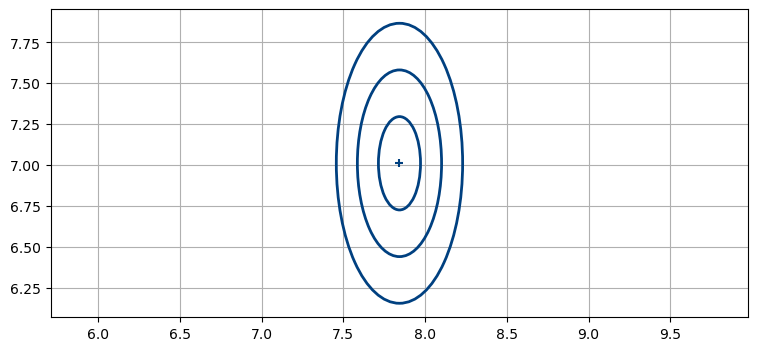

In [41]:
x, P = kf.x[0:2], kf.P[0:2, 0:2]
plot_covariance_ellipse(x, P, std=[1,2,3])

In previous sections $\mathbf P$ was a cicle, not an ellipse. In my code I set  $\mathbf R = \bigl[ \begin{smallmatrix}0.03 & 0 \\ 0 & 0.15\end{smallmatrix}\bigl ]$, which gives the measurement of $y$ 5 times the error of $x$. That's somewhat artificial, but in subsequent chapters nearly all of the covariances will be elliptical for good reasons.

在前面的章节中，$\mathbf P$ 是圆形而不是椭圆形。在代码中，我设置 $\mathbf R = \bigl[ \begin{smallmatrix}0.03 & 0 \\ 0 & 0.15\end{smallmatrix}\bigl ]$，这使得 $y$ 的测量误差是 $x$ 的 5 倍。这有些人为，但在后续章节中，几乎所有协方差都会因为充分的理由呈椭圆形。

Think about what this means. Statistics tells us that 99% of all measurements fall within 3 standard deviations; that means 99% of all measurements should be within this ellipse. Let's plot the measurement with the ellipse.

想想这意味着什么。统计学告诉我们，99% 的测量值会落在 3 个标准差以内，也就是说，99% 的测量值应该位于这个椭圆内。让我们将测量值和椭圆一起绘制出来。


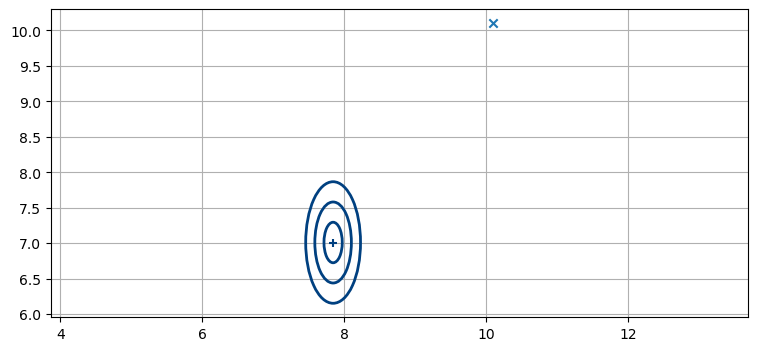

In [42]:
plot_covariance_ellipse(x, P, std=[1,2,3])
plt.scatter(z[0], z[1], marker='x');

Clearly the measurement is far beyond the the prior's covariance; we probably want to consider this a bad measurement and not use it. How would we do that?

显然，该测量值远远超出了先验协方差的范围，我们可能会认为这是一个错误测量而不使用它。应该怎样做呢？

The first idea would to be extract the standard deviation for $x$ and $y$ and write a simple if statement. Here I will use another feature of the `KalmanFilter` class. The method `residual_of` computes the residual compared to the prior. I don't need to use it in this case since `kf.y` is already assigned by the call to `update()`, but if we are discarding measurements `update()` would not have been called yet and `kf.y` would contain the innovation from the previous epoch.

第一个想法是提取 $x$ 和 $y$ 的标准差，然后写一个简单的 if 语句。这里我会使用 `KalmanFilter` 类的另一个功能。`residual_of` 方法计算相对于先验的残差。在本例中不需要使用它，因为调用 `update()` 时已经为 `kf.y` 赋值，但如果我们要丢弃测量值，就还不会调用 `update()`，此时 `kf.y` 会包含上一个周期的新息。

First, let's introduce two terms. We are discussing **gating**. A **gate** is a formula or algorithm that determines if a measurement is good or bad. Only good measurements get through the gate. This process is called gating.

首先介绍两个术语。我们讨论的是**门控**。**门**是用于判断测量值好坏的公式或算法。只有正确的测量值才能通过这道门，这个过程称为门控。

In practice measurements are not purely Gaussian, so a gate of 3 standard deviations is likely to discard some good measurements. I will elaborate soon, for now we will use 4 standard deviations

实际测量值并不完全服从高斯分布，因此 3 个标准差的门很可能会丢弃一些正确的测量值。我很快会详细说明这一点，现在我们使用 4 个标准差。


In [43]:
GATE_LIMIT = 4.
std_x = np.sqrt(P[0,0])
std_y = np.sqrt(P[1,1])
y = kf.residual_of(z)[:,0]

if y[0] > GATE_LIMIT * std_x or y[1] > GATE_LIMIT * std_y:
    print(f'discarding measurement, error is {y[0]/std_x:.0f} std, {y[1]/std_y:.0f} std')
    
print('y   is', y)
print(f'std is {std_x:.2f} {std_y:.2f}')

discarding measurement, error is 39 std, 18 std
y   is [5.05 5.05]
std is 0.13 0.29


We see the errors are roughly 39 and 18 standard deviations away. Is this good enough?

我们看到误差大约分别相当于 39 个和 18 个标准差。这够好吗？

Maybe. However, notice that the if statement forms a rectangular region surrounding the ellipse. In the plot below I've drawn a measurement that is clearly outside of the 3 std ellipse, yet would be accepted by the gate, and another measurement that lies just on the 3 std boundary.

也许吧。不过请注意，if 语句在椭圆周围形成了一个矩形区域。在下面的图中，我绘制了一个明显位于 3 个标准差椭圆外、却会被门接受的测量值，以及另一个恰好位于 3 个标准差边界上的测量值。


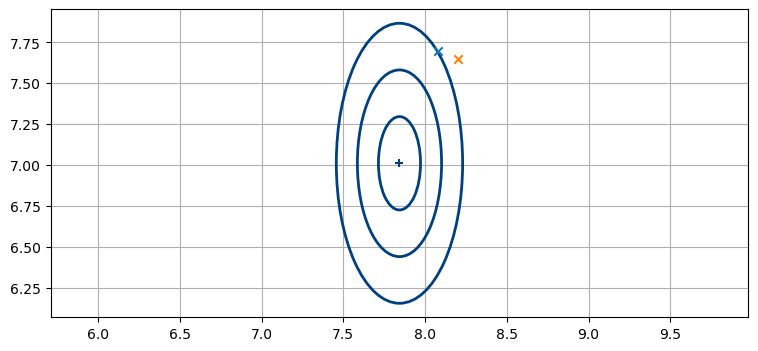

In [44]:
plot_covariance_ellipse(x, P, std=[1,2,3])
plt.scatter(8.08, 7.7, marker='x')
plt.scatter(8.2, 7.65, marker='x');

There are alternative methods of defining this gate. The **mahalanobis distance** is a statistical measure of the distance of a point from a distribution. Before we get to the definition and math, let's compute the mahalanobis distance for some points. `filterpy.stats` implements `mahalanobis()`.

定义这道门还有其他方法。**马哈拉诺比斯距离**是衡量一个点与某个分布之间距离的统计量。在介绍定义和数学公式之前，让我们先计算几个点的马哈拉诺比斯距离。`filterpy.stats` 实现了 `mahalanobis()`。


In [45]:
from filterpy.stats import mahalanobis
m = mahalanobis(x=z, mean=x, cov=P)
print(f'mahalanobis distance = {m:.1f}')

mahalanobis distance = 20.6


Without knowing the units we can compare it to the standard deviation errors computed in $x$ and $y$ separately, 39, and 18, and see that it is reasonably close. Let's see what we get for the point I plotted above.

在不知道单位的情况下，我们可以将它与分别在 $x$ 和 $y$ 中计算出的标准差误差 39 和 18 进行比较，发现它们相当接近。让我们看看上面绘制的那个点得到的结果。


In [46]:
print(f'mahalanobis distance = {mahalanobis(x=[8.08, 7.7], mean=x, cov=P):.1f}')
print(f'mahalanobis distance = {mahalanobis(x=[8.2, 7.65], mean=x, cov=P):.1f}')

mahalanobis distance = 3.0
mahalanobis distance = 3.6


As we will see the mahalanobis distance computes the scalar standard deviation *distance* point to a distribution, much like the Euclidian distance computes a scalar distance from a point to another point.

正如我们将看到的，马哈拉诺比斯距离计算的是点到分布的标量标准差*距离*，很像欧几里得距离计算点到另一个点的标量距离。

The cell above bears that out. The point that was sitting on the 3 std boundary has a mahalanobis distance of 3.0, and the one outside of the ellipse has a value of 3.6 std.

上面的单元格证明了这一点。位于 3 个标准差边界上的点，其马哈拉诺比斯距离为 3.0，而位于椭圆外的点的值为 3.6 个标准差。

How do we compute the mahalanobis distance? It is defined as

如何计算马哈拉诺比斯距离？它的定义是

$$D_m= \sqrt{(\mathbf x-\mu)^\mathsf T \mathbf S^{-1} (\mathbf x-\mu)}$$

Note how similar this is to the Euclidean distance, which we can write as:

注意它与欧几里得距离多么相似，欧几里得距离可以写成：

$$D_e= \sqrt{(\mathbf x-\mathbf y)^\mathsf T (\mathbf x-\mathbf y)}$$

In fact, if the covariance $\mathbf S$ is the identity matrix the mahalanobis distance is the same as the Euclidean distance. You should be able to see how that works with the linear algebra: the inverse of the identity matrix is the identity matrix, so we are effectively multiplying the terms with 1. Think of it intuitively. If the standard deviation in each dimension is 1, then the a point anywhere on a circle of radius 1 around the mean will lie on the 1 std circle and also be 1 *unit* away in Euclidean measure.

事实上，如果协方差 $\mathbf S$ 是单位矩阵，马哈拉诺比斯距离就与欧几里得距离相同。通过线性代数应该可以看出原因：单位矩阵的逆仍是单位矩阵，因此实际上是在将各项乘以 1。直观地想，如果每个维度的标准差都是 1，那么均值周围半径为 1 的圆上的任意点都会位于 1 个标准差的圆上，并且按欧几里得度量也距离均值 1 个*单位*。

This suggests another interpretation. If the covariance matrix is diagonal then we can think of the mahalanobis distance as being the *scaled* Euclidean distance, where each term is scaled by the covariance in the diagonal.

这提示了另一种解释。如果协方差矩阵是对角矩阵，那么可以把马哈拉诺比斯距离看作经过*缩放*的欧几里得距离，其中每一项都由对角线上的协方差进行缩放。

$$D_m = \sqrt{\sum_{i-1}^N \frac{(x_i - \mu_i)^2}{\sigma_i}}$$

在二维情况下，就是

$$D_m = \sqrt {\frac{1}{\sigma_x^2}(x_0 - x_1)^2 + \frac{1}{\sigma_y^2}(y_0 - y_1)^2}$$

This should give you insight into the equation for mahalanobis distance. You cannot divide by a matrix, but multiplying by the inverse is *effectively* the same, in a hand wavey sense. Multiplying by the difference $\mathbf y = \mathbf x - \mathbf \mu$ on each side gives us the squared norm scaled by the covariance: $\mathbf y^\mathsf T \mathbf S^{-1}\mathbf y^\mathsf T$. The covariance terms are all squared, so taking the square root at the end brings us to a scalar distance which is the Euclidean distance scaled by the covariance.

这应该能帮助你理解马哈拉诺比斯距离的方程。不能直接除以矩阵，但从粗略的意义上说，乘以逆矩阵*实际上*等价于除法。在两侧都乘以差值 $\mathbf y = \mathbf x - \mathbf \mu$，就得到由协方差缩放的平方范数：$\mathbf y^\mathsf T \mathbf S^{-1}\mathbf y^\mathsf T$。协方差项都是平方的，所以最后取平方根，就得到一个标量距离，也就是经协方差缩放后的欧几里得距离。


### Gating and Data Association Strategies
### 门控与数据关联策略

The two gates above are known as rectangular and ellipsoidal gates in some of the literature because of their shape. There are more alternatives I will not explore here. For example, a maneuver gate is used to define a region where it is possible for the object to maneuver, taking the object's current velocity and ability to maneuver into account. For example, a fighter jet would have a maneuver gate shaped much like a cone projecting in front of it's current direction of travel. An automobile would have a much smaller 2D pie slice shape projecting in front of it. A ship would have a much narrower slice since it's ability to turn or accelerate quickly is minimal.

上面的两个门因其形状，在一些文献中被称为矩形门和椭圆门。还有其他方法，这里不再展开。例如，机动门用于定义对象可能机动的区域，同时考虑对象当前的速度和机动能力。比如，战斗机的机动门会很像一个从当前行进方向向前延伸的圆锥体。汽车的机动门则是一个小得多的二维扇形区域。船的扇形区域会窄得多，因为它快速转弯或加速的能力很有限。

Which gating technique should you use? There is no single answer. Much depends on the dimensionality of the problem and how much computational power you have. A rectangular gate is very cheap to compute, the maneuver gate isn't much worse, but the ellipsoidal gate can be expensive in higher dimensions. However, as you increase dimensions the relative area difference between the ellipsoid and rectangular gate increases significantly.

应该使用哪种门控技术？没有唯一答案。这很大程度上取决于问题的维度和你拥有的计算能力。矩形门的计算成本很低，机动门也不会贵太多，但椭圆门在高维空间中可能代价高昂。然而，随着维度增加，椭圆门和矩形门之间的相对面积差异会显著增大。

This matters more than you might realize. Every measurement has noise. A spurious measurement can fall *within* our gate, causing us to accept it. The larger the area that extends past the ellipsoid, the larger the probability of the gate passing a bad measurement. I will not do the math here, but in 5 dimensions the rectangular gate is twice as likely to accept a bad measurement as the ellipsoid.

这比你想象的更重要。每个测量值都有噪声。虚假测量值可能落在我们的门*内*，使我们接受它。超出椭圆的区域越大，门放过错误测量值的概率就越大。我不在这里展开数学推导，但在五维空间中，矩形门接受错误测量值的可能性是椭圆门的两倍。

If computational time is a concern and you have many spurious measurements you can take a two gate approach. The first gate is large and rectangular, and used as a first pass to throw away obviously bad measurements. The few measurements that pass that gate are then subjected to the more expensive mahalanobis distance calculation. If you are running on a modern desktop processor the time of those matrix multiplies are not significant, but it may matter if you are running on an embedded chip with modest floating point performance.

如果计算时间是问题，而且有很多虚假测量值，可以采用两道门的方法。第一道门较大且为矩形，用作第一轮筛选，丢弃明显错误的测量值。通过第一道门的少数测量值，再进行代价更高的马哈拉诺比斯距离计算。如果运行在现代桌面处理器上，这些矩阵乘法耗时并不显著，但如果运行在浮点性能一般的嵌入式芯片上，就可能有所影响。

Data association is a vast topic that requires its own book. The canonical example is tracking with radar. The radar detects multiple signals on each sweep. From that we need to form aircraft tracks, and reject noisy measurements. This is a very difficult problem. Suppose the first sweep gets 5 measurements. We would create 5 potential tracks. In the next sweep we get 6 measurements. We can combine any of the first measurements with any of the second measurements, giving us 30 potential tracks. But, it is also possible that these are all new aircraft that we didn't see in the last sweep, so that gives us 6 more tracks. After just a few epochs we reach millions, then billions of potential tracks.

数据关联是一个庞大的主题，值得单独写一本书。典型例子是使用雷达进行跟踪。雷达每次扫描都会检测到多个信号，我们需要据此形成飞机轨迹，并剔除噪声测量。这是一个非常困难的问题。假设第一次扫描得到 5 个测量值，我们会创建 5 条潜在轨迹。下一次扫描得到 6 个测量值。可以将第一次扫描的任意测量值与第二次扫描的任意测量值组合起来，得到 30 条潜在轨迹。但这些也可能全是上次扫描没有看到的新飞机，这样还会多出 6 条轨迹。仅仅几个周期后，潜在轨迹数量就会达到数百万，继而达到数十亿。

Given this list of billions of tracks we can then compute a score for each track. I'll provide the math for that in the following section. But, visualize a track that forms a 'Z' shape over 3 epochs. No aircraft can maneuver like that, so we would give it a very low probability of being real. Another track forms a straight line, but imputes a velocity of 10,000 kph. That is also very improbable. Another track curves at 200 kph. That has a high probability.

有了这份数十亿条轨迹的列表，我们就可以计算每条轨迹的分数。下一节会给出相关数学。不过，想象一条在 3 个周期内形成“Z”形的轨迹。没有飞机能那样机动，所以它真实存在的概率会非常低。另一条轨迹呈直线，但推断出的速度为 10,000 千米/小时，这也极不可能。还有一条轨迹以 200 千米/小时的速度弯曲，这条轨迹的概率就很高。

So tracking becomes a matter of gating, data association, and pruning. For example, say the second radar sweep just occured. Do I combine all possible combinations into a tracks? I probably shouldn't. If point 1, sweep 1 imputes a velocity of 200kph with point 3, sweep 2 we should form a track from it. If the velocity is 5000 kph we shouldn't bother; we know that track is so unlikely as to be impossible. Then, as the tracks grow we will have well defined ellipsoidal or maneuver gates for them, and we can be far more selective about the measurements we associate with tracks.

因此，跟踪就变成了门控、数据关联和剪枝的问题。例如，假设第二次雷达扫描刚刚完成。我是否应该把所有可能的组合都合并成轨迹？大概不应该。如果第一次扫描的第 1 个点与第二次扫描的第 3 个点推断出 200 千米/小时的速度，我们应该据此形成轨迹。如果速度是 5000 千米/小时，就不必继续了，因为我们知道这条轨迹极不可能存在。随着轨迹增长，我们会为它们建立定义明确的椭圆门或机动门，也就能更有选择性地决定哪些测量值与轨迹关联。

There are schemes for associations. We can choose to associate a measurement to only one track. Or, we can choose to associate a measurement with multiple tracks, reflecting our lack of certainty with which track it belongs to. For example, aircraft tracks can cross from the point of view of the radar. As the aircraft approach associating a single measurement with one of the two aircraft can become uncertain. You could assign the measurement to both tracks for a short time. As you gather more measurements you could then go back and change assignment based on which is more probable given the new information.

数据关联有多种方案。可以选择只把一个测量值与一条轨迹关联，也可以将一个测量值与多条轨迹关联，以反映我们不确定它属于哪条轨迹。例如，从雷达的角度看，飞机轨迹可能会交叉。飞机接近时，将一个测量值关联给两架飞机中的某一架可能变得不确定。可以在短时间内将该测量值分配给两条轨迹。收集到更多测量值后，再根据新信息下哪种情况更可能，回头修改分配结果。

'Billions' does not begin to capture the combinatorial explosion this implies. After just a few seconds you will be out of computer memory, a bit longer and you would require every atom in the universe to represent all of the potential tracks. So a practical algorithm needs to aggressively prune tracks. This pruning takes additional compute power.

“数十亿”都不足以描述这里暗示的组合爆炸。仅仅几秒钟后，计算机内存就会耗尽；再过一会儿，你甚至需要宇宙中的每个原子来表示所有潜在轨迹。因此，实用算法需要积极地剪枝轨迹，而剪枝又需要额外的计算能力。

A later chapter in the book provides the modern answer to this problem, the *particle filter*, which solves the combinatorial explosion with statistical sampling. It is my favored approach for this problem, so I will not write more about the techniques I am discussing in this section. I am not entirely up to date on current research in this area, so do your own research if you are trying to solve a problem requiring to either track multiple objects or deal with multiple spurious measurements. Particle filters have their own difficulties and limitations.

本书后面的章节给出了这个问题的现代答案，即*粒子滤波器*，它通过统计采样解决组合爆炸。我更偏爱用这种方法解决该问题，因此不再详细讨论本节涉及的技术。我并不完全掌握该领域的最新研究，如果你要解决需要跟踪多个对象或处理多个虚假测量值的问题，请自行研究。粒子滤波器也有自己的困难和局限。

I will point you to a few books and researchers. Samuel S. Blackman's "Multiple-Target Tracking with Radar Application" is the clearest written book I have read on the topic, though it is dated (1986). Yaakov Bar-Shalom has written extensively on the subject. Subhash Challa et. al "Fundamentals of Object Tracking" is a fairly modern work that covers the various approaches. This book is fairly rigorous mathematically; filters are presented as a collection of integrals representing various Bayesian formulation, and it is up to you to translate that into a working algorithm. It is readable if you have taken on all the math in this book, but not easy. Lawrence D. Stone's "Bayesian Multiple Target Tracking" treats it as a Bayesian inference problem, as I have, but is also quite theoretical, where you are blithely told to find a maximum of a complicated integral, which in practice you will probably solve using a particle filter.

我推荐几本书和几位研究者。Samuel S. Blackman 的《Multiple-Target Tracking with Radar Application》是我读过的关于这个主题最清晰的书，尽管它已经有些过时了（1986 年）。Yaakov Bar-Shalom 对此主题进行了大量研究。Subhash Challa 等人的《Fundamentals of Object Tracking》是一本相当现代的著作，涵盖了各种方法。这本书在数学上相当严谨，滤波器被表示为代表各种贝叶斯公式的积分集合，需要由你将其转换成可运行的算法。如果你掌握了本书中的全部数学内容，它是可以读懂的，但并不容易。Lawrence D. Stone 的《Bayesian Multiple Target Tracking》像我一样将其视为贝叶斯推理问题，但同样相当理论化，书中会轻描淡写地要求你求一个复杂积分的最大值，而在实践中你可能会用粒子滤波器解决它。

Back to our simple problem, tracking a single object with an occasional bad measurement. How should that be implemented? It's fairly straightforward; if the measurement is bad, discard it and do not call update. This will cause you to call `predict()` twice in a row, which is fine. Your uncertainty will grow, but a few missed updates generally will not cause a problem.

回到我们的简单问题，跟踪一个偶尔出现错误测量的对象。应该如何实现？这很直接，如果测量值错误，就丢弃它，不要调用 update。这会导致连续两次调用 `predict()`，这没有问题。不确定性会增加，但漏掉几次更新通常不会造成问题。

What cutoff value should you use for your gate? I don't know. Theory says 3 std, but practice says otherwise. You will need to experiment. Gather data, run a filter on it using various gates, and see what value gives the best results. In the next section I give you some math to evaluate filter performance. Maybe you find out you need to accept all measurements < 4.5 std. I watched a NASA video where they stated they used a gate around 5-6 std. it depends on your problem and data.

门的截止值应该取多少？我不知道。理论上是 3 个标准差，但实践并非如此。你需要进行实验。收集数据，用不同的门运行滤波器，看看哪个值能给出最佳结果。下一节会介绍一些评估滤波器性能的数学方法。也许你会发现需要接受所有小于 4.5 个标准差的测量值。我看过 NASA 的一段视频，他们说使用了大约 5 到 6 个标准差的门。这取决于你的问题和数据。


## Evaluating Filter Performance
## 评估滤波器性能

It is easy to design a Kalman filter for a simulated situation. You know how much noise you are injecting in your process model, so you specify $\mathbf Q$ to have the same value. You also know how much noise is in the measurement simulation, so the measurement noise matrix $\mathbf R$ is equally trivial to define.

为模拟场景设计卡尔曼滤波器很容易。你知道在过程模型中注入了多少噪声，因此可以将 $\mathbf Q$ 指定为相同的值。你也知道测量模拟中有多少噪声，因此测量噪声矩阵 $\mathbf R$ 同样很容易定义。

In practice design is more ad hoc. Real sensors rarely perform to spec, and they rarely perform in a Gaussian manner. They are also easily fooled by environmental noise. For example, circuit noise causes voltage fluctuations which can affect the output of a sensor. Creating a process model and noise is even more difficult. Modelling an automobile is very difficult. The steering causes nonlinear behavior, tires slip, people brake and accelerate hard enough to cause tire slips, winds push the car off course. The end result is the Kalman filter is an *inexact* model of the system. This inexactness causes suboptimal behavior, which in the worst case causes the filter to diverge completely.

在实践中，设计更加依赖经验。真实传感器很少能完全达到规格，而且很少以高斯方式运行。它们也很容易受到环境噪声的影响。例如，电路噪声会造成电压波动，从而影响传感器输出。创建过程模型和噪声则更加困难。对汽车建模非常复杂，转向会造成非线性行为，轮胎会打滑，人们刹车和加速时可能使轮胎打滑，风会把汽车吹离路线。最终，卡尔曼滤波器只是系统的一个*不精确*模型。这种不精确会导致次优行为，最坏情况下会使滤波器完全发散。

Because of the unknowns you will be unable to analytically compute the correct values for the filter's matrices. You will start by making the best estimate possible, and then test your filter against a wide variety of simulated and real data. Your evaluation of the performance will guide you towards what changes you need to make to the matrices. We've done some of this already, I've shown you the effect of $\mathbf Q$ being too large or small.

由于存在未知因素，你无法通过解析方法计算滤波器矩阵的正确值。你会先做出尽可能好的估计，然后使用各种模拟数据和真实数据测试滤波器。对性能的评估会帮助你确定需要对矩阵做哪些修改。我们已经做过一些这样的工作，我展示了 $\mathbf Q$ 过大或过小的影响。

Now let's consider more analytical ways of accessing performance. If the Kalman filter is performing optimally its estimation errors (the difference between the true state and the estimated state) will have these properties:

现在让我们考虑更具分析性的方法来评估性能。如果卡尔曼滤波器表现最优，其估计误差（真实状态与估计状态之间的差异）将具有以下性质：

    1. The mean of the estimation error is zero
    2. Its covariance is described by the Kalman filter's covariance matrix

    1. 估计误差的均值为零
    2. 其协方差由卡尔曼滤波器的协方差矩阵描述

### Normalized Estimated Error Squared (NEES)
### 归一化估计误差平方（NEES）

The first method is the most powerful, but only possible in simulations. If you are simulating a system you know its true value, or 'ground truth'. It is then trivial to compute the error of the system at any step as the difference between ground truth ($\mathbf x$) and the filter's state estimate ($\hat{\mathbf x}$):

第一种方法最强大，但只能用于模拟。如果你在模拟一个系统，就知道它的真实值，也就是“真实情况”。于是，只需计算真实值（$\mathbf x$）与滤波器状态估计（$\hat{\mathbf x}$）之差，就能轻松得到系统在任意步骤的误差：

$$\tilde{\mathbf x} = \mathbf x - \hat{\mathbf x}$$

We can then define the *normalized estimated error squared* (NEES) as

然后可以将*归一化估计误差平方*（NEES）定义为

$$\epsilon = \tilde{\mathbf x}^\mathsf T\mathbf P^{-1}\tilde{\mathbf x}$$

To understand this equation let's look at it if the state's dimension is one. In that case both x and P are scalars, so

为了理解这个方程，先看看状态维度为一的情况。这时 x 和 P 都是标量，所以

$$\epsilon = \frac{x^2}{P}$$

If this is not clear, recall that if $a$ is scalar,  $a^\mathsf T = a$ and that $a^{-1} =\frac{1}{a}$.

如果这还不清楚，请回想一下，如果 $a$ 是标量，则 $a^\mathsf T = a$，并且 $a^{-1} =\frac{1}{a}$。

So as the covariance matrix gets smaller NEES gets larger for the same error. The covariance matrix is the filter's estimate of it's error, so if it is small relative to the estimation error then it is performing worse than if it is large relative to the same estimation error.

因此，对于相同的误差，协方差矩阵越小，NEES 越大。协方差矩阵是滤波器对自身误差的估计，所以相对于估计误差而言，如果它较小，滤波器的表现就比它相对于相同估计误差较大时更差。

This computation gives us a scalar result. If $\mathbf x$ is dimension ($n \times 1$), then the dimension of the computation is ($1 \times n$)($n \times n$)($n \times 1$) = ($1 \times 1$). What do we do with this number?

这个计算会得到一个标量结果。如果 $\mathbf x$ 的维度是 ($n \times 1$)，那么计算的维度就是 ($1 \times n$)($n \times n$)($n \times 1$) = ($1 \times 1$)。我们该如何处理这个数字？

The math is outside the scope of this book, but a random variable in the form $\tilde{\mathbf x}^\mathsf T\mathbf P^{-1}\tilde{\mathbf x}$ is said to be *chi-squared distributed with n degrees of freedom*, and thus the expected value of the sequence should be $n$. Bar-Shalom [1] has an excellent discussion of this topic.

数学超出了本书的范围，但形式为 $\tilde{\mathbf x}^\mathsf T\mathbf P^{-1}\tilde{\mathbf x}$ 的随机变量被称为*具有 n 个自由度的卡方分布*，因此该序列的期望值应为 $n$。Bar-Shalom [1] 对这个主题有很好的讨论。

In plain terms, take the average of all the NEES values, and they should be less then the dimension of x. Let's see that using an example from earlier in the chapter:

简单来说，求所有 NEES 值的平均值，它们应该小于 x 的维度。让我们用本章前面的一个例子来看看：


In [47]:
from scipy.linalg import inv

def NEES(xs, est_xs, Ps):
    est_err = xs - est_xs
    err = []
    for x, p in zip(est_err, Ps):
        err.append(x.T @ inv(p) @ x)
    return err

In [48]:
R, Q = 6., 0.02
xs, zs = simulate_acc_system(R=R, Q=Q, count=80)
kf2 = SecondOrderKF(R, Q, dt=1)
est_xs, ps, _, _ = kf2.batch_filter(zs)

nees = NEES (xs, est_xs, ps)
eps = np.mean(nees)

print(f'mean NEES is: {eps:.4f}')
if eps < kf2.dim_x:
    print('passed')
else:
    print('failed')

mean NEES is: 0.8893
passed


`NEES` is implemented FilterPy; access it with

FilterPy 实现了 `NEES`，可以这样访问：

```python
from filterpy.stats import NEES
```

This is an excellent measure of the filter's performance, and should be used whenever possible, especially in production code when you need to evaluate the filter while it is running. While designing a filter I still prefer plotting the residuals as it gives me a more intuitive understanding of what is happening.

这是衡量滤波器性能的优秀指标，应尽可能使用，尤其是在需要运行时评估滤波器的生产代码中。不过在设计滤波器时，我仍然更喜欢绘制残差，因为这样能更直观地理解正在发生的事情。

However, if your simulation is of limited fidelity then you need to use another approach.

但是，如果你的模拟保真度有限，就需要采用另一种方法。


### Likelihood Function
### 似然函数

In statistics the likelihood is very similar to a probability, with a subtle difference that is important to us. A *probability* is the chance of something happening, as in what is the probability that a fair die rolls 6 three times in five rolls? The *likelihood* asks the reverse question, given that a die rolled 6 three times in five rolls, what is the likelihood that the die is fair?

在统计学中，似然与概率非常相似，但有一个对我们很重要的细微区别。*概率*表示某件事发生的可能性，例如，一枚公平的骰子在投掷五次时三次掷出 6 的概率是多少？*似然*则提出相反的问题：已知骰子在五次投掷中三次掷出 6，这枚骰子是公平骰子的可能性是多少？

We first discussed the likelihood function in the **Discrete Bayes** chapter. In the context of these filters the likelihood is a measure of how likely the measurement are given the current state.

我们在**离散贝叶斯**一章首次讨论了似然函数。在这些滤波器的语境中，似然是给定当前状态时测量值出现可能性的度量。

This is important to us because we have the filter output and we want to know the likelihood that it is performing optimally given the assumptions of Gaussian noise and linear behavior. If the likelihood is low we know one of our assumptions is wrong. In the **Adaptive Filtering** chapter we will learn how to make use of this information to improve the filter; here we will only learn to make the measurement.

这对我们很重要，因为我们有滤波器输出，并想知道在高斯噪声和线性行为假设下，它表现最优的可能性有多大。如果似然很低，就说明我们的某个假设是错误的。在**自适应滤波**一章中，我们将学习如何利用这些信息改进滤波器，这里只学习如何进行测量。

The residual and system uncertainty of the filter is defined as

滤波器的残差和系统不确定性定义为

$$\begin{aligned}
\mathbf y &= \mathbf z - \mathbf{H \bar x}\\
\mathbf S &= \mathbf{H\bar{P}H}^\mathsf T + \mathbf R
\end{aligned}
$$

Given these we can compute the likelihood function with

有了这些量，就可以用下面的公式计算似然函数：

$$
\mathcal{L} = \frac{1}{\sqrt{2\pi S}}\exp [-\frac{1}{2}\mathbf y^\mathsf T\mathbf S^{-1}\mathbf y]
$$

That may look complicated, but notice that the exponential is the equation for a Gaussian. This suggests an implementation of

这看起来可能很复杂，但请注意，指数部分就是高斯方程。这提示我们可以这样实现：

```python
from scipy.stats import multivariate_normal
hx = (H @ x).flatten()
S = H @ P @ H.T  + R
likelihood = multivariate_normal.pdf(z.flatten(), mean=hx, cov=S)
```

In practice it happens a bit differently. Likelihoods can be difficult to deal with mathematically. It is common to compute and use the *log-likelihood* instead, which is just the natural log of the likelihood. This has several benefits. First, the log is strictly increasing, and it reaches it's maximum value at the same point of the function it is applied to. If you want to find the maximum of a function you normally take the derivative of it; it can be difficult to find the derivative of some arbitrary function, but finding $\frac{d}{dx} log(f(x))$ is trivial, and the result is the same as $\frac{d}{dx} f(x)$. We don't use this property in this book, but it is essential when performing analysis on filters.

在实践中情况略有不同。似然在数学上可能很难处理，因此通常会计算并使用*对数似然*，它就是似然的自然对数。这有几个好处。首先，对数函数严格递增，并且在原函数达到最大值的同一点达到最大值。如果想求函数的最大值，通常需要对它求导；求任意函数的导数可能很困难，但求 $\frac{d}{dx} log(f(x))$ 很简单，而且结果与 $\frac{d}{dx} f(x)$ 相同。本书不会使用这一性质，但在分析滤波器时它很重要。

The likelihood and log-likelihood are computed for you when `update()` is called, and is accessible via the 'log_likelihood' and `likelihood` data attribute. Let's look at this: I'll run the filter with several measurements within expected range, and then inject measurements far from the expected values:

调用 `update()` 时，似然和对数似然会自动计算，并可通过 `log_likelihood` 和 `likelihood` 数据属性访问。让我们看看这一点：先用几个处于预期范围内的测量值运行滤波器，然后注入远离预期值的测量值：


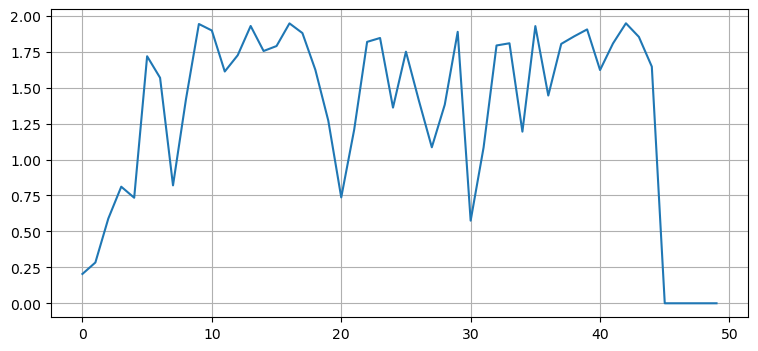

In [49]:
R, Q = .05, 0.02
xs, zs = simulate_acc_system(R=R, Q=Q, count=50)
zs[-5:-1] = [100, 200, 200, 200] # bad measurements, bad!

kf = SecondOrderKF(R, Q, dt=1, P=1)
s = Saver(kf)
kf.batch_filter(zs, saver=s)
plt.plot(s.likelihood);

The likelihood gets larger as the filter converges during the first few iterations. After that the likelihood bounces around until it reaches the bad measurements, at which time it goes to zero, indicating that if the measurements are valid the filter is very unlikely to be optimal.

在前几次迭代中，随着滤波器收敛，似然会变大。之后似然会上下波动，直到遇到错误测量，此时它变为零，说明如果这些测量值有效，那么滤波器达到最优的可能性非常低。

See how starkly the log-likelihood illustrates where the filter goes 'bad'.

看看对数似然如何鲜明地显示滤波器从哪里开始“变坏”。


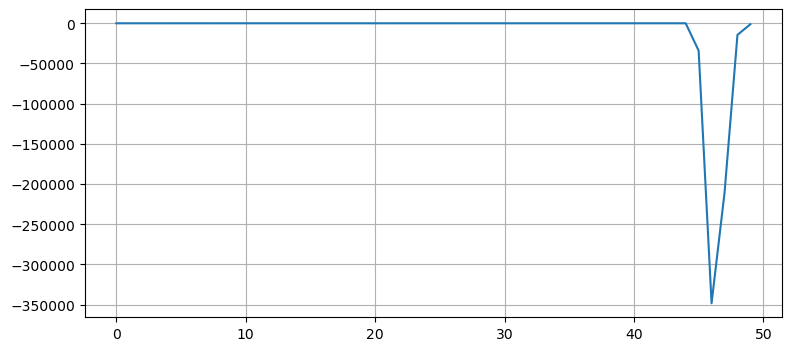

In [50]:
plt.plot(s.log_likelihood);

Why does it return to zero at the end? Think about that before reading the answer. The filter begins to adapt to the new measurements by moving the state close to the measurements. The residuals become small, and so the state and residuals agree.

为什么最后会回到零？先想一想，再阅读答案。滤波器通过将状态移近测量值，开始适应新的测量值。残差变小，因此状态与残差相符。


## Control Inputs
## 控制输入

In the **Discrete Bayes** chapter I introduced the notion of using control signals to improve the filter's performance. Instead of assuming that the object continues to move as it has so far we use our knowledge of the control inputs to predict where the object is. In the **Univariate Kalman Filter** chapter we made use of the same idea. The predict method of the Kalman filter read

在**离散贝叶斯**一章中，我介绍了使用控制信号来提高滤波器性能的概念。我们不再假设对象继续按照目前的方式运动，而是利用对控制输入的了解来预测对象的位置。在**单变量卡尔曼滤波器**一章中，我们也使用了相同的思路。卡尔曼滤波器的 predict 方法如下：

```python
def predict(pos, movement):
    return (pos[0] + movement[0], pos[1] + movement[1])
```

In the last chapter we learned that the equation for the state prediction is:

在上一章中，我们了解到状态预测方程为：

$$\bar{\mathbf x} = \mathbf{Fx} + \mathbf{Bu}$$

Our state is a vector, so we need to represent the control input as a vector. Here $\mathbf{u}$ is the control input, and $\mathbf{B}$ is a matrix that transforms the control input into a change in $\mathbf x$. Let's consider a simple example. Suppose the state is $x = \begin{bmatrix} x & \dot x\end{bmatrix}$ for a robot we are controlling and the control input is commanded velocity. This gives us a control input of

我们的状态是一个向量，因此需要将控制输入表示成向量。这里 $\mathbf{u}$ 是控制输入，$\mathbf{B}$ 是将控制输入转换为 $\mathbf x$ 变化量的矩阵。来看一个简单例子。假设我们控制的机器人状态为 $x = \begin{bmatrix} x & \dot x\end{bmatrix}$，控制输入是指令速度。那么控制输入为

$$\mathbf{u} = \begin{bmatrix}\dot x_\mathtt{cmd}\end{bmatrix}$$

For simplicity we will assume that the robot can respond instantly to changes to this input. That means that the new position and velocity after $\Delta t$ seconds will be

为简单起见，我们假设机器人能够立即响应输入变化。这意味着经过 $\Delta t$ 秒后的新位置和速度为

$$\begin{aligned}x &= x + \dot x_\mathtt{cmd} \Delta t \\
\dot x &= \dot x_\mathtt{cmd}\end{aligned}$$

We need to represent this set of equations in the form $\bar{\mathbf x} = \mathbf{Fx} + \mathbf{Bu}$.

我们需要将这组方程表示成 $\bar{\mathbf x} = \mathbf{Fx} + \mathbf{Bu}$ 的形式。

I will use the $\mathbf{Fx}$ term to extract the $x$ for the top equation, and the $\mathbf{Bu}$ term for the rest, like so:

我将使用 $\mathbf{Fx}$ 项提取顶部方程中的 $x$，其余部分使用 $\mathbf{Bu}$ 项，如下所示：

$$\begin{bmatrix}x\\\dot x\end{bmatrix} = \begin{bmatrix}1 & 0\\0 & 0 \end{bmatrix}\begin{bmatrix}x\\\dot x\end{bmatrix} +
\begin{bmatrix}\Delta t \\ 1\end{bmatrix}\begin{bmatrix}\dot x_\mathtt{cmd}\end{bmatrix}
$$

This is a simplification; typical control inputs are changes to steering angle and changes in acceleration. This introduces nonlinearities which we will learn to deal with in a later chapter.

这是一个简化。典型的控制输入包括转向角变化和加速度变化，这会引入非线性，我们将在后面的章节中学习如何处理。

The rest of the Kalman filter will be designed as normal. You've seen this several times by now, so without further comment here is an example.

卡尔曼滤波器的其余部分照常设计。到现在为止你已经多次见过这一过程，所以不再赘述，下面给出一个例子。


[[10.  0.]
 [ 0. 10.]]


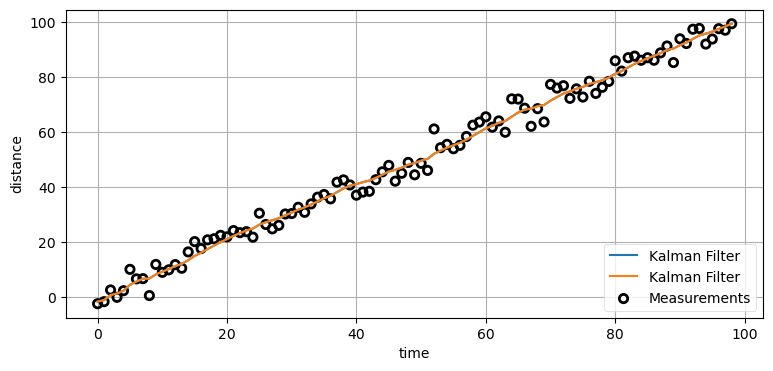

In [51]:
dt = 1.
R = 3.
kf = KalmanFilter(dim_x=2, dim_z=1, dim_u = 1)
kf.P *= 10
kf.R *= R
kf.Q = Q_discrete_white_noise(2, dt, 0.1)
kf.F = np.array([[1., 0], [0., 0.]])
kf.B = np.array([[dt], [ 1.]])
kf.H = np.array([[1., 0]])
print(kf.P)

zs = [i + randn()*R for i in range(1, 100)]
xs = []
cmd_velocity = np.array([1.])
for z in zs:
    kf.predict(u=cmd_velocity)
    kf.update(z)
    xs.append(kf.x[0])

plt.plot(xs, label='Kalman Filter')
plot_measurements(zs)
plt.xlabel('time')
plt.legend(loc=4)
plt.ylabel('distance');

## Sensor Fusion
## 传感器融合

Early in the g-h filter chapter we discussed designing a filter for two scales, one accurate and one inaccurate. We determined that we should always include the information from the inaccurate filter, we should never discard any information. So consider a situation where we have two sensors measuring the system. How shall we incorporate that into our Kalman filter?

在 g-h 滤波器一章的前面，我们讨论过为两种尺度设计滤波器，一种准确，一种不准确。我们确定应该始终包含不准确滤波器提供的信息，绝不能丢弃任何信息。那么，假设有两个传感器测量系统，应该如何将它们纳入卡尔曼滤波器？

Suppose we have a train or cart on a railway. It has a sensor attached to the wheels counting revolutions, which can be converted to a distance along the track. Then, suppose we have a GPS-like sensor which I'll call a 'position sensor' mounted to the train which reports position. I'll explain why I don't just use a GPS in the next section. Thus, we have two measurements, both reporting position along the track. Suppose further that the accuracy of the wheel sensor is 1m, and the accuracy of the position sensor is 10m. How do we combine these two measurements into one filter? This may seem quite contrived, but aircraft use sensor fusion to fuse the measurements from sensors such as a GPS, INS, Doppler radar, VOR, the airspeed indicator, and more.

假设铁路上有一列火车或一辆小车，车轮上装有一个计算转数的传感器，可以将转数转换为沿轨道的距离。再假设火车上安装了一个类似 GPS 的传感器，我称之为“位置传感器”，用于报告位置。下一节会解释为什么不直接使用 GPS。因此，我们有两个测量值，它们都报告沿轨道的位置。进一步假设车轮传感器的精度为 1 米，位置传感器的精度为 10 米。如何把这两个测量值组合到一个滤波器中？这看起来可能有些刻意，但飞机会融合 GPS、INS、多普勒雷达、VOR、空速指示器等传感器的测量值。

Kalman filters for inertial systems are very difficult, but fusing data from two or more sensors providing measurements of the same state variable (such as position) is quite easy. The relevant matrix is the measurement matrix $\mathbf H$. Recall that this matrix tells us how to convert from the Kalman filter's state $\mathbf x$ to a measurement $\mathbf z$. Suppose that we decide that our Kalman filter state should contain the position and velocity of the train, so that

惯性系统的卡尔曼滤波器非常复杂，但融合两个或更多传感器的数据却很容易，只要这些传感器测量的是同一个状态变量（例如位置）。相关矩阵是测量矩阵 $\mathbf H$。回想一下，这个矩阵告诉我们如何将卡尔曼滤波器的状态 $\mathbf x$ 转换为测量值 $\mathbf z$。假设我们决定卡尔曼滤波器状态包含火车的位置和速度，即

$$ \mathbf x = \begin{bmatrix}x \\ \dot x\end{bmatrix}$$

We have two measurements for position, so we will define the measurement vector to be a vector of the measurements from the wheel and the position sensor.

我们有两个位置测量值，因此将测量向量定义为车轮传感器和位置传感器测量值组成的向量。

$$ \mathbf z = \begin{bmatrix}z_{wheel} \\ z_{ps}\end{bmatrix}$$

So we have to design the matrix $\mathbf H$ to convert $\mathbf x$ to $\mathbf z$ . They are both positions, so the conversion is nothing more than multiplying by one:

所以需要设计矩阵 $\mathbf H$，将 $\mathbf x$ 转换为 $\mathbf z$。二者都是位置，因此转换只需乘以 1：

$$ \begin{bmatrix}z_{wheel} \\ z_{ps}\end{bmatrix} = \begin{bmatrix}1 &0 \\ 1& 0\end{bmatrix} \begin{bmatrix}x \\ \dot x\end{bmatrix}$$

To make it clearer, suppose that the wheel reports not position but the number of rotations of the wheels, where 1 revolution yields 2 meters of travel. In that case we would write

为了说明得更清楚，假设车轮报告的不是位置，而是车轮转数，并且每转一圈前进 2 米。这时可以写成

$$ \begin{bmatrix}z_{rot} \\ z_{ps}\end{bmatrix} = \begin{bmatrix}0.5 &0 \\ 1& 0\end{bmatrix} \begin{bmatrix}x \\ \dot x\end{bmatrix}$$

Now we have to design the measurement noise matrix $\mathbf R$. Suppose that the measurement variance for the position is twice the variance of the wheel, and the standard deviation of the wheel is 1.5 meters. That gives us

现在需要设计测量噪声矩阵 $\mathbf R$。假设位置测量的方差是车轮测量方差的两倍，且车轮测量的标准差为 1.5 米。那么

$$
\begin{aligned}
\sigma_{wheel} &=  1.5\\
\sigma^2_{wheel} &= 2.25 \\ 
\sigma_{ps} &= 1.5*2 = 3 \\
\sigma^2_{ps} &= 9.
\end{aligned}
$$

That is pretty much our Kalman filter design. We need to design for $\mathbf Q$, but that is invariant to whether we are doing sensor fusion or not, so I will just choose some arbitrary value.

这基本就是卡尔曼滤波器的设计了。还需要设计 $\mathbf Q$，但它与是否进行传感器融合无关，因此我就选择一个任意值。

So let's run a simulation of this design. I will assume a velocity of 10 m/s with an update rate of 0.1 seconds.

下面运行这个设计的模拟。我假设速度为 10 m/s，更新率为 0.1 秒。


fusion std: 1.647


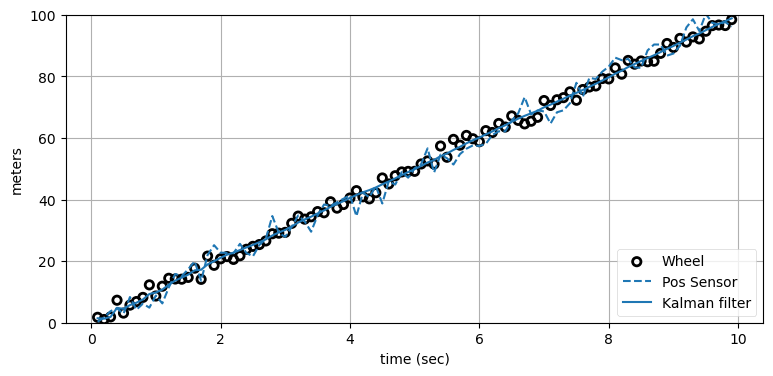

In [52]:
from numpy import array, asarray
import numpy.random as random

def fusion_test(wheel_sigma, ps_sigma, do_plot=True):
    dt = 0.1
    kf = KalmanFilter(dim_x=2, dim_z=2)

    kf.F = array([[1., dt], [0., 1.]])
    kf.H = array([[1., 0.], [1., 0.]])
    kf.x = array([[0.], [1.]])
    kf.Q *= array([[(dt**3)/3, (dt**2)/2],
                   [(dt**2)/2,  dt      ]]) * 0.02
    kf.P *= 100
    kf.R[0, 0] = wheel_sigma**2
    kf.R[1, 1] = ps_sigma**2 
    s = Saver(kf)

    random.seed(1123)
    for i in range(1, 100):
        m0 = i + randn()*wheel_sigma
        m1 = i + randn()*ps_sigma
        kf.predict()
        kf.update(array([[m0], [m1]]))
        s.save()
    s.to_array()
    print(f'fusion std: {np.std(s.y[:, 0]):.3f}')
    if do_plot:
        ts = np.arange(0.1, 10, .1)
        plot_measurements(ts, s.z[:, 0], label='Wheel')
        plt.plot(ts, s.z[:, 1], ls='--', label='Pos Sensor')
        plot_filter(ts, s.x[:, 0], label='Kalman filter')
        plt.legend(loc=4)
        plt.ylim(0, 100)
        set_labels(x='time (sec)', y='meters')

fusion_test(1.5, 3.0)

We can see the result of the Kalman filter in blue.

我们可以看到蓝色的卡尔曼滤波器结果。

It may be somewhat difficult to understand the previous example at an intuitive level. Let's look at a different problem. Suppose we are tracking an object in 2D space, and have two radar systems at different positions. Each radar system gives us a range and bearing to the target. How do the readings from each data affect the results?

从直观层面理解前面的例子可能有些困难。让我们看看另一个问题。假设我们在二维空间中跟踪一个对象，并且在不同位置有两个雷达系统。每个雷达系统都会提供目标的距离和方位。每个雷达的读数会怎样影响结果？

This is a nonlinear problem because we need to use trigonometry to compute coordinates from a range and bearing, and we have not yet learned how to solve nonlinear problems with Kalman filters. So for this problem ignore the code that I use and just concentrate on the charts that the code outputs. We will revisit this problem in subsequent chapters and learn how to write this code.

这是一个非线性问题，因为需要使用三角函数根据距离和方位计算坐标，而我们还没有学习如何用卡尔曼滤波器解决非线性问题。因此，对于这个问题，请忽略我使用的代码，只关注代码输出的图表。我们将在后续章节中重新讨论这个问题，并学习如何编写这段代码。

I will position the target at (100, 100). The first radar will be at (50, 50), and the second radar at (150, 50). This will cause the first radar to measure a bearing of 45 degrees, and the second will report 135 degrees.

我将目标放在 (100, 100)。第一个雷达位于 (50, 50)，第二个雷达位于 (150, 50)。这样第一个雷达测得的方位角将为 45 度，第二个将报告 135 度。

I will create the Kalman filter first, and then plot its initial covariance matrix. I am using an **unscented Kalman filter**, which is covered in a later chapter.

我会先创建卡尔曼滤波器，然后绘制其初始协方差矩阵。我使用的是**无迹卡尔曼滤波器**，后面的章节会介绍它。


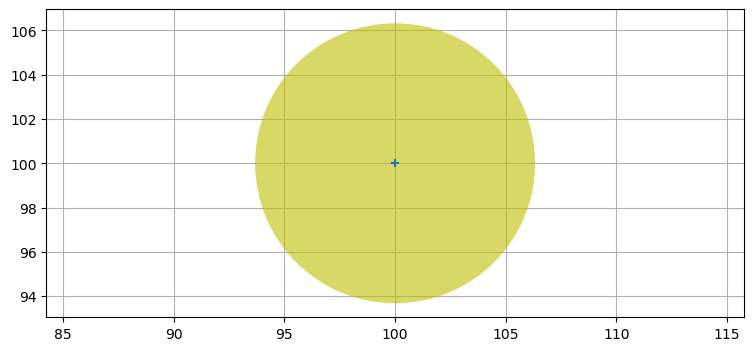

In [53]:
from kf_book.kf_design_internal import sensor_fusion_kf

kf = sensor_fusion_kf()
x0, p0 = kf.x.copy(), kf.P.copy()
plot_covariance_ellipse(x0, p0, fc='y', ec=None, alpha=0.6)

We are equally uncertain about the position in x and y, so the covariance is circular.

我们对 x 和 y 方向的位置同样不确定，因此协方差是圆形的。

Now we will update the Kalman filter with a reading from the first radar. I will set the standard deviation of the bearing error at 0.5$^\circ$, and the standard deviation of the distance error at 3.

现在我们将使用第一个雷达的读数更新卡尔曼滤波器。我将方位角误差的标准差设为 0.5$^\circ$，距离误差的标准差设为 3。


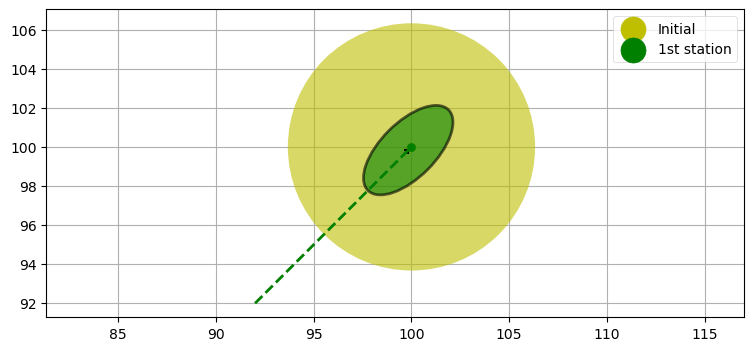

In [54]:
from math import radians
from kf_book.kf_design_internal import sensor_fusion_kf, set_radar_pos

# set the error of the radar's bearing and distance
kf.R[0, 0] = radians (.5)**2
kf.R[1, 1] = 3.**2

# compute position and covariance from first radar station
set_radar_pos((50, 50))
dist = (50**2 + 50**2) ** 0.5
kf.predict()
kf.update([radians(45), dist])

# plot the results
x1, p1 = kf.x.copy(), kf.P.copy()

plot_covariance_ellipse(x0, p0, fc='y', ec=None, alpha=0.6)
plot_covariance_ellipse(x1, p1, fc='g', ec='k', alpha=0.6)

plt.scatter([100], [100], c='y', label='Initial')
plt.scatter([100], [100], c='g', label='1st station')
plt.legend(scatterpoints=1, markerscale=3)
plt.plot([92, 100], [92, 100], c='g', lw=2, ls='--');

We can see the effect of the errors on the geometry of the problem. The radar station is to the lower left of the target. The bearing measurement is extremely accurate at $\sigma=0.5^\circ$, but the distance error is inaccurate at $\sigma=3$. I've shown the radar reading with the dotted green line. We can easily see the effect of the accurate bearing and inaccurate distance in the shape of the covariance ellipse.

我们可以看到误差对问题几何形状的影响。雷达站位于目标的左下方。方位角测量在 $\sigma=0.5^\circ$ 时非常准确，但距离误差在 $\sigma=3$ 时并不准确。我用绿色虚线表示了雷达读数。我们可以很清楚地从协方差椭圆的形状中看到，准确的方位角和不准确的距离分别产生了什么影响。

Now we can incorporate the second radar station's measurement. The second radar is at (150,50), which is below and to the right of the target. Before you go on, think about how you think the covariance will change when we incorporate this new reading.

现在可以纳入第二个雷达站的测量值。第二个雷达位于 (150,50)，在目标的右下方。继续之前，想一想加入这个新读数后，协方差会如何变化。


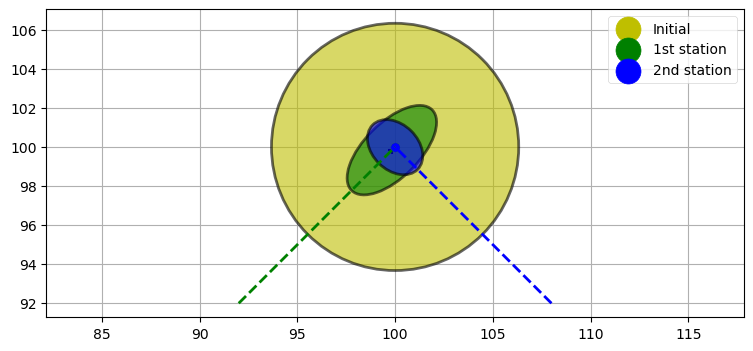

In [55]:
# compute position and covariance from second radar station
set_radar_pos((150, 50))
kf.predict()
kf.update([radians(135), dist])

plot_covariance_ellipse(x0, p0, fc='y', ec='k', alpha=0.6)
plot_covariance_ellipse(x1, p1, fc='g', ec='k', alpha=0.6)
plot_covariance_ellipse(kf.x, kf.P, fc='b', ec='k', alpha=0.6)

plt.scatter([100], [100], c='y', label='Initial')
plt.scatter([100], [100], c='g', label='1st station')
plt.scatter([100], [100], c='b', label='2nd station')
plt.legend(scatterpoints=1, markerscale=3)
plt.plot([92, 100], [92, 100], c='g', lw=2, ls='--')
plt.plot([108, 100], [92, 100], c='b', lw=2, ls='--');

We can see how the second radar measurement altered the covariance. The angle to the target is orthogonal to the first radar station, so the effects of the error in the bearing and range are swapped. So the angle of the covariance matrix switches to match the direction to the second station. It is important to note that the direction did not merely change; the size of the covariance matrix became much smaller as well.

我们可以看到第二次雷达测量是如何改变协方差的。与目标的角度与第一个雷达站正交，因此方位和范围误差的影响被交换。所以协方差矩阵的角度切换到与第二站的方向匹配。需要注意的是，方向不仅发生了变化，而且还发生了变化。协方差矩阵的大小也变得更小。

The covariance will always incorporate all of the information available, including the effects of the geometry of the problem. This formulation makes it particularly easy to see what is happening, but the same thing occurs if one sensor gives you position and a second sensor gives you velocity, or if two sensors provide measurements of position.

协方差将始终包含所有可用信息，包括问题几何的影响。这种公式可以特别容易地查看正在发生的事情，但是如果一个传感器为你提供位置，而第二个传感器为你提供速度，或者如果两个传感器提供位置测量，则会发生同样的事情。

One final thing before we move on: sensor fusion is a vast topic, and my coverage is simplistic to the point of being misleading. For example, GPS uses iterated least squares to determine the position from a set of pseudorange readings from the satellites without using a Kalman filter. I cover this topic in the supporting notebook [**Iterative Least Squares for Sensor Fusion**](http://nbviewer.ipython.org/urls/raw.github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python/master/Supporting_Notebooks/Iterative-Least-Squares-for-Sensor-Fusion.ipynb)

在我们继续之前的最后一件事：传感器融合是一个庞大的话题，我的报道过于简单化到了误导的地步。例如，GPS 使用迭代最小二乘法从一组来自卫星的伪距读数中确定位置，而不使用卡尔曼滤波器。我在支持笔记本 [**Iterative Least Squares for Sensor Fusion**](http://nbviewer.ipython.org/urls/raw.github.com/rlabbe/Kalman-and-Bayesian-Filters-in -Python/master/Supporting_Notebooks/Iterative-Least-Squares-for-Sensor-Fusion.ipynb)

That is the usual but not exclusive way this computation is done in GPS receivers. If you are a hobbyist my coverage may get you started. A commercial grade filter requires very careful design of the fusion process. That is the topic of several books, and you will have to further your education by finding one that covers your domain.

这是在 GPS 接收器中完成此计算的常用方式，但并非唯一方式。如果你是业余爱好者，我的报道可能会让你入门。商业级滤波器需要非常仔细地设计融合过程。这是几本书的主题，你必须通过找到涵盖你的领域的一本来进一步学习。


### Exercise: Can you Filter GPS outputs?

### 练习：你能对 GPS 输出滤波吗？

In the section above I have you apply a Kalman filter to a 'GPS-like' sensor. Can you apply a Kalman filter to the output of a commercial Kalman filter? In other words, will the output of your filter be better than, worse than, or equal to the GPS's output?

在上面的部分中，我让你将卡尔曼滤波器应用于“类似 GPS”的传感器。你可以将卡尔曼滤波器应用于商业卡尔曼滤波器的输出吗？换句话说，你的滤波器的输出会比 GPS 的输出好、差还是等于 GPS 的输出？


#### Solution

#### 解答

Commercial GPS's have a Kalman filter built into them, and their output is the filtered estimate created by that filter. So, suppose you have a steady stream of output from the GPS consisting of a position and position error. Can you not pass those two pieces of data into your own filter?

商业 GPS 内置了卡尔曼滤波器，它们的输出是由该滤波器创建的滤波估计值。因此，假设你有来自 GPS 的稳定输出流，其中包含位置和位置误差。你不能将这两条数据传递到你自己的滤波器中吗？

Well, what are the characteristics of that data stream, and more importantly, what are the fundamental requirements of the input to the Kalman filter?

那么，该数据流的特征是什么，更重要的是，卡尔曼滤波器的输入的基本要求是什么？

Inputs to the Kalman filter must be *Gaussian* and *time independent*. This is because we imposed the requirement of the Markov property: the current state is dependent only on the previous state and current inputs. This makes the recursive form of the filter possible. The output of the GPS is *time dependent* because the filter bases its current estimate on the recursive estimates of all previous measurements. Hence, the signal is not white, it is not time independent, and if you pass that data into a Kalman filter you have violated the mathematical requirements of the filter. So, the answer is no, you cannot get better estimates by running a KF on the output of a commercial GPS. 

卡尔曼滤波器的输入必须是*高斯*和*时间无关*。这是因为我们强加了马尔可夫属性的要求：当前状态仅依赖于先前状态和当前输入。这使得滤波器的递归形式成为可能。GPS 的输出是*时间相关的*，因为滤波器的当前估计基于所有先前测量的递归估计。因此，信号不是白色的，它不是时间独立的，如果你将该数据传递到卡尔曼滤波器中，你就违反了滤波器的数学要求。因此，答案是否定的，你无法通过在商业 GPS 的输出上运行 KF 来获得更好的估计。

Another way to think of it is that Kalman filters are optimal in a least squares sense. There is no way to take an optimal solution, pass it through a filter, any filter, and get a 'more optimal' answer because it is a logical impossibility. At best the signal will be unchanged, in which case it will still be optimal, or it will be changed, and hence no longer optimal.

另一种思考方式是卡尔曼滤波器在最小二乘意义上是最优的。没有办法采取最佳解决方案，将其通滤波波器，任何滤波器，并获得“更优化”的答案，因为这在逻辑上是不可能的。充其量信号将保持不变，在这种情况下它仍然是最佳的，或者它会改变，因此不再是最佳的。

This is a difficult problem that hobbyists face when trying to integrate GPS, IMU's and other off the shelf sensors. 

这是爱好者在尝试集成 GPS、IMU 和其他现成传感器时面临的难题。

Let's look at the effect. A commercial GPS reports position, and an estimated error range. The estimated error just comes from the Kalman filter's $\mathbf P$ matrix. So let's filter some noisy data, take the filtered output as the new noisy input to the filter, and see what the result is. In other words, $\mathbf x$ will supply the  $\mathbf z$ input, and  $\mathbf P$ will supply the measurement covariance $\mathbf R$. To exaggerate the effects somewhat to make them more obvious I will plot the effects of doing this one, and then a second time. The second iteration doesn't make any 'sense' (no one would try that), it just helps me illustrate a point. First, the code and plots.

我们来看看效果。商业 GPS 报告位置和估计的误差范围。估计误差仅来自卡尔曼滤波器的 $\mathbf P$ 矩阵。那么让我们滤波一些噪声数据，将滤波后的输出作为新的噪声输入到滤波器，看看结果如何。换句话说，$\mathbf x$ 将提供 $\mathbf z$ 输入，$\mathbf P$ 将提供测量协方差 $\mathbf R$。为了稍微夸大效果以使它们更明显，我将绘制执行此操作的效果，然后再绘制第二次。第二次迭代没有任何“意义”（没有人会尝试），它只是帮助我说明了一个观点。首先，代码和图。


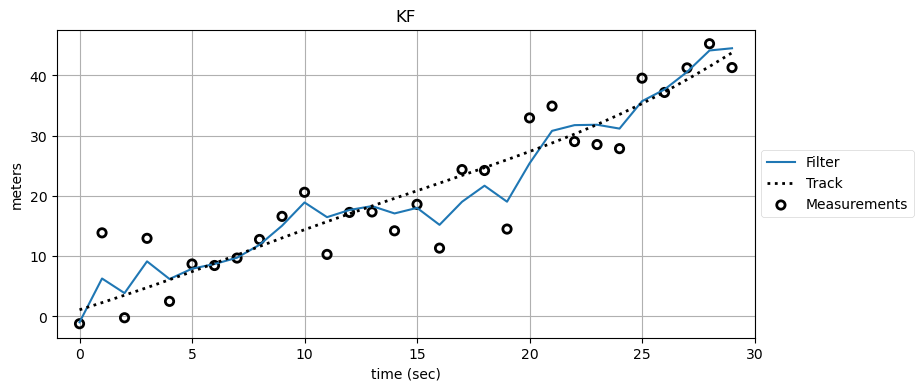

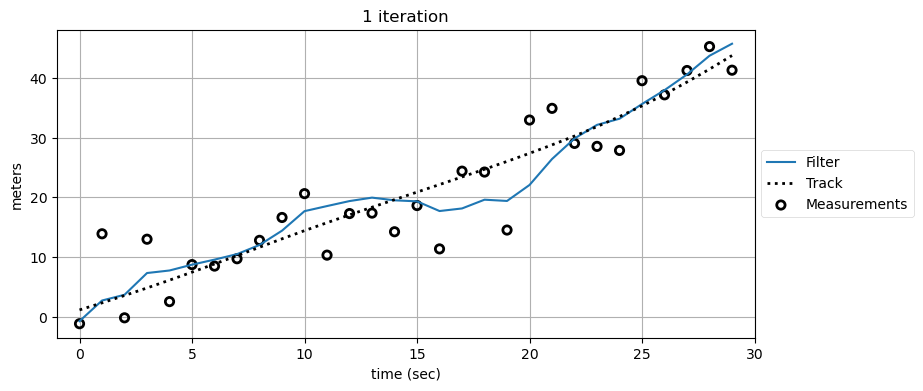

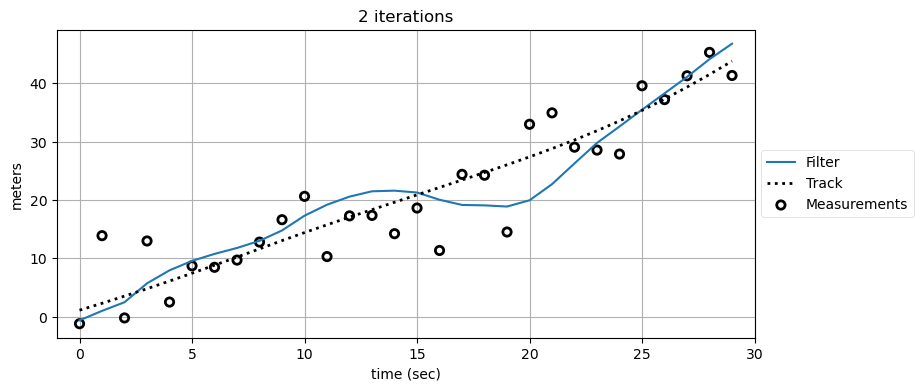

(5.0, 0.02)

In [56]:
np.random.seed(124)
R = 5.
xs, zs = simulate_acc_system(R=R, Q=Q, count=30)

kf0 = SecondOrderKF(R, Q, dt=1)
kf1 = SecondOrderKF(R, Q, dt=1)
kf2 = SecondOrderKF(R, Q, dt=1)

# Filter measurements
fxs0, ps0, _, _ = kf0.batch_filter(zs)

# filter twice more, using the state as the input
fxs1, ps1, _, _ = kf1.batch_filter(fxs0[:, 0])
fxs2, _, _, _ = kf2.batch_filter(fxs1[:, 0])

plot_kf_output(xs, fxs0, zs, 'KF', False)
plot_kf_output(xs, fxs1, zs, '1 iteration', False)
plot_kf_output(xs, fxs2, zs, '2 iterations', False)
R,Q

We see that the filtered output of the reprocessed signal is smoother, but it also diverges from the track. What is happening? Recall that the Kalman filter requires that the signal not be time correlated. However the output of the Kalman filter *is* time correlated because it incorporates all previous measurements into its estimate for this time period. So look at the last graph, for 2 iterations. The measurements start with several peaks that are larger than the track. This is 'remembered' (that is vague terminology, but I am trying to avoid the math) by the filter, and it has started to compute that the object is above the track. Later, at around 13 seconds we have a period where the measurements all happen to be below the track. This also gets incorporated into the memory of the filter, and the iterated output diverges far below the track. 

我们看到再处理信号的滤波输出更平滑，但它也偏离了轨道。怎么了？回想一下，卡尔曼滤波器要求信号不是时间相关的。然而，卡尔曼滤波器的输出 * 是 * 时间相关的，因为它将所有先前的测量值合并到它对该时间段的估计中。因此，请查看最后一张图，进行 2 次迭代。测量从几个比轨道大的峰值开始。这被滤波器“记住”（这是一个模糊的术语，但我试图避免数学），并且它已经开始计算对象在轨道上方。稍后，在大约 13 秒时，我们有一个时间段，测量值都恰好在轨道下方。这也被合并到滤波器的内存中，并且迭代输出远低于轨道。

Now let's look at this in a different way. The iterated output is *not* using $\mathbf z$ as the measurement, but the output of the previous Kalman filter estimate. So I will plot the output of the filter against the previous filter's output.

现在让我们以不同的方式来看待这个问题。迭代输出*不是*使用 $\mathbf z$ 作为测量值，而是先前卡尔曼滤波器估计的输出。因此，我将根据前一个滤波器的输出绘制滤波器的输出。


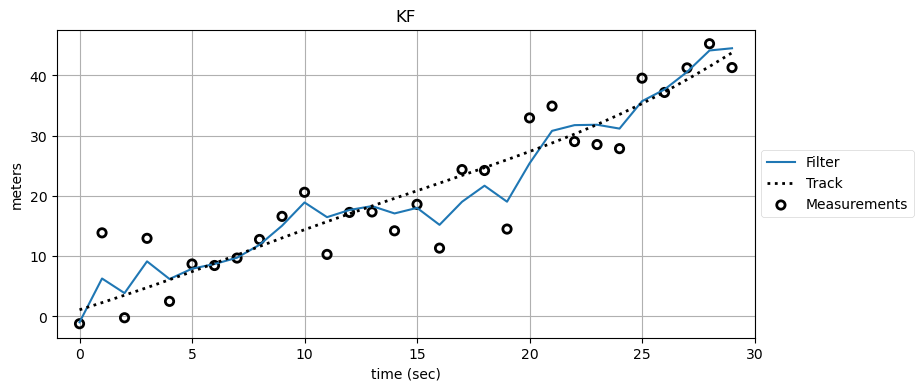

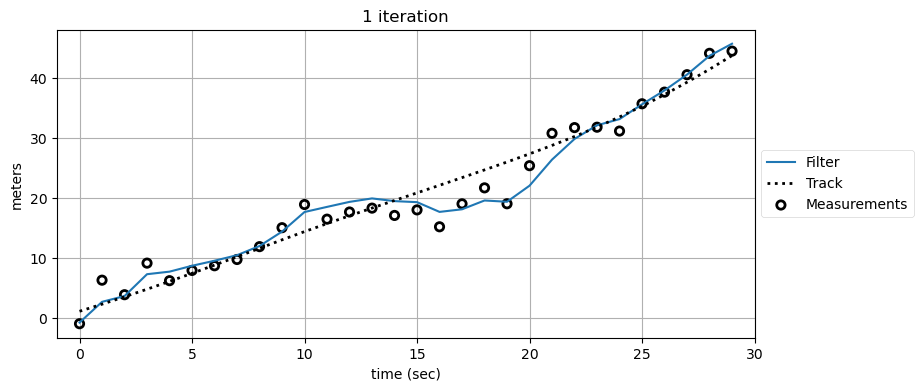

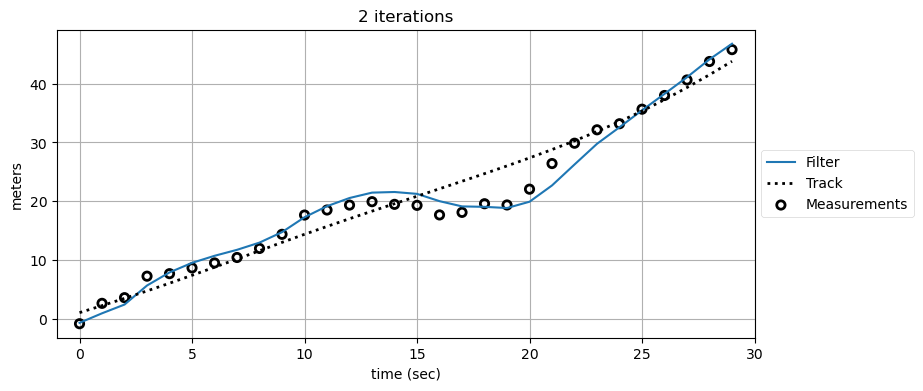

In [57]:
plot_kf_output(xs, fxs0, zs, title='KF', aspect_equal=False)
plot_kf_output(xs, fxs1, fxs0[:, 0], '1 iteration', False)
plot_kf_output(xs, fxs2, fxs1[:, 0], '2 iterations', False)

I hope the problem with this approach is now apparent. In the bottom graph we can see that the KF is tracking the imperfect estimates of the previous filter, and incorporating delay into the signal as well due to the memory of the previous measurements being incorporated into the signal.

我希望这种方法的问题现在很明显。在底部图表中，我们可以看到 KF 正在跟踪先前滤波器的不完美估计，并且由于先前测量值的记忆被合并到信号中，因此还将延迟合并到信号中。


### Exercise: Prove that the position sensor improves the filter

### 练习：证明位置传感器能改进滤波器

Devise a way to prove that fusing the position sensor and wheel measurements yields a better result than using the wheel alone.

设计一种方法来证明融合位置传感器和车轮测量结果比单独使用车轮产生更好的结果。

#### 解答 1

通过将位置传感器的测量噪声设置为接近无限的值，强制卡尔曼滤波器忽略位置传感器测量。重新运行滤波器并观察残差的标准偏差


In [58]:
fusion_test(1.5, 3.0, do_plot=False)
fusion_test(1.5, 1.e40, do_plot=False)

fusion std: 1.647
fusion std: 1.647


#### Solution 1

#### 解答 2

Force the Kalman filter to disregard the position sensor measurement by setting the measurement noise for the position sensor to a near infinite value. Re-run the filter and observe the standard deviation of the residual.

这是更多的工作，但我们可以编写一个只进行一次测量的卡尔曼滤波器。


Here we can see the error in the filter where the position sensor measurement is almost entirely ignored is greater than that where it is used.

从中我们可以看出，几乎完全忽略位置传感器测量的那个滤波器，其误差要大于使用该测量的滤波器。


std: 0.523


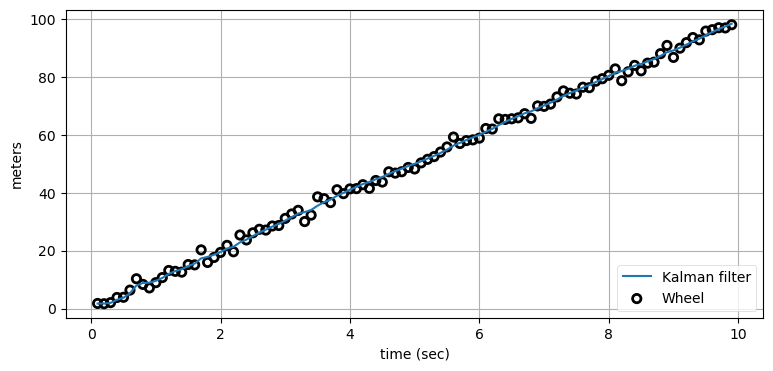

In [59]:
dt = 0.1
wheel_sigma = 1.5
kf = KalmanFilter(dim_x=2, dim_z=1)
kf.F = array([[1., dt], [0., 1.]])
kf.H = array([[1., 0.]])
kf.x = array([[0.], [1.]])
kf.Q *= 0.01
kf.P *= 100
kf.R[0, 0] = wheel_sigma**2

random.seed(1123)
nom = range(1, 100)
zs = np.array([i + randn()*wheel_sigma for i in nom])
xs, _, _, _ = kf.batch_filter(zs)
ts = np.arange(0.1, 10, .1)

res = nom - xs[:, 0, 0]
print(f'std: {np.std(res):.3f}')

plot_filter(ts, xs[:, 0], label='Kalman filter')
plot_measurements(ts, zs, label='Wheel')
set_labels(x='time (sec)', y='meters')
plt.legend(loc=4);

在这次运行中，我得到了 0.523 的标准偏差，而融合测量的值为 0.391。

#### Solution 2

This is more work, but we can write a Kalman filter that only takes one measurement.


On this run I got a standard deviation of 0.523 vs the value of 0.391 for the fused measurements.

在这次运行中，我得到的标准偏差为 0.523，而融合测量值为 0.391。

## Nonstationary Processes

## 非平稳过程

So far we have assumed that the various matrices in the Kalman filter are *stationary* - nonchanging over time. For example, in the robot tracking section we assumed that $\Delta t = 1.0$ seconds, and designed the state transition matrix to be

到目前为止，我们假设卡尔曼滤波器中的各种矩阵是*平稳的* - 随着时间的推移不变。例如，在机器人跟踪部分，我们假设 $\Delta t = 1.0$ 秒，并将状态转移矩阵设计为

$$
\mathbf F = \begin{bmatrix}1& \Delta t& 0& 0\\0& 1& 0& 0\\0& 0& 1& \Delta t\\ 0& 0& 0& 1\end{bmatrix} = \begin{bmatrix}1& 1& 0& 0\\0& 1& 0& 0\\0& 0& 1& 1\\ 0& 0& 0& 1\end{bmatrix}$$

But what if our data rate changes in some unpredictable manner? Or what if we have two sensors, each running at a different rate? What if the error of the measurement changes? 

但是，如果我们的数据速率以某种不可预测的方式发生变化怎么办？或者，如果我们有两个传感器，每个传感器都以不同的速率运行呢？如果测量误差发生变化怎么办？

Handling this is easy; you just alter the Kalman filter matrices to reflect the current situation. Let's go back to our dog tracking problem and assume that the data input is somewhat sporadic. For this problem we designed

处理这个很容易；你只需更改卡尔曼滤波器矩阵以反映当前情况。让我们回到我们的狗跟踪问题并假设数据输入是零星的。针对这个问题我们设计了

$$\begin{aligned}
\mathbf{\bar x} &= {\begin{bmatrix}x\\\dot x\end{bmatrix}}^- \\
\mathbf F &= \begin{bmatrix}1&\Delta t  \\ 0&1\end{bmatrix} 
\end{aligned}$$

and set the Kalman filter variable `F` during initialization like so:

并在初始化期间设置卡尔曼滤波器变量“F”，如下所示：

```python
dt = 0.1
kf.F = np.array([[1, dt],
                 [0, 1]])
```

How would we handle $\Delta t$ changing for each measurement? It's easy - just modify the relevant matrices. In this case `F` is variant, so we will need to update this inside the update/predict loop.  `Q` is also dependent on time, so it must be assigned during each loop as well. Here is an example of how we might code this:

我们将如何处理每次测量的 $\Delta t$ 变化？这很容易 - 只需修改相关矩阵。在这种情况下，`F` 是变体，所以我们需要在更新/预测循环中更新它。`Q` 也取决于时间，因此也必须在每个循环期间分配。这是我们如何编码的示例：


In [60]:
kf = KalmanFilter(dim_x=2, dim_z=1)
kf.x = array([0., 1.])
kf.H = array([[1, 0]])
kf.P = np.eye(2) * 50
kf.R = np.eye(1)
q_var = 0.02

# measurement tuple: (value, time)
zs = [(1., 1.),  (2., 1.1), (3., 0.9), (4.1, 1.23), (5.01, 0.97)]
for z, dt in zs:
    kf.F = array([[1, dt],
                  [0, 1]])
    kf.Q = Q_discrete_white_noise(dim=2, dt=dt, var=q_var)
    kf.predict()
    kf.update(z)
    print(kf.x)

[1. 1.]
[2.   0.92]
[2.96 1.  ]
[4.12 0.97]
[5.03 0.96]


### Sensor fusion: Different Data Rates

### 传感器融合：不同的数据速率

It is rare that two different sensor classes output data at the same rate. Assume that the position sensor produces an update at 3 Hz, and the wheel updates at 7 Hz. Further assume that the timing is not precise - there is a bit of jitter such that a measurement can occur a bit before or after the predicted time. Let me further complicate the situation by having the wheel provide velocity estimates rather than position estimates.

两个不同的传感器类别以相同的速率输出数据的情况很少见。假设位置传感器以 3 Hz 的频率产生更新，而车轮以 7 Hz 的频率更新。进一步假设时间不精确 - 存在一点抖动，因此测量可能会在预测时间之前或之后发生。让我通过让轮子提供速度估计而不是位置估计来使情况进一步复杂化。

We can do this by waiting for a data packet from either sensor. When we get it, we determine the amount of time that has passed since the last update. We then need to modify the affected matrices. Both $\mathbf F$ and $\mathbf Q$ contain a time term $\Delta t$ so we will need to adjust these on every innovation. 

我们可以通过等待来自任一传感器的数据包来做到这一点。当我们得到它时，我们会确定自上次更新以来经过的时间量。然后我们需要修改受影响的矩阵。$\mathbf F$ 和 $\mathbf Q$ 都包含一个时间项 $\Delta t$，因此我们需要在每次创新时调整它们。

The measurement changes each time, so we will have to modify $\mathbf H$ and $\mathbf R$. The position sensor alters the position element of $\mathbf x$, so we assign:

每次测量都会改变，所以我们必须修改 $\mathbf H$ 和 $\mathbf R$。位置传感器改变 $\mathbf x$ 的位置元素，因此我们指定：

$$\begin{aligned}
\mathbf H &= \begin{bmatrix}1 &0\end{bmatrix} \\
\mathbf R &= \sigma_{ps}^2
\end{aligned}$$

The wheel sensor alters the velocity element of $\mathbf x$, so we assign:

车轮传感器改变了 $\mathbf x$ 的速度元素，因此我们指定：

$$\begin{aligned}
\mathbf H &= \begin{bmatrix}0 &1\end{bmatrix} \\
\mathbf R &= \sigma_{wheel}^2
\end{aligned}$$


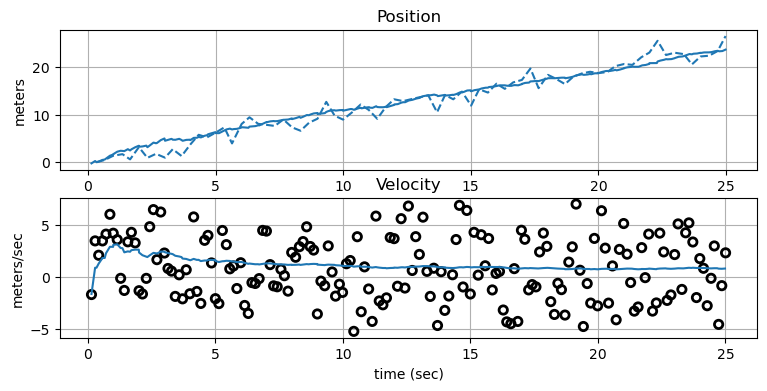

In [61]:
def gen_sensor_data(t, ps_std, wheel_std):
    # generate simulated sensor data
    pos_data, vel_data = [], []
    dt = 0.
    for i in range(t*3):
        dt += 1/3.
        t_i = dt + randn() * .01 # time jitter
        pos_data.append([t_i, t_i + randn()*ps_std])

    dt = 0.    
    for i in range(t*7):
        dt += 1/7.
        t_i = dt + randn() * .006 # time jitter
        vel_data.append([t_i, 1. + randn()*wheel_std])
    return pos_data, vel_data


def plot_fusion(xs, ts, zs_ps, zs_wheel):
    xs = np.array(xs)
    plt.subplot(211)
    plt.plot(zs_ps[:, 0], zs_ps[:, 1], ls='--', label='Pos Sensor')
    plot_filter(xs=ts, ys=xs[:, 0], label='Kalman filter')
    set_labels(title='Position', y='meters',)

    plt.subplot(212)
    plot_measurements(zs_wheel[:, 0], zs_wheel[:, 1],  label='Wheel')
    plot_filter(xs=ts, ys=xs[:, 1], label='Kalman filter')
    set_labels('Velocity', 'time (sec)', 'meters/sec')
    

def fusion_test(pos_data, vel_data, wheel_std, ps_std):
    kf = KalmanFilter(dim_x=2, dim_z=1)
    kf.F = array([[1., 1.], [0., 1.]])
    kf.H = array([[1., 0.], [1., 0.]])
    kf.x = array([[0.], [1.]])
    kf.P *= 100

    xs, ts = [],  []
    
    # copy data for plotting
    zs_wheel = np.array(vel_data)
    zs_ps = np.array(pos_data)
                     
    last_t = 0
    while len(pos_data) > 0 and len(vel_data) > 0:
        if pos_data[0][0] < vel_data[0][0]:
            t, z = pos_data.pop(0)
            dt = t - last_t
            last_t = t
            
            kf.H = np.array([[1., 0.]])
            kf.R[0,0] = ps_std**2
        else:
            t, z = vel_data.pop(0)
            dt = t - last_t
            last_t = t
            
            kf.H = np.array([[0., 1.]])
            kf.R[0,0] = wheel_std**2

        kf.F[0,1] = dt
        kf.Q = Q_discrete_white_noise(2, dt=dt, var=.02)
        kf.predict()
        kf.update(np.array([z]))

        xs.append(kf.x.T[0])
        ts.append(t)
    plot_fusion(xs, ts, zs_ps, zs_wheel)

random.seed(1123)
pos_data, vel_data = gen_sensor_data(25, 1.5, 3.0)
fusion_test(pos_data, vel_data, 1.5, 3.0);

## Tracking a Ball

## 跟踪一个球

Now let's turn our attention to a situation where the physics of the object that we are tracking is constrained. A ball thrown in a vacuum must obey Newtonian laws. In a constant gravitational field it will travel in a parabola. I will assume you are familiar with the derivation of the formula:

现在让我们将注意力转向我们正在跟踪的对象的物理受到约束的情况。在真空中抛出的球必须遵守牛顿定律。在恒定的引力场中，它将以抛物线运动。我假设你熟悉公式的推导：

$$
\begin{aligned}
y &= \frac{g}{2}t^2 + v_{y0} t + y_0 \\
x &= v_{x0} t + x_0
\end{aligned}
$$

where $g$ is the gravitational constant, $t$ is time, $v_{x0}$ and $v_{y0}$ are the initial velocities in the x and y plane. If the ball is thrown with an initial velocity of $v$ at angle $\theta$ above the horizon, we can compute $v_{x0}$ and $v_{y0}$ as

其中 $g$ 是引力常数，$t$ 是时间，$v_{x0}$ 和 $v_{y0}$ 是 x 和 y 平面的初始速度。如果球以 $v$ 的初始速度在地平线以上的角度 $\theta$ 被抛出，我们可以计算 $v_{x0}$ 和 $v_{y0}$ 为

$$
\begin{aligned}
v_{x0} = v \cos{\theta} \\
v_{y0} = v \sin{\theta}
\end{aligned}
$$


Because we don't have real data we will start by writing a simulator for a ball. As always, we add a noise term independent of time so we can simulate noisy sensors.

因为我们没有真实的数据，我们将从编写一个球的模拟器开始。与往常一样，我们添加了一个与时间无关的噪声项，因此我们可以模拟噪声传感器。


In [62]:
from math import radians, sin, cos
import math

def rk4(y, x, dx, f):
    """computes 4th order Runge-Kutta for dy/dx.
    y is the initial value for y
    x is the initial value for x
    dx is the difference in x (e.g. the time step)
    f is a callable function (y, x) that you supply to 
      compute dy/dx for the specified values.
    """
    
    k1 = dx * f(y, x)
    k2 = dx * f(y + 0.5*k1, x + 0.5*dx)
    k3 = dx * f(y + 0.5*k2, x + 0.5*dx)
    k4 = dx * f(y + k3, x + dx)
    
    return y + (k1 + 2*k2 + 2*k3 + k4) / 6.

def fx(x,t):
    return fx.vel
    
def fy(y,t):
    return fy.vel - 9.8*t


class BallTrajectory2D(object):
    def __init__(self, x0, y0, velocity, 
                 theta_deg=0., 
                 g=9.8, 
                 noise=[0.0, 0.0]):
        self.x = x0
        self.y = y0
        self.t = 0        
        theta = math.radians(theta_deg)
        fx.vel = math.cos(theta) * velocity
        fy.vel = math.sin(theta) * velocity        
        self.g = g
        self.noise = noise
        
        
    def step(self, dt):
        self.x = rk4(self.x, self.t, dt, fx)
        self.y = rk4(self.y, self.t, dt, fy)
        self.t += dt 
        return (self.x + randn()*self.noise[0], 
                self.y + randn()*self.noise[1])

So to create a trajectory starting at (0, 15) with a velocity of 100 m/s and an angle of 60° we would write:

因此，要创建从 (0, 15) 开始、速度为 100 m/s、角度为 60° 的轨迹，我们将编写：

```python
traj = BallTrajectory2D(x0=0, y0=15, velocity=100, theta_deg=60)
```

and then call `traj.step(t)` for each time step. Let's test this

然后为每个时间步调用`traj.step(t)`。让我们测试一下


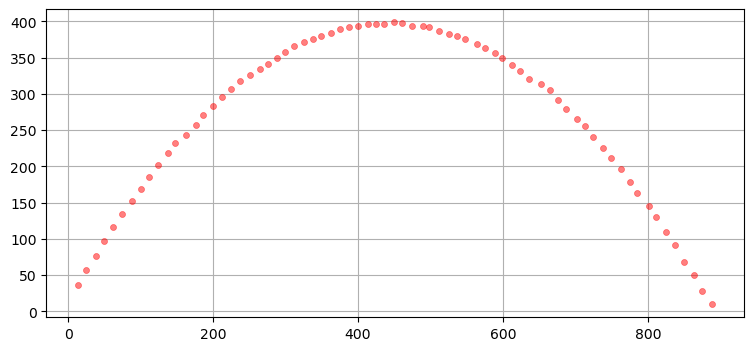

In [63]:
def test_ball_vacuum(noise):
    y = 15
    x = 0
    ball = BallTrajectory2D(x0=x, y0=y, 
                            theta_deg=60., velocity=100., 
                            noise=noise)
    t = 0
    dt = 0.25
    while y >= 0:
        x, y = ball.step(dt)
        t += dt
        if y >= 0:
            plt.scatter(x, y, color='r', marker='.', s=75, alpha=0.5)
         
    plt.axis('equal');
    
#test_ball_vacuum([0, 0]) # plot ideal ball position
test_ball_vacuum([1, 1]) # plot with noise 

This looks reasonable, so let's continue (exercise for the reader: validate this simulation more robustly).

这看起来很合理，所以让我们继续（为读者练习：更稳健地验证此模拟）。


### Choose the State Variables

### 选取状态变量

We might think to use the same state variables as used for tracking the dog. However, this will not work. Recall that the Kalman filter state transition must be written as $\mathbf{\bar x} = \mathbf{Fx} + \mathbf{Bu}$, which means we must calculate the current state from the previous state. Our assumption is that the ball is traveling in a vacuum, so the velocity in x is a constant, and the acceleration in y is solely due to the gravitational constant $g$. We can discretize the Newtonian equations using the well known Euler method in terms of $\Delta t$ are:

我们可能会考虑使用与跟踪狗相同的状态变量。但是，这行不通。回想一下，卡尔曼滤波器状态转换必须写为 $\mathbf{\bar x} = \mathbf{Fx} + \mathbf{Bu}$，这意味着我们必须从前一个状态计算当前状态。我们的假设是球在真空中运动，因此 x 中的速度是一个常数，而 y 中的加速度完全取决于引力常数 $g$。我们可以使用众所周知的欧拉方法对牛顿方程进行离散化，其中 $\Delta t$ 为：

$$\begin{aligned}
x_t &=  x_{t-1} + v_{x(t-1)} {\Delta t} \\
v_{xt} &= v_{x(t-1)} \\
y_t &= y_{t-1} + v_{y(t-1)} {\Delta t} \\
v_{yt} &= -g {\Delta t} + v_{y(t-1)} \\
\end{aligned}
$$

> **sidebar**: *Euler's method integrates a differential equation stepwise by assuming the slope (derivative) is constant at time $t$. In this case the derivative of the position is velocity. At each time step $\Delta t$ we assume a constant velocity, compute the new position, and then update the velocity for the next time step. There are more accurate methods, such as Runge-Kutta available to us, but because we are updating the state with a measurement in each step Euler's method is very accurate. If you need to use Runge-Kutta you will have to write your own `predict()` function which computes the state transition for $\mathbf x$, and then uses the normal Kalman filter equation $\mathbf{\bar P}=\mathbf{FPF}^\mathsf T + \mathbf Q$ to update the covariance matrix.*

> **侧边栏**：*欧拉方法通过假设斜率（导数）在时间 $t$ 处为常数来逐步积分微分方程。在这种情况下，位置的导数是速度。在每个时间步 $\Delta t$ 我们假设一个恒定的速度，计算新的位置，然后更新下一个时间步的速度。有更准确的方法，例如我们可用的龙格库塔，但因为我们在每一步中都使用测量值更新状态，所以欧拉方法非常准确。如果你需要使用 Runge-Kutta，你必须编写自己的 `predict()` 函数来计算 $\mathbf x$ 的状态转换，然后使用正常的卡尔曼滤波器方程 $\mathbf{\bar P}= \mathbf{FPF}^\mathsf T + \mathbf Q$ 更新协方差矩阵。*
这意味着我们需要把 $y$ 的加速度纳入卡尔曼滤波器，而 $x$ 不需要。由此可以想到用下面这组状态变量。

This implies that we need to incorporate acceleration for $y$ into the Kalman filter, but not for $x$. This suggests the following state variable.

$$
\mathbf x = 
\begin{bmatrix}
x & \dot x & y & \dot y & \ddot{y}
\end{bmatrix}^\mathsf T
$$

However, the acceleration is due to gravity, which is a constant. Instead of asking the Kalman filter to track a constant we can treat gravity as what it really is - a control input. In other words, gravity is a force that alters the behavior of the system in a known way, and it is applied throughout the flight of the ball. 

然而，加速度是由于重力，这是一个常数。与其要求卡尔曼滤波器跟踪一个常数，我们可以将重力视为它的本质——一个控制输入。换句话说，重力是一种以已知方式改变系统行为的力，它会在球的整个飞行过程中施加。

The equation for the state prediction is $\mathbf{\bar x} = \mathbf{Fx} + \mathbf{Bu}$. $\mathbf{Fx}$ is the familiar state transition function which we will use to model the position and velocity of the ball. The vector $\mathbf{u}$ lets you specify a control input into the filter. For a car the control input will be things such as the amount the accelerator and brake are pressed, the position of the steering wheel, and so on. For our ball the control input will be gravity. The matrix $\mathbf{B}$ models how the control inputs affect the behavior of the system. Again, for a car $\mathbf{B}$ will convert the inputs of the brake and accelerator into changes of velocity, and the input of the steering wheel into a different position and heading. For our ball tracking problem it will compute the velocity change due to gravity. We will go into the details of that soon. For now, we design the state variable to be

状态预测的方程是 $\mathbf{\bar x} = \mathbf{Fx} + \mathbf{Bu}$。$\mathbf{Fx}$ 是我们将用来模拟球的位置和速度的熟悉的状态转换函数。向量 $\mathbf{u}$ 让你可以指定滤波器的控制输入。对于汽车来说，控制输入将是诸如油门和制动器的踩下量、方向盘的位置等。对于我们的球，控制输入将是重力。矩阵 $\mathbf{B}$ 模拟控制输入如何影响系统的行为。同样，对于汽车，$\mathbf{B}$ 会将刹车和加速器的输入转换为速度变化，并将方向盘的输入转换为不同的位置和航向。对于我们的球跟踪问题，它将计算由于重力引起的速度变化。我们将很快详细介绍。现在，我们将状态变量设计为

$$
\mathbf x = 
\begin{bmatrix}x & \dot x & y & \dot y 
\end{bmatrix}^\mathsf T
$$


### Design State Transition Function

### 设计状态转移函数

Our next step is to design the state transition function. Recall that the state transition function is implemented as a matrix $\mathbf F$ that we multiply with the previous state of our system to get the next state, or prior $\bar{\mathbf x} = \mathbf{Fx}$.

我们的下一步是设计状态转换函数。回想一下，状态转换函数是作为矩阵 $\mathbf F$ 实现的，我们将它与系统的前一个状态相乘以获得下一个状态，或先验 $\bar{\mathbf x} = \mathbf{Fx}$。

I will not belabor this as it is very similar to the 1-D case we did in the previous chapter. Our state equations for position and velocity would be:

我不会对此进行详细说明，因为它与我们在前一章中所做的一维案例非常相似。我们的位置和速度状态方程为：

$$
\begin{aligned}
\bar x &= (1*x) + (\Delta t * v_x) + (0*y) + (0 * v_y) \\
\bar v_x &= (0*x) +  (1*v_x) + (0*y) + (0 * v_y) \\
\bar y &= (0*x) + (0* v_x)         + (1*y) + (\Delta t * v_y)   \\
\bar v_y &= (0*x) +  (0*v_x) + (0*y) + (1*v_y) 
\end{aligned}
$$

Note that none of the terms include $g$, the gravitational constant. As I explained in the previous function we will account for gravity using the control input of the Kalman filter.
In matrix form we write this as:

请注意，没有一个术语包括 $g$，即引力常数。正如我在上一个函数中解释的那样，我们将使用卡尔曼滤波器的控制输入来解释重力。
在矩阵形式中，我们将其写为：

$$
\mathbf F = \begin{bmatrix}
1 & \Delta t & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & \Delta t \\
0 & 0 & 0 & 1
\end{bmatrix}
$$


### Design the Control Input Function

### 设计控制输入函数

We will use the control input to account for the force of gravity. The term $\mathbf{Bu}$ is added to $\mathbf{\bar x}$ to account for how much $\mathbf{\bar x}$ changes due to gravity. We can say that  $\mathbf{Bu}$ contains $\begin{bmatrix}\Delta x_g & \Delta \dot{x_g} & \Delta y_g & \Delta \dot{y_g}\end{bmatrix}^\mathsf T$.

我们将使用控制输入来解释重力。术语 $\mathbf{Bu}$ 被添加到 $\mathbf{\bar x}$ 以说明 $\mathbf{\bar x}$ 因重力而发生的变化。我们可以说 $\mathbf{Bu}$ 包含 $\begin{bmatrix}\Delta x_g & \Delta \dot{x_g} & \Delta y_g & \Delta \dot{y_g}\end{bmatrix}^\mathsf T 美元。

If we look at the discretized equations we see that gravity only affects the velocity for $y$.

如果我们查看离散方程，我们会发现重力只影响 $y$ 的速度。

$$\begin{aligned}
x_t &=  x_{t-1} + v_{x(t-1)} {\Delta t} \\
v_{xt} &= vx_{t-1}
\\
y_t &= y_{t-1} + v_{y(t-1)} {\Delta t}\\
v_{yt} &= -g {\Delta t} + v_{y(t-1)} \\
\end{aligned}
$$

Therefore we want the product $\mathbf{Bu}$ to equal $\begin{bmatrix}0 & 0 & 0 & -g \Delta t \end{bmatrix}^\mathsf T$. In some sense it is arbitrary how we define $\mathbf{B}$ and $\mathbf{u}$ so long as multiplying them together yields this result. For example, we could define $\mathbf{B}=1$ and $\mathbf{u} = \begin{bmatrix}0 & 0 & 0 & -g \Delta t \end{bmatrix}^\mathsf T$. But this doesn't really fit with our definitions for $\mathbf{B}$ and $\mathbf{u}$, where $\mathbf{u}$ is the control input, and $\mathbf{B}$ is the control function. The control input is $-g$ for the velocity of y. So this is one possible definition.

因此我们希望积 $\mathbf{Bu}$ 等于 $\begin{bmatrix}0 & 0 & 0 & -g \Delta t \end{bmatrix}^\mathsf T$。从某种意义上说，我们如何定义 $\mathbf{B}$ 和 $\mathbf{u}$ 是任意的，只要将它们相乘产生这个结果。例如，我们可以定义 $\mathbf{B}=1$ 和 $\mathbf{u} = \begin{bmatrix}0 & 0 & 0 & -g \Delta t \end{bmatrix}^\mathsf T$。但这并不真正符合我们对 $\mathbf{B}$ 和 $\mathbf{u}$ 的定义，其中 $\mathbf{u}$ 是控制输入，$\mathbf{B}$ 是控制功能。对于 y 的速度，控制输入是 $-g$。所以这是一种可能的定义。

$$\mathbf{B} = \begin{bmatrix}0&0&0&0 \\ 0&0&0&0 \\0&0&0&0 \\0&0&0&\Delta t\end{bmatrix}, \mathbf{u} = \begin{bmatrix}0\\0\\0\\-g\end{bmatrix}$$

To me this seems a bit excessive; I would suggest we might want $\mathbf{u}$ to contain the control input for the two dimensions $x$ and $y$, which suggests

对我来说，这似乎有点过分了。我建议我们可能希望 $\mathbf{u}$ 包含 $x$ 和 $y$ 两个维度的控制输入，这表明

$$\mathbf{B} = \begin{bmatrix}0&0 \\ 0&0 \\0&0 \\0&\Delta t\end{bmatrix}, \mathbf{u} = \begin{bmatrix}0\\-g\end{bmatrix}$$.

You might prefer to only provide control inputs that actually exist, and there is no control input for $x$, so we arrive at

你可能更愿意只提供实际存在的控制输入，并且 $x$ 没有控制输入，所以我们得出

$$\mathbf{B} = \begin{bmatrix}0 \\ 0 \\0\\ \Delta t\end{bmatrix}, \mathbf{u} = \begin{bmatrix}-g\end{bmatrix}$$.

I've seen people use 
$$\mathbf{B} = \begin{bmatrix}0&0&0&0 \\ 0&0&0&0 \\0&0&0&0 \\0&0&0&1\end{bmatrix}, \mathbf{u} = \begin{bmatrix}0\\0\\0\\-g \Delta t\end{bmatrix}$$

我见过人们使用

While this does produce the correct result, I am resistant to putting time into $\mathbf{u}$  as time is not a control input, it is what we use to convert the control input into a change in state, which is the job of $\mathbf{B}$.

$$\mathbf{B} = \begin{bmatrix}0&0&0&0 \\ 0&0&0&0 \\0&0&0&0 \\0&0&0&1\end{bmatrix}, \mathbf{u} = \begin{bmatrix}0\\0\\0\\-g \Delta t\end{bmatrix}$$

虽然这确实产生了正确的结果，但我拒绝将时间放入 $\mathbf{u}$，因为时间不是控制输入，它是我们用来将控制输入转换为状态变化的东西，这就是工作 $\mathbf{B}$。


### Design the Measurement Function

### 设计测量函数

The measurement function defines how we go from the state variables to the measurements using the equation $\mathbf z = \mathbf{Hx}$. We will assume that we have a sensor that provides us with the position of the ball in (x,y), but cannot measure velocities or accelerations. Therefore our function must be:

测量函数使用方程 $\mathbf z = \mathbf{Hx}$ 定义了我们如何从状态变量到测量值。我们假设我们有一个传感器，可以为我们提供球在 (x,y) 中的位置，但不能测量速度或加速度。因此我们的函数必须是：

$$
\begin{bmatrix}z_x \\ z_y \end{bmatrix}= 
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0
\end{bmatrix} 
\begin{bmatrix}
x \\
\dot x \\
y \\
\dot y \end{bmatrix}$$

where

where

$$\mathbf H = \begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0
\end{bmatrix}$$


### Design the Measurement Noise Matrix

### 设计测量噪声矩阵

As with the robot, we will assume that the error is independent in $x$ and $y$. In this case we will start by assuming that the measurement errors in x and y are 0.5 meters squared. Hence,

与机器人一样，我们假设误差在 $x$ 和 $y$ 中是独立的。在这种情况下，我们首先假设 x 和 y 的测量误差为 0.5 平方米。因此，

$$\mathbf R = \begin{bmatrix}0.5&0\\0&0.5\end{bmatrix}$$


### Design the Process Noise Matrix

### 设计过程噪声矩阵

We are assuming a ball moving in a vacuum, so there should be no process noise. We have 4 state variables, so we need a $4{\times}4$ covariance matrix:

我们假设一个球在真空中移动，所以应该没有过程噪声。我们有 4 个状态变量，所以我们需要一个 $4{\times}4$ 协方差矩阵：

$$\mathbf Q = \begin{bmatrix}0&0&0&0\\0&0&0&0\\0&0&0&0\\0&0&0&0\end{bmatrix}$$


### Design the Initial Conditions

### 设计初始条件

We already performed this step when we tested the state transition function. Recall that we computed the initial velocity for $x$ and $y$ using trigonometry, and set the value of $\mathbf x$ with:

我们在测试状态转换函数时已经执行了这一步。回想一下，我们使用三角函数计算了 $x$ 和 $y$ 的初始速度，并将 $\mathbf x$ 的值设置为：

```python
omega = radians(omega)
vx = cos(omega) * v0
vy = sin(omega) * v0

f1.x = np.array([[x, vx, y, vy]]).T
```

f1.x = np.array([[x, vx, y, vy]]).T
```

With all the steps done we are ready to implement our filter and test it. First, the implementation:

完成所有步骤后，我们就可以实现滤波器并对其进行测试了。一、实现：


In [64]:
from math import sin, cos, radians

def ball_kf(x, y, omega, v0, dt, r=0.5, q=0.):
    kf = KalmanFilter(dim_x=4, dim_z=2, dim_u=1)

    kf.F = np.array([[1., dt, 0., 0.],   # x   = x0 + dx*dt
                     [0., 1., 0., 0.],   # dx  = dx0
                     [0., 0., 1., dt],   # y   = y0 + dy*dt
                     [0., 0., 0., 1.]])  # dy  = dy0

    kf.H = np.array([[1., 0., 0., 0.],
                     [0., 0., 1., 0.]])
    
    kf.B = np.array([[0., 0., 0., dt]]).T
    kf.R *= r
    kf.Q *= q

    omega = radians(omega)
    vx = cos(omega) * v0
    vy = sin(omega) * v0
    kf.x = np.array([[x, vx, y, vy]]).T
    return kf

Now we will test the filter by generating measurements for the ball using the ball simulation class.

现在我们将通过使用球模拟类生成球的测量值来测试滤波器。


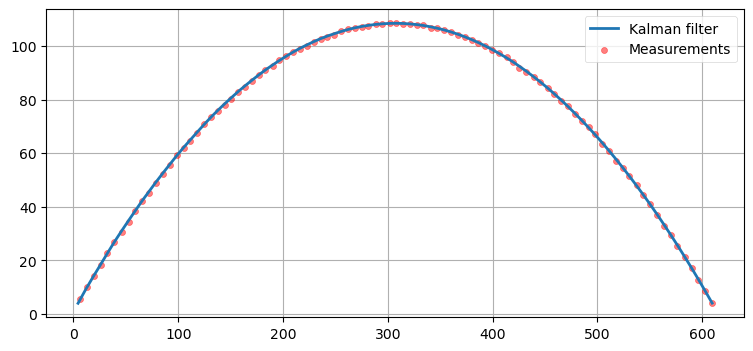

In [65]:
def track_ball_vacuum(dt):
    global kf
    x, y = 0., 1.
    theta = 35.  # launch angle
    v0 = 80.
    g = np.array([[-9.8]])  # gravitational constant
    ball = BallTrajectory2D(x0=x, y0=y, theta_deg=theta, velocity=v0, 
                            noise=[.2, .2])
    kf = ball_kf(x, y, theta, v0, dt)

    t = 0
    xs, ys = [], []
    while kf.x[2] > 0:
        t += dt
        x, y = ball.step(dt)
        z = np.array([[x, y]]).T

        kf.update(z)
        xs.append(kf.x[0])
        ys.append(kf.x[2])    
        kf.predict(u=g)     
        p1 = plt.scatter(x, y, color='r', marker='.', s=75, alpha=0.5)
    p2, = plt.plot(xs, ys, lw=2)
    plt.legend([p2, p1], ['Kalman filter', 'Measurements'],
               scatterpoints=1)
    
track_ball_vacuum(dt=1./10)

We see that the Kalman filter reasonably tracks the ball. However, as already explained, this is a trivial example because we have no process noise. We can predict trajectories in a vacuum with arbitrary precision; using a Kalman filter in this example is a needless complication. A least squares curve fit would give identical results.

我们看到卡尔曼滤波器合理地跟踪球。然而，正如已经解释过的，这是一个微不足道的例子，因为我们没有过程噪声。我们可以以任意精度预测真空中的轨迹；在这个例子中使用卡尔曼滤波器是不必要的复杂化。最小二乘曲线拟合将给出相同的结果。


## Tracking a Ball in Air

## 在空气中跟踪一个球

For this problem we assume that we are tracking a ball traveling through the Earth's atmosphere. The path of the ball is influenced by wind, drag, and the rotation of the ball. We will assume that our sensor is a camera; code that we will not implement will perform some type of image processing to detect the position of the ball. This is typically called *blob detection* in computer vision. However, image processing code is not perfect; in any given frame it is possible to either detect no blob or to detect spurious blobs that do not correspond to the ball. Finally, we will not assume that we know the starting position, angle, or rotation of the ball; the tracking code will have to initiate tracking based on the measurements that are provided. The main simplification that we are making here is a 2D world; we assume that the ball is always traveling orthogonal to the plane of the camera's sensor. We have to make that simplification at this point because we have not discussed how we might extract 3D information from a camera, which provides only 2D data.

对于这个问题，我们假设我们正在跟踪一个穿过地球大气层的球。球的路径受风、阻力和球旋转的影响。我们将假设我们的传感器是相机；我们不会实现的代码将执行某种类型的图像处理来检测球的位置。这在计算机视觉中通常称为 *blob detection*。但是，图像处理代码并不完美；在任何给定的帧中，既可以检测到没有斑点，也可以检测到与球不对应的虚假斑点。最后，我们不会假设我们知道球的起始位置、角度或旋转；跟踪代码必须根据提供的测量值启动跟踪。我们在这里所做的主要简化是 2D 世界；我们假设球总是垂直于相机传感器的平面运动。在这一点上我们必须进行简化，因为我们还没有讨论如何从仅提供 2D 数据的相机中提取 3D 信息。


### Implementing Air Drag

### 实现空气阻力

Our first step is to implement the math for a ball moving through air. There are several treatments available. A robust solution takes into account issues such as ball roughness (which affects drag non-linearly depending on velocity), the Magnus effect (spin causes one side of the ball to have higher velocity relative to the air vs the opposite side, so the coefficient of drag differs on opposite sides), the effect of lift, humidity, air density, and so on. I assume the reader is not interested in the details of ball physics, and so will restrict this treatment to the effect of air drag on a non-spinning baseball. I will use the math developed by Nicholas Giordano and Hisao Nakanishi in *Computational Physics*  [1997]. This treatement does not take all the factors into account. The most detailed treatment is by Alan Nathan on his website at http://baseball.physics.illinois.edu/index.html. I use his math in my own work in computer vision, but I do not want to get distracted by a more complicated model.

我们的第一步是实现一个球在空气中移动的数学。有几种治疗方法可供选择。一个稳健的解决方案会考虑诸如球粗糙度（它会根据速度非线性地影响阻力）、马格努斯效应（旋转导致球的一侧相对于空气相对于另一侧具有更高的速度，因此系数阻力在相对侧不同），升力，湿度，空气密度等的影响。我假设读者对球物理的细节不感兴趣，因此将这种处理限制为空气阻力对非旋转棒球的影响。我将使用 Nicholas Giordano 和 Hisao Nakanishi 在 *Computational Physics* [1997] 中开发的数学。这种处理没有考虑所有因素。Alan Nathan 在他的网站 http://baseball.physics.illinois.edu/index.html 上进行了最详细的处理。我在自己的计算机视觉工作中使用了他的数学，但我不想被更复杂的模型分散注意力。

**Important**: Before I continue, let me point out that you will not have to understand this next piece of physics to proceed with the Kalman filter. My goal is to create a reasonably accurate behavior of a baseball in the real world, so that we can test how our Kalman filter performs with real-world behavior. In real world applications it is usually impossible to completely model the physics of a real world system, and we make do with a process model that incorporates the large scale behaviors. We then tune the measurement noise and process noise until the filter works well with our data. There is a real risk to this; it is easy to finely tune a Kalman filter so it works perfectly with your test data, but performs badly when presented with slightly different data. This is perhaps the hardest part of designing a Kalman filter, and why it gets referred to with terms such as 'black art'. 

**重要**：在我继续之前，让我指出，你无需了解下一部分物理知识即可继续使用卡尔曼滤波器。我的目标是在现实世界中创建一个相当准确的棒球行为，以便我们可以测试我们的卡尔曼滤波器在现实世界行为中的表现。在现实世界的应用程序中，通常不可能对现实世界系统的物理特性进行完全建模，我们使用包含大规模行为的过程模型来凑合。然后我们调整测量噪声和过程噪声，直到滤波器与我们的数据配合良好。这确实存在风险；微调卡尔曼滤波器很容易，因此它可以完美地处理你的测试数据，但在呈现略有不同的数据时表现不佳。这可能是设计卡尔曼滤波器最困难的部分，也是为什么它被称为“黑艺术”之类的术语。

I dislike books that implement things without explanation, so I will now develop the physics for a ball moving through air. Move on past the implementation of the simulation if you are not interested. 

我不喜欢没有解释就实现事物的书籍，所以我现在将开发一个球在空气中移动的物理学。如果你不感兴趣，请继续执行模拟。

A ball moving through air encounters wind resistance. This imparts a force on the wall, called *drag*, which alters the flight of the ball. In Giordano this is denoted as

在空气中移动的球会遇到风阻。这会在墙上施加一个称为 *drag* 的力，它会改变球的飞行。在佐丹奴这被表示为

$$F_{drag} = -B_2v^2$$

where $B_2$ is a coefficient derived experimentally, and $v$ is the velocity of the object. $F_{drag}$ can be factored into $x$ and $y$ components with

其中$B_2$ 是实验得出的系数，$v$ 是物体的速度。$F_{drag}$ 可以分解为 $x$ 和 $y$ 组件

$$\begin{aligned}
F_{drag,x} &= -B_2v v_x\\
F_{drag,y} &= -B_2v v_y
\end{aligned}$$

If $m$ is the mass of the ball, we can use $F=ma$ to compute the acceleration as

如果 $m$ 是球的质量，我们可以使用 $F=ma$ 来计算加速度为

$$\begin{aligned} 
a_x &= -\frac{B_2}{m}v v_x\\
a_y &= -\frac{B_2}{m}v v_y
\end{aligned}$$

Giordano provides the following function for $\frac{B_2}{m}$, which takes air density, the cross section of a baseball, and its roughness into account. Understand that this is an approximation based on wind tunnel tests and several simplifying assumptions. It is in SI units: velocity is in meters/sec and time is in seconds.

Giordano 为 $\frac{B_2}{m}$ 提供了以下函数，其中考虑了空气密度、棒球的横截面和粗糙度。了解这是基于风洞测试和几个简化假设的近似值。它采用 SI 单位：速度以米/秒为单位，时间以秒为单位。

$$\frac{B_2}{m} = 0.0039 + \frac{0.0058}{1+\exp{[(v-35)/5]}}$$

Starting with this Euler discretization of the ball path in a vacuum:
$$\begin{aligned}
x &= v_x \Delta t \\
y &= v_y \Delta t \\
v_x &= v_x \\
v_y &= v_y - 9.8 \Delta t
\end{aligned}
$$

从真空中球路径的 Euler 离散化开始：

We can incorporate this force (acceleration) into our equations by incorporating $accel * \Delta t$ into the velocity update equations. We should subtract this component because drag will reduce the velocity. The code to do this is quite straightforward, we just need to break out the force into $x$ and $y$ components. 

I will not belabor this issue further because computational physics is beyond the scope of this book. Recognize that a higher fidelity simulation would require incorporating things like altitude, temperature, ball spin, and several other factors. The aforementioned work by Alan Nathan covers this if you are interested. My intent here is to impart some real-world behavior into our simulation to test how  our simpler prediction model used by the Kalman filter reacts to this behavior. Your process model will never exactly model what happens in the world, and a large factor in designing a good Kalman filter is carefully testing how it performs against real world data. 

The code below computes the behavior of a baseball in air, at sea level, in the presence of wind. I plot the same initial hit with no wind, and then with a tail wind at 10 mph. Baseball statistics are universally done in US units, and we will follow suit here (http://en.wikipedia.org/wiki/United_States_customary_units). Note that the velocity of 110 mph is a typical exit speed for a baseball for a home run hit.

$$\begin{aligned}
x &= v_x \Delta t \\
y &= v_y \Delta t \\
v_x &= v_x \\
v_y &= v_y - 9.8 \Delta t
\end{aligned}
$$

我们可以通过将 $accel * \Delta t$ 合并到速度更新方程中来将这个力（加速度）合并到我们的方程中。我们应该减去这个分量，因为阻力会降低速度。执行此操作的代码非常简单，我们只需要将力分解为 $x$ 和 $y$ 组件。

我不会进一步阐述这个问题，因为计算物理学超出了本书的范围。认识到更高保真度的模拟需要结合高度、温度、球旋转和其他几个因素。如果你有兴趣，上述 Alan Nathan 的工作将涵盖这一点。我的目的是在我们的模拟中加入一些真实世界的行为，以测试卡尔曼滤波器使用的更简单的预测模型如何对这种行为做出反应。你的过程模型永远不会准确地模拟世界上发生的事情，设计一个好的卡尔曼滤波器的一个重要因素是仔细测试它在现实世界数据中的表现。

下面的代码计算了棒球在空中、海平面、有风时的行为。我在没有风的情况下绘制了相同的初始打击，然后以 10 英里/小时的速度顺风。棒球统计数据普遍以美国单位进行，我们将在此处效仿 (http://en.wikipedia.org/wiki/United_States_customary_units)。请注意，110 mph 的速度是棒球击出本垒打时的典型退出速度。


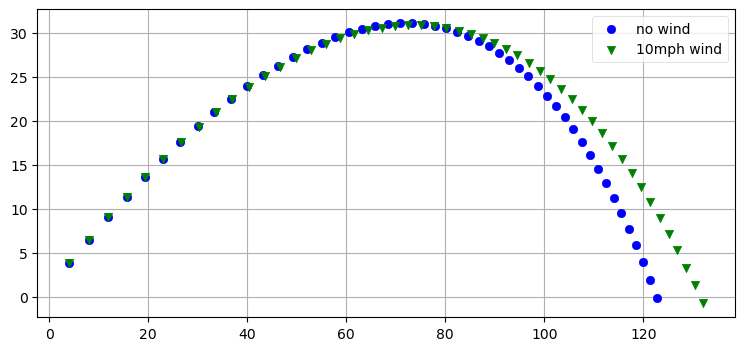

In [66]:
from math import sqrt, exp

def mph_to_mps(x):
    return x * .447

def drag_force(velocity):
    """ Returns the force on a baseball due to air drag at
    the specified velocity. Units are SI"""

    return velocity * (0.0039 + 0.0058 / 
            (1. + exp((velocity-35.)/5.)))

v = mph_to_mps(110.)
x, y = 0., 1.
dt = .1
theta = radians(35)

def solve(x, y, vel, v_wind, launch_angle):
    xs = []
    ys = []
    v_x = vel*cos(launch_angle)
    v_y = vel*sin(launch_angle)
    while y >= 0:
        # Euler equations for x and y
        x += v_x*dt
        y += v_y*dt

        # force due to air drag    
        velocity = sqrt((v_x-v_wind)**2 + v_y**2)    
        F = drag_force(velocity)

        # euler's equations for vx and vy
        v_x = v_x - F*(v_x-v_wind)*dt
        v_y = v_y - 9.8*dt - F*v_y*dt
        
        xs.append(x)
        ys.append(y)
    
    return xs, ys
        
x, y = solve(x=0, y=1, vel=v, v_wind=0, launch_angle=theta)
p1 = plt.scatter(x, y, color='blue', label='no wind')

wind = mph_to_mps(10)
x, y = solve(x=0, y=1, vel=v, v_wind=wind, launch_angle=theta)
p2 = plt.scatter(x, y, color='green', marker="v", 
                 label='10mph wind')
plt.legend(scatterpoints=1);

We can easily see the difference between the trajectory in a vacuum and in the air. I used the same initial velocity and launch angle in the ball in a vacuum section above. We computed that the ball in a vacuum would travel over 240 meters (nearly 800 ft). In the air, the distance is just over 120 meters, or roughly 400 ft. 400ft is a realistic distance for a well hit home run ball, so we can be confident that our simulation is reasonably accurate.

我们可以很容易地看到真空和空气中的轨迹之间的差异。在上面的真空部分，我在球中使用了相同的初始速度和发射角度。我们计算出真空中的球将行进超过 240 米（近 800 英尺）。在空中，距离刚刚超过 120 米，或大约 400 英尺。400 英尺对于击打好的本垒打球来说是一个真实的距离，因此我们可以确信我们的模拟相当准确。

Without further ado we will create a ball simulation that uses the math above to create a more realistic ball trajectory. I will note that the nonlinear behavior of drag means that there is no analytic solution to the ball position at any point in time, so we need to compute the position step-wise. I use Euler's method to propagate the solution; use of a more accurate technique such as Runge-Kutta is left as an exercise for the reader. That modest complication is unnecessary for what we are doing because the accuracy difference between the techniques will be small for the time steps we will be using.

事不宜迟，我们将创建一个球模拟，使用上面的数学来创建更真实的球轨迹。我会注意到阻力的非线性行为意味着在任何时间点都没有球位置的解析解，因此我们需要逐步计算位置。我使用欧拉的方法来传播解决方案；使用更准确的技术（如 Runge-Kutta）留给读者作为练习。对于我们正在做的事情来说，这种适度的复杂性是不必要的，因为对于我们将使用的时间步长而言，技术之间的准确性差异将很小。


In [67]:
class BaseballPath:
    def __init__(self, x0, y0, launch_angle_deg, velocity_ms, 
                 noise=(1.0, 1.0)): 
        """ Create 2D baseball path object  
           (x = distance from start point in ground plane, 
            y=height above ground)
        
        x0,y0            initial position
        launch_angle_deg angle ball is travelling respective to 
                         ground plane
        velocity_ms      speeed of ball in meters/second
        noise            amount of noise to add to each position
                         in (x, y)
        """
        
        omega = radians(launch_angle_deg)
        self.v_x = velocity_ms * cos(omega)
        self.v_y = velocity_ms * sin(omega)

        self.x = x0
        self.y = y0
        self.noise = noise


    def drag_force(self, velocity):
        """ Returns the force on a baseball due to air drag at
        the specified velocity. Units are SI
        """
        B_m = 0.0039 + 0.0058 / (1. + exp((velocity-35.)/5.))
        return B_m * velocity


    def update(self, dt, vel_wind=0.):
        """ compute the ball position based on the specified time 
        step and wind velocity. Returns (x, y) position tuple.
        """

        # Euler equations for x and y
        self.x += self.v_x*dt
        self.y += self.v_y*dt

        # force due to air drag
        v_x_wind = self.v_x - vel_wind
        v = sqrt(v_x_wind**2 + self.v_y**2)
        F = self.drag_force(v)

        # Euler's equations for velocity
        self.v_x = self.v_x - F*v_x_wind*dt
        self.v_y = self.v_y - 9.81*dt - F*self.v_y*dt

        return (self.x + randn()*self.noise[0], 
                self.y + randn()*self.noise[1])

Now we can test the Kalman filter against measurements created by this model.

现在我们可以根据这个模型创建的测量值来测试卡尔曼滤波器。


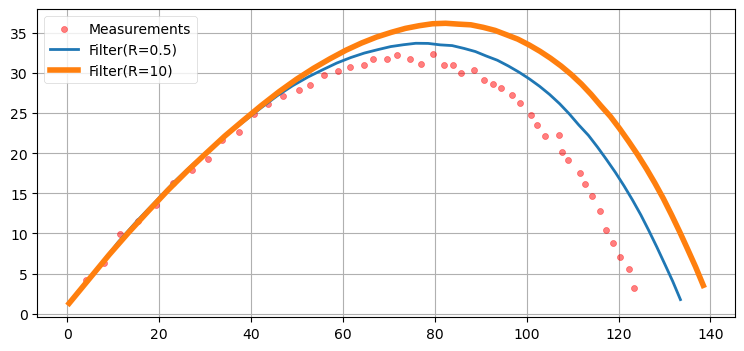

In [68]:
x, y = 0, 1.

theta = 35. # launch angle
v0 = 50.
dt = 1/10.   # time step
g = np.array([[-9.8]])

plt.figure()
ball = BaseballPath(x0=x, y0=y, launch_angle_deg=theta,
                    velocity_ms=v0, noise=[.3,.3])
f1 = ball_kf(x, y, theta, v0, dt, r=1.)
f2 = ball_kf(x, y, theta, v0, dt, r=10.)
t = 0
xs, ys = [], []
xs2, ys2 = [], []

while f1.x[2] > 0:
    t += dt
    x, y = ball.update(dt)
    z = np.array([[x, y]]).T

    f1.update(z)
    f2.update(z)
    xs.append(f1.x[0])
    ys.append(f1.x[2])
    xs2.append(f2.x[0])
    ys2.append(f2.x[2])    
    f1.predict(u=g) 
    f2.predict(u=g)
    
    p1 = plt.scatter(x, y, color='r', marker='.', s=75, alpha=0.5)

p2, = plt.plot(xs, ys, lw=2)
p3, = plt.plot(xs2, ys2, lw=4)
plt.legend([p1, p2, p3], 
           ['Measurements', 'Filter(R=0.5)', 'Filter(R=10)'],
           loc='best', scatterpoints=1);

I have plotted the output of two different Kalman filter settings. The measurements are depicted as green circles, a Kalman filter with R=0.5 as a thin green line, and a Kalman filter with R=10 as a thick blue line. These R values are chosen merely to show the effect of measurement noise on the output, they are not intended to imply a correct design.

我绘制了两种不同卡尔曼滤波器设置的输出。测量值用绿色圆圈表示，R=0.5 的卡尔曼滤波器用绿色细线表示，R=10 的卡尔曼滤波器用蓝色粗线表示。选择这些 R 值只是为了显示测量噪声对输出的影响，并不意味着设计正确。

We can see that neither filter does very well. At first both track the measurements well, but as time continues they both diverge. This happens because the state model for air drag is nonlinear and the Kalman filter assumes that it is linear. If you recall our discussion about nonlinearity in the g-h filter chapter we showed why a g-h filter will always lag behind the acceleration of the system. We see the same thing here - the acceleration is negative, so the Kalman filter consistently overshoots the ball position. There is no way for the filter to catch up so long as the acceleration continues, so the filter will continue to diverge.

我们可以看到两个滤波器都做得很好。起初，两者都很好地跟踪了测量结果，但随着时间的推移，它们都出现了分歧。这是因为空气阻力的状态模型是非线性的，而卡尔曼滤波器假设它是线性的。如果你还记得我们在 g-h 滤波器一章中关于非线性的讨论，我们将说明为什么 g-h 滤波器总是落后于系统的加速度。我们在这里看到同样的事情——加速度是负的，所以卡尔曼滤波器总是超过球的位置。只要继续加速，滤波器就没有办法赶上，所以滤波器将继续发散。

What can we do to improve this? The best approach is to perform the filtering with a nonlinear Kalman filter, and we will do this in subsequent chapters. However, there is also what I will call an 'engineering' solution to this problem as well. Our Kalman filter assumes that the ball is in a vacuum, and thus that there is no process noise. However, since the ball is in air the atmosphere imparts a force on the ball. We can think of this force as process noise. This is not a particularly rigorous thought; for one thing, this force is anything but Gaussian. Secondly, we can compute this force, so throwing our hands up and saying 'it's random' will not lead to an optimal solution. But let's see what happens if we follow this line of thought.

我们可以做些什么来改善这一点？最好的方法是使用非线性卡尔曼滤波器进行滤波，我们将在后续章节中这样做。然而，对于这个问题，我也将称之为“工程”解决方案。我们的卡尔曼滤波器假设球在真空中，因此没有过程噪声。然而，由于球在空气中，因此大气会对球施加力。我们可以将这种力视为过程噪声。这不是一个特别严谨的想法；一方面，这种力绝不是高斯的。其次，我们可以计算这个力，所以举起手说“它是随机的”不会导致最优解。但是，让我们看看如果我们遵循这种思路会发生什么。

The following code implements the same Kalman filter as before, but with a non-zero process noise. I plot two examples, one with `Q=.1`, and one with `Q=0.01`.

以下代码实现了与之前相同的卡尔曼滤波器，但过程噪声非零。我绘制了两个示例，一个使用“Q=.1”，一个使用“Q=0.01”。


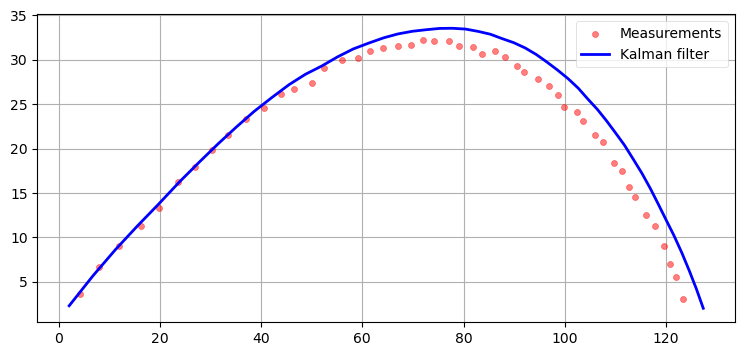

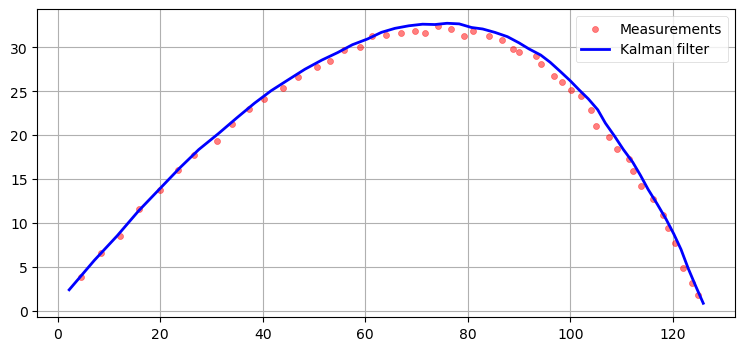

In [69]:
def plot_ball_with_q(q, r=1., noise=0.3):
    x, y = 0., 1.
    theta = 35. # launch angle
    v0 = 50.
    dt = 1/10.   # time step
    g = np.array([[-9.8]])

    ball = BaseballPath(x0=x, 
                        y0=y, 
                        launch_angle_deg=theta, 
                        velocity_ms=v0, 
                        noise=[noise,noise])
    f1 = ball_kf(x, y, theta, v0, dt, r=r, q=q)
    t = 0
    xs, ys = [], []

    while f1.x[2] > 0:
        t += dt
        x, y = ball.update(dt)
        z = np.array([[x, y]]).T

        f1.update(z)
        xs.append(f1.x[0])
        ys.append(f1.x[2]) 
        f1.predict(u=g) 

        p1 = plt.scatter(x, y, c='r', marker='.', s=75, alpha=0.5)

    p2, = plt.plot(xs, ys, lw=2, color='b')
    plt.legend([p1, p2], ['Measurements', 'Kalman filter'])
    plt.show()

plot_ball_with_q(0.01)
plot_ball_with_q(0.1)

The second filter tracks the measurements fairly well. There appears to be a bit of lag, but very little.

第二个滤波器可以很好地跟踪测量结果。似乎有一点滞后，但很少。

Is this a good technique? Usually not, but it depends. Here the nonlinearity of the force on the ball is fairly constant and regular. Assume we are trying to track an automobile - the accelerations will vary as the car changes speeds and turns. When we make the process noise higher than the actual noise in the system the filter will opt to weigh the measurements higher. If you don't have a lot of noise in your measurements this might work for you. However, consider this next plot where I have increased the noise in the measurements.

这是一个很好的技术吗？通常不会，但这取决于。在这里，球上的力的非线性是相当恒定和有规律的。假设我们正在尝试跟踪汽车——加速度会随着汽车速度和转弯的变化而变化。当我们使过程噪声高于系统中的实际噪声时，滤波器将选择更高的测量权重。如果你的测量中没有很多噪声，这可能对你有用。但是，请考虑下一个图，其中我增加了测量中的噪声。


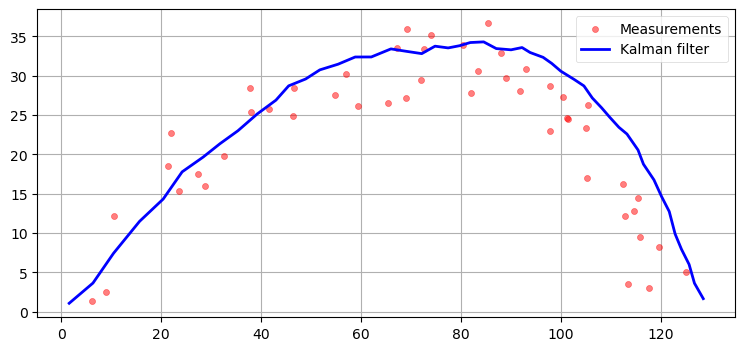

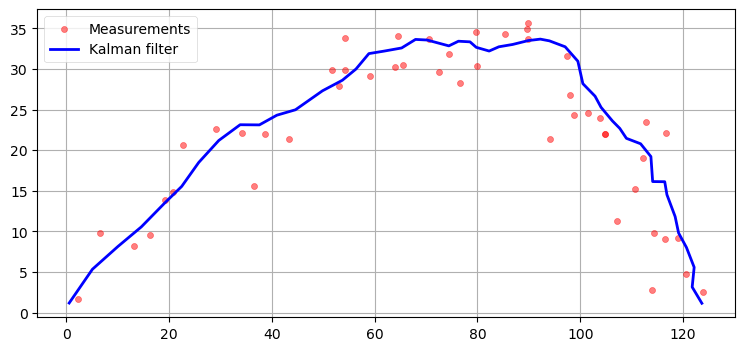

In [70]:
plot_ball_with_q(0.01, r=3, noise=3.)
plot_ball_with_q(0.1, r=3, noise=3.)

This output is terrible. The filter has no choice but to give more weight to the measurements than the process (prediction step), but when the measurements are noisy the filter output will just track the noise. This inherent limitation of the linear Kalman filter is what lead to the development of nonlinear versions of the filter.

这个输出太可怕了。滤波器别无选择，只能比过程（预测步骤）赋予测量更多的权重，但是当测量有噪声时，滤波器输出只会跟踪噪声。线性卡尔曼滤波器的这种固有限制导致了滤波器非线性版本的发展。

With that said, it is certainly possible to use the process noise to deal with small nonlinearities in your system. This is part of the 'black art' of Kalman filters. Our model of the sensors and of the system are never perfect. Sensors are non-Gaussian and our process model is never perfect. You can mask some of this by setting the measurement errors and process errors higher than their theoretically correct values, but the trade off is a non-optimal solution. Certainly it is better to be non-optimal than to have your Kalman filter diverge. However, as we can see in the graphs above, it is easy for the output of the filter to be very bad. It is also very common to run many simulations and tests and to end up with a filter that performs very well under those conditions. Then, when you use the filter on real data the conditions are slightly different and the filter ends up performing terribly. 

话虽如此，当然可以使用过程噪声来处理系统中的小非线性。这是卡尔曼滤波器“魔法”的一部分。我们的传感器和系统模型从来都不是完美的。传感器是非高斯的，我们的过程模型从来都不是完美的。你可以通过将测量误差和过程误差设置为高于其理论正确值来掩盖其中的一部分，但折衷是一种非最佳解决方案。当然，非最优比让卡尔曼滤波器发散要好。然而，正如我们在上图中看到的那样，滤波器的输出很容易变得非常糟糕。运行许多模拟和测试并最终得到在这些条件下表现非常好的滤波器也是很常见的。然后，当你对真实数据使用滤波器时，条件会略有不同，滤波器最终会表现得非常糟糕。

For now we will set this problem aside, as we are clearly misapplying the Kalman filter in this example. We will revisit this problem in subsequent chapters to see the effect of using various nonlinear techniques. In some domains you will be able to get away with using a linear Kalman filter for a nonlinear problem, but usually you will have to use one or more of the techniques you will learn in the rest of this book.

现在我们将把这个问题放在一边，因为我们在这个例子中显然误用了卡尔曼滤波器。我们将在随后的章节中重新讨论这个问题，看看使用各种非线性技术的效果。在某些领域中，你可以使用线性卡尔曼滤波器来解决非线性问题，但通常你将不得不使用你将在本书其余部分中学习的一种或多种技术。


## References

## 参考文献

[1] Bar-Shalom, Yaakov, et al. *Estimation with Applications to Tracking and Navigation.* John Wiley & Sons, 2001.

[1] Bar-Shalom, Yaakov, et al. *Estimation with Applications to Tracking and Navigation.* John Wiley & Sons, 2001.
